In [15]:
# ============================================================
# EXPERIMENT 7 — PHASE 1
# FLAIR-PRESERVED MULTIMODAL GATED SEGMENTATION
#
# Primary idea:
#   FLAIR = primary / protected
#   T1 + T2 = auxiliary / complementary
#
# Phase 1:
#   - New architecture
#   - Same training split
#   - Same validation split
#   - Same test set
#   - Baseline loss
#   - Baseline sampling
#   - No hard-lesion oversampling yet
#   - No conspicuity-weighted loss yet
#
# Goal:
#   Preserve FLAIR sensitivity while allowing T1/T2
#   to provide selective corrections.
# ============================================================

import os
import gc
import random
import numpy as np
import pandas as pd
import torch


# ============================================================
# 1. MAIN DATASET ROOT
# ============================================================

DATASET_ROOT = (
    r"C:\Defense_project\PROJECT_FILE"
    r"\MSLesSegDataset"
)


# ============================================================
# 2. PREPROCESSED DATA
# ============================================================

PREPROCESSED_ROOT = os.path.join(
    DATASET_ROOT,
    "N4_Zscore_preprocessed"
)

TRAIN_ROOT = os.path.join(
    PREPROCESSED_ROOT,
    "train"
)

TEST_ROOT = os.path.join(
    PREPROCESSED_ROOT,
    "test"
)


# ============================================================
# 3. EXPERIMENT 7 OUTPUT ROOT
# ============================================================

EXP7_ROOT = os.path.join(
    DATASET_ROOT,
    "Experiment_7_FLAIR_Preserved_Gated"
)


CHECKPOINT_DIR = os.path.join(
    EXP7_ROOT,
    "checkpoints"
)

BEST_MODEL_DIR = os.path.join(
    EXP7_ROOT,
    "best_model"
)

LOG_DIR = os.path.join(
    EXP7_ROOT,
    "logs"
)

RESULT_DIR = os.path.join(
    EXP7_ROOT,
    "results"
)


# ============================================================
# 4. CREATE DIRECTORIES
# ============================================================

for path in [
    EXP7_ROOT,
    CHECKPOINT_DIR,
    BEST_MODEL_DIR,
    LOG_DIR,
    RESULT_DIR
]:

    os.makedirs(
        path,
        exist_ok=True
    )


# ============================================================
# 5. MODEL OUTPUT
# ============================================================

BEST_MODEL_EXP7 = os.path.join(
    BEST_MODEL_DIR,
    "best_model_exp7_flair_preserved_gated.pth"
)


# ============================================================
# 6. TRAINING CONFIGURATION
# ============================================================

NUM_EPOCHS = 100

BATCH_SIZE = 1

LEARNING_RATE = 1e-4

WEIGHT_DECAY = 0.0


# ============================================================
# 7. ROI
# ============================================================

ROI_SIZE = (
    144,
    144,
    144
)


SW_BATCH_SIZE = 1

OVERLAP = 0.5


# ============================================================
# 8. MODEL CHANNEL CONFIGURATION
# ============================================================

# Keep the model reasonably sized because your disk space
# was previously getting consumed by large checkpoints.

FEATURE_SIZE = 16


# ============================================================
# 9. AMP
# ============================================================

USE_AMP = True


# ============================================================
# 10. RANDOM SEED
# ============================================================

SEED = 42


def set_seed(seed=42):

    random.seed(
        seed
    )

    np.random.seed(
        seed
    )

    torch.manual_seed(
        seed
    )

    if torch.cuda.is_available():

        torch.cuda.manual_seed_all(
            seed
        )


set_seed(
    SEED
)


# ============================================================
# 11. DEVICE
# ============================================================

device = torch.device(
    "cuda"
    if torch.cuda.is_available()
    else "cpu"
)


# ============================================================
# 12. CONFIG SUMMARY
# ============================================================

print("=" * 90)
print("EXPERIMENT 7 — PHASE 1")
print("FLAIR-PRESERVED MULTIMODAL GATED SEGMENTATION")
print("=" * 90)

print("\n--- PATHS ---")

print(
    "Dataset root:",
    DATASET_ROOT
)

print(
    "Train root:",
    TRAIN_ROOT
)

print(
    "Test root:",
    TEST_ROOT
)

print(
    "Experiment 7 root:",
    EXP7_ROOT
)

print(
    "Best model:",
    BEST_MODEL_EXP7
)


print("\n--- TRAINING ---")

print(
    "Epochs:",
    NUM_EPOCHS
)

print(
    "Batch size:",
    BATCH_SIZE
)

print(
    "Learning rate:",
    LEARNING_RATE
)

print(
    "ROI:",
    ROI_SIZE
)

print(
    "AMP:",
    USE_AMP
)

print(
    "Device:",
    device
)


if torch.cuda.is_available():

    print(
        "GPU:",
        torch.cuda.get_device_name(0)
    )


print("\n--- PHASE 1 RULES ---")

print(
    "Loss:",
    "Baseline DiceCE-style objective"
)

print(
    "Sampling:",
    "Baseline / unchanged"
)

print(
    "Architecture:",
    "NEW"
)

print(
    "Hard-lesion oversampling:",
    "NO"
)

print(
    "Conspicuity-weighted loss:",
    "NO"
)

print(
    "Modality dropout:",
    "NO"
)

print("=" * 90)

EXPERIMENT 7 — PHASE 1
FLAIR-PRESERVED MULTIMODAL GATED SEGMENTATION

--- PATHS ---
Dataset root: C:\Defense_project\PROJECT_FILE\MSLesSegDataset
Train root: C:\Defense_project\PROJECT_FILE\MSLesSegDataset\N4_Zscore_preprocessed\train
Test root: C:\Defense_project\PROJECT_FILE\MSLesSegDataset\N4_Zscore_preprocessed\test
Experiment 7 root: C:\Defense_project\PROJECT_FILE\MSLesSegDataset\Experiment_7_FLAIR_Preserved_Gated
Best model: C:\Defense_project\PROJECT_FILE\MSLesSegDataset\Experiment_7_FLAIR_Preserved_Gated\best_model\best_model_exp7_flair_preserved_gated.pth

--- TRAINING ---
Epochs: 100
Batch size: 1
Learning rate: 0.0001
ROI: (144, 144, 144)
AMP: True
Device: cuda
GPU: NVIDIA GeForce RTX 3060

--- PHASE 1 RULES ---
Loss: Baseline DiceCE-style objective
Sampling: Baseline / unchanged
Architecture: NEW
Hard-lesion oversampling: NO
Conspicuity-weighted loss: NO
Modality dropout: NO


In [16]:
# ============================================================
# EXPERIMENT 7 — DATASET STRUCTURE CHECK
# ============================================================

print("=" * 90)
print("DATASET STRUCTURE CHECK")
print("=" * 90)


# ============================================================
# 1. ROOT CHECK
# ============================================================

for name, path in [
    ("DATASET_ROOT", DATASET_ROOT),
    ("PREPROCESSED_ROOT", PREPROCESSED_ROOT),
    ("TRAIN_ROOT", TRAIN_ROOT),
    ("TEST_ROOT", TEST_ROOT)
]:

    print(
        f"{name:<22}:",
        os.path.exists(path),
        "|",
        path
    )


# ============================================================
# 2. PATIENT COUNTS
# ============================================================

train_patients = sorted(
    [
        p
        for p in os.listdir(TRAIN_ROOT)
        if os.path.isdir(
            os.path.join(
                TRAIN_ROOT,
                p
            )
        )
    ]
)


test_patients = sorted(
    [
        p
        for p in os.listdir(TEST_ROOT)
        if os.path.isdir(
            os.path.join(
                TEST_ROOT,
                p
            )
        )
    ],
    key=lambda x:
        int(x[1:])
        if x.startswith("P")
        and x[1:].isdigit()
        else x
)


print("\nTrain patient folders:",
      len(train_patients))

print(
    "Test patient folders :",
    len(test_patients)
)


print(
    "\nTest patients:"
)

print(
    test_patients
)


# ============================================================
# 3. EXPECTED TEST COUNT
# ============================================================

if len(test_patients) != 22:

    raise RuntimeError(
        f"Expected 22 test patients, "
        f"found {len(test_patients)}."
    )


print(
    "\n✓ 22 test patients verified."
)


# ============================================================
# 4. SAMPLE FILE CHECK
# ============================================================

sample_patient = test_patients[0]

sample_root = os.path.join(
    TEST_ROOT,
    sample_patient
)


sample_files = [
    f"{sample_patient}_FLAIR_N4_Z.nii.gz",
    f"{sample_patient}_T1_N4_Z.nii.gz",
    f"{sample_patient}_T2_N4_Z.nii.gz",
    f"{sample_patient}_MASK.nii.gz"
]


print(
    "\n--- SAMPLE TEST PATIENT ---"
)

print(
    "Patient:",
    sample_patient
)


for filename in sample_files:

    path = os.path.join(
        sample_root,
        filename
    )

    print(
        filename,
        "->",
        os.path.exists(path)
    )


print("=" * 90)

DATASET STRUCTURE CHECK
DATASET_ROOT          : True | C:\Defense_project\PROJECT_FILE\MSLesSegDataset
PREPROCESSED_ROOT     : True | C:\Defense_project\PROJECT_FILE\MSLesSegDataset\N4_Zscore_preprocessed
TRAIN_ROOT            : True | C:\Defense_project\PROJECT_FILE\MSLesSegDataset\N4_Zscore_preprocessed\train
TEST_ROOT             : True | C:\Defense_project\PROJECT_FILE\MSLesSegDataset\N4_Zscore_preprocessed\test

Train patient folders: 53
Test patient folders : 22

Test patients:
['P54', 'P55', 'P56', 'P57', 'P58', 'P59', 'P60', 'P61', 'P62', 'P63', 'P64', 'P65', 'P66', 'P67', 'P68', 'P69', 'P70', 'P71', 'P72', 'P73', 'P74', 'P75']

✓ 22 test patients verified.

--- SAMPLE TEST PATIENT ---
Patient: P54
P54_FLAIR_N4_Z.nii.gz -> True
P54_T1_N4_Z.nii.gz -> True
P54_T2_N4_Z.nii.gz -> True
P54_MASK.nii.gz -> True


In [17]:
# ============================================================
# EXPERIMENT 7 — LOAD ORIGINAL SPLIT
# ============================================================

import json


SPLIT_FILE = os.path.join(
    DATASET_ROOT,
    "nnUNet_Exp6_Fresh",
    "nnUNet_preprocessed",
    "Dataset602_MSLesSeg_FLAIR",
    "splits_final.json"
)


print("=" * 90)
print("ORIGINAL SPLIT CHECK")
print("=" * 90)

print(
    "Split file:",
    SPLIT_FILE
)

print(
    "Exists:",
    os.path.exists(SPLIT_FILE)
)


if not os.path.exists(SPLIT_FILE):

    raise FileNotFoundError(
        "Original split file was not found:\n"
        + SPLIT_FILE
    )


with open(
    SPLIT_FILE,
    "r"
) as f:

    original_splits = json.load(
        f
    )


print(
    "\nNumber of split definitions:",
    len(original_splits)
)


print(
    "\nFirst split:"
)

print(
    original_splits[0]
)

ORIGINAL SPLIT CHECK
Split file: C:\Defense_project\PROJECT_FILE\MSLesSegDataset\nnUNet_Exp6_Fresh\nnUNet_preprocessed\Dataset602_MSLesSeg_FLAIR\splits_final.json
Exists: True

Number of split definitions: 1

First split:
{'train': ['P1_T1', 'P1_T2', 'P1_T3', 'P2_T1', 'P2_T2', 'P2_T3', 'P2_T4', 'P3_T1', 'P3_T2', 'P3_T3', 'P3_T4', 'P5_T1', 'P5_T2', 'P7_T1', 'P7_T2', 'P8_T1', 'P8_T2', 'P9_T1', 'P9_T2', 'P9_T3', 'P10_T1', 'P10_T2', 'P11_T1', 'P11_T2', 'P12_T1', 'P12_T2', 'P12_T3', 'P12_T4', 'P15_T1', 'P16_T1', 'P17_T1', 'P19_T1', 'P19_T2', 'P19_T3', 'P19_T4', 'P21_T1', 'P22_T1', 'P22_T2', 'P23_T1', 'P24_T1', 'P25_T1', 'P26_T1', 'P27_T1', 'P28_T1', 'P28_T2', 'P29_T1', 'P30_T1', 'P31_T1', 'P31_T2', 'P32_T1', 'P34_T1', 'P35_T1', 'P36_T1', 'P37_T1', 'P38_T1', 'P39_T1', 'P40_T1', 'P41_T1', 'P43_T1', 'P45_T1', 'P46_T1', 'P47_T1', 'P49_T1', 'P49_T2', 'P50_T1', 'P50_T2', 'P52_T1', 'P52_T2', 'P53_T1', 'P53_T2'], 'val': ['P4_T1', 'P4_T2', 'P4_T3', 'P6_T1', 'P6_T2', 'P6_T3', 'P13_T1', 'P13_T2', 'P14

In [18]:
# ============================================================
# EXPERIMENT 7 — BUILD EXACT ORIGINAL TRAIN / VALIDATION LISTS
#
# Source:
#   splits_final.json
#
# IMPORTANT:
#   We do NOT create a new random split.
#
# Original split found:
#   Train = 93 cases
#   Val   = 23 cases
#
# Total = 116 train-side cases
#
# Test = separate 22 patients (P54-P75)
# ============================================================

import os


# ============================================================
# 1. LOAD SPLIT
# ============================================================

split7 = original_splits[0]


train_case_ids_exp7 = list(
    split7["train"]
)

val_case_ids_exp7 = list(
    split7["val"]
)


print("=" * 90)
print("EXPERIMENT 7 — EXACT ORIGINAL SPLIT")
print("=" * 90)

print(
    "Training cases in split:",
    len(train_case_ids_exp7)
)

print(
    "Validation cases in split:",
    len(val_case_ids_exp7)
)

print(
    "Total:",
    len(train_case_ids_exp7)
    +
    len(val_case_ids_exp7)
)


# ============================================================
# 2. HELPER
# ============================================================

def parse_case_id_exp7(case_id):

    # Example:
    #   P1_T1
    #
    # becomes:
    #   patient   = P1
    #   timepoint = T1

    parts = case_id.split(
        "_"
    )

    if len(parts) != 2:

        raise ValueError(
            f"Unexpected case ID: {case_id}"
        )

    return (
        parts[0],
        parts[1]
    )


# ============================================================
# 3. BUILD TRAIN-SIDE CASE DICTIONARY
# ============================================================

all_train_cases_exp7 = {}


for patient in os.listdir(
    TRAIN_ROOT
):

    patient_root = os.path.join(
        TRAIN_ROOT,
        patient
    )


    if not os.path.isdir(
        patient_root
    ):

        continue


    for timepoint in os.listdir(
        patient_root
    ):

        timepoint_root = os.path.join(
            patient_root,
            timepoint
        )


        if not os.path.isdir(
            timepoint_root
        ):

            continue


        case_id = (
            f"{patient}_{timepoint}"
        )


        # ----------------------------------------------------
        # Expected files
        # ----------------------------------------------------

        flair_path = os.path.join(
            timepoint_root,
            f"{case_id}_FLAIR_N4_Z.nii.gz"
        )

        t1_path = os.path.join(
            timepoint_root,
            f"{case_id}_T1_N4_Z.nii.gz"
        )

        t2_path = os.path.join(
            timepoint_root,
            f"{case_id}_T2_N4_Z.nii.gz"
        )

        mask_path = os.path.join(
            timepoint_root,
            f"{case_id}_MASK.nii.gz"
        )


        # ----------------------------------------------------
        # Only accept complete multimodal cases
        # ----------------------------------------------------

        if not all(
            os.path.exists(path)
            for path in [
                flair_path,
                t1_path,
                t2_path,
                mask_path
            ]
        ):

            continue


        all_train_cases_exp7[
            case_id
        ] = {

            "image": [
                flair_path,
                t1_path,
                t2_path
            ],

            "label":
                mask_path,

            "patient":
                patient,

            "timepoint":
                timepoint,

            "case_id":
                case_id
        }


# ============================================================
# 4. REBUILD TRAIN LIST
# ============================================================

train_files_exp7 = []


missing_train_cases_exp7 = []


for case_id in train_case_ids_exp7:

    if case_id in all_train_cases_exp7:

        train_files_exp7.append(
            all_train_cases_exp7[
                case_id
            ]
        )

    else:

        missing_train_cases_exp7.append(
            case_id
        )


# ============================================================
# 5. REBUILD VALIDATION LIST
# ============================================================

val_files_exp7 = []


missing_val_cases_exp7 = []


for case_id in val_case_ids_exp7:

    if case_id in all_train_cases_exp7:

        val_files_exp7.append(
            all_train_cases_exp7[
                case_id
            ]
        )

    else:

        missing_val_cases_exp7.append(
            case_id
        )


# ============================================================
# 6. SUMMARY
# ============================================================

print("\n" + "=" * 90)
print("REBUILT FILE LISTS")
print("=" * 90)

print(
    "Available complete train-side cases:",
    len(all_train_cases_exp7)
)

print(
    "Train cases reconstructed:",
    len(train_files_exp7)
)

print(
    "Validation cases reconstructed:",
    len(val_files_exp7)
)

print(
    "Missing train cases:",
    len(missing_train_cases_exp7)
)

print(
    "Missing validation cases:",
    len(missing_val_cases_exp7)
)


# ============================================================
# 7. SAFETY CHECKS
# ============================================================

if missing_train_cases_exp7:

    print(
        "\nMissing train case IDs:"
    )

    print(
        missing_train_cases_exp7
    )


if missing_val_cases_exp7:

    print(
        "\nMissing validation case IDs:"
    )

    print(
        missing_val_cases_exp7
    )


if len(missing_train_cases_exp7) != 0:

    raise RuntimeError(
        "Some training cases from the original split "
        "could not be found in the current dataset."
    )


if len(missing_val_cases_exp7) != 0:

    raise RuntimeError(
        "Some validation cases from the original split "
        "could not be found in the current dataset."
    )


# ============================================================
# 8. EXACT SPLIT CHECK
# ============================================================

if len(train_files_exp7) != len(
    train_case_ids_exp7
):

    raise RuntimeError(
        "Training case count mismatch."
    )


if len(val_files_exp7) != len(
    val_case_ids_exp7
):

    raise RuntimeError(
        "Validation case count mismatch."
    )


print(
    "\n✓ Original split reconstructed exactly."
)


# ============================================================
# 9. SHOW FIRST TRAIN CASE
# ============================================================

print("\n" + "=" * 90)
print("FIRST TRAIN CASE")
print("=" * 90)

first_train_exp7 = (
    train_files_exp7[0]
)

print(
    "Case ID  :",
    first_train_exp7[
        "case_id"
    ]
)

print(
    "Patient  :",
    first_train_exp7[
        "patient"
    ]
)

print(
    "Timepoint:",
    first_train_exp7[
        "timepoint"
    ]
)

print(
    "FLAIR    :",
    os.path.basename(
        first_train_exp7[
            "image"
        ][0]
    )
)

print(
    "T1       :",
    os.path.basename(
        first_train_exp7[
            "image"
        ][1]
    )
)

print(
    "T2       :",
    os.path.basename(
        first_train_exp7[
            "image"
        ][2]
    )
)

print(
    "MASK     :",
    os.path.basename(
        first_train_exp7[
            "label"
        ]
    )
)


# ============================================================
# 10. SHOW FIRST VALIDATION CASE
# ============================================================

print("\n" + "=" * 90)
print("FIRST VALIDATION CASE")
print("=" * 90)

first_val_exp7 = (
    val_files_exp7[0]
)

print(
    "Case ID  :",
    first_val_exp7[
        "case_id"
    ]
)

print(
    "Patient  :",
    first_val_exp7[
        "patient"
    ]
)

print(
    "Timepoint:",
    first_val_exp7[
        "timepoint"
    ]
)


# ============================================================
# 11. FINAL
# ============================================================

print("\n" + "=" * 90)
print("EXPERIMENT 7 SPLIT READY")
print("=" * 90)

print(
    f"TRAIN = {len(train_files_exp7)} cases"
)

print(
    f"VAL   = {len(val_files_exp7)} cases"
)

print(
    f"TEST  = {len(test_patients)} patients"
)

print("=" * 90)

EXPERIMENT 7 — EXACT ORIGINAL SPLIT
Training cases in split: 70
Validation cases in split: 23
Total: 93

REBUILT FILE LISTS
Available complete train-side cases: 93
Train cases reconstructed: 70
Validation cases reconstructed: 23
Missing train cases: 0
Missing validation cases: 0

✓ Original split reconstructed exactly.

FIRST TRAIN CASE
Case ID  : P1_T1
Patient  : P1
Timepoint: T1
FLAIR    : P1_T1_FLAIR_N4_Z.nii.gz
T1       : P1_T1_T1_N4_Z.nii.gz
T2       : P1_T1_T2_N4_Z.nii.gz
MASK     : P1_T1_MASK.nii.gz

FIRST VALIDATION CASE
Case ID  : P4_T1
Patient  : P4
Timepoint: T1

EXPERIMENT 7 SPLIT READY
TRAIN = 70 cases
VAL   = 23 cases
TEST  = 22 patients


In [19]:
# ============================================================
# EXPERIMENT 7 — PHASE 1
# BASELINE-COMPATIBLE TRANSFORMS + DATA LOADERS
#
# IMPORTANT:
#   Same preprocessing assumptions as previous experiments.
#
#   Phase 1:
#       - No hard-lesion oversampling
#       - No special lesion weighting
#       - No modality dropout
#       - No additional augmentation beyond baseline
# ============================================================

import torch

from monai.transforms import (
    Compose,
    LoadImaged,
    EnsureChannelFirstd,
    EnsureTyped,
    Orientationd,
    Spacingd,
    CropForegroundd,
    RandSpatialCropd,
    RandFlipd,
    RandRotate90d
)

from monai.data import (
    Dataset,
    DataLoader
)


# ============================================================
# 1. BASELINE TRAIN TRANSFORMS
# ============================================================

train_transforms_exp7 = Compose([

    # --------------------------------------------------------
    # Load:
    # image = [FLAIR, T1, T2]
    # label = MASK
    # --------------------------------------------------------
    LoadImaged(
        keys=[
            "image",
            "label"
        ]
    ),

    # --------------------------------------------------------
    # Channel-first
    # --------------------------------------------------------
    EnsureChannelFirstd(
        keys=[
            "image",
            "label"
        ]
    ),

    # --------------------------------------------------------
    # Standard orientation
    # --------------------------------------------------------
    Orientationd(
        keys=[
            "image",
            "label"
        ],
        axcodes="RAS"
    ),

    # --------------------------------------------------------
    # 1 mm isotropic spacing
    # --------------------------------------------------------
    Spacingd(
        keys=[
            "image",
            "label"
        ],
        pixdim=(
            1.0,
            1.0,
            1.0
        ),
        mode=(
            "bilinear",
            "nearest"
        )
    ),

    # --------------------------------------------------------
    # Foreground crop
    # --------------------------------------------------------
    CropForegroundd(
        keys=[
            "image",
            "label"
        ],
        source_key="image"
    ),

    # --------------------------------------------------------
    # Random 144³ training patch
    # --------------------------------------------------------
    RandSpatialCropd(
        keys=[
            "image",
            "label"
        ],
        roi_size=ROI_SIZE,
        random_size=False
    ),

    # --------------------------------------------------------
    # Spatial augmentation
    # --------------------------------------------------------
    RandFlipd(
        keys=[
            "image",
            "label"
        ],
        spatial_axis=0,
        prob=0.5
    ),

    RandFlipd(
        keys=[
            "image",
            "label"
        ],
        spatial_axis=1,
        prob=0.5
    ),

    RandFlipd(
        keys=[
            "image",
            "label"
        ],
        spatial_axis=2,
        prob=0.5
    ),

    RandRotate90d(
        keys=[
            "image",
            "label"
        ],
        prob=0.5,
        max_k=3
    ),

    # --------------------------------------------------------
    # Tensor conversion
    # --------------------------------------------------------
    EnsureTyped(
        keys=[
            "image",
            "label"
        ],
        dtype=torch.float32
    )
])


# ============================================================
# 2. VALIDATION TRANSFORMS
# ============================================================

val_transforms_exp7 = Compose([

    LoadImaged(
        keys=[
            "image",
            "label"
        ]
    ),

    EnsureChannelFirstd(
        keys=[
            "image",
            "label"
        ]
    ),

    Orientationd(
        keys=[
            "image",
            "label"
        ],
        axcodes="RAS"
    ),

    Spacingd(
        keys=[
            "image",
            "label"
        ],
        pixdim=(
            1.0,
            1.0,
            1.0
        ),
        mode=(
            "bilinear",
            "nearest"
        )
    ),

    CropForegroundd(
        keys=[
            "image",
            "label"
        ],
        source_key="image"
    ),

    EnsureTyped(
        keys=[
            "image",
            "label"
        ],
        dtype=torch.float32
    )
])


# ============================================================
# 3. DATASETS
# ============================================================

train_ds_exp7 = Dataset(
    data=train_files_exp7,
    transform=train_transforms_exp7
)


val_ds_exp7 = Dataset(
    data=val_files_exp7,
    transform=val_transforms_exp7
)


# ============================================================
# 4. DATALOADERS
# ============================================================

train_loader_exp7 = DataLoader(
    train_ds_exp7,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0,
    pin_memory=torch.cuda.is_available()
)


val_loader_exp7 = DataLoader(
    val_ds_exp7,
    batch_size=1,
    shuffle=False,
    num_workers=0,
    pin_memory=torch.cuda.is_available()
)


# ============================================================
# 5. SUMMARY
# ============================================================

print("=" * 100)
print("EXPERIMENT 7 — DATA PIPELINE READY")
print("=" * 100)

print(
    "Training dataset:",
    len(train_ds_exp7)
)

print(
    "Validation dataset:",
    len(val_ds_exp7)
)

print(
    "Training batches:",
    len(train_loader_exp7)
)

print(
    "Validation batches:",
    len(val_loader_exp7)
)

print(
    "Batch size:",
    BATCH_SIZE
)

print(
    "ROI:",
    ROI_SIZE
)

print(
    "Workers:",
    0
)

print("=" * 100)

EXPERIMENT 7 — DATA PIPELINE READY
Training dataset: 70
Validation dataset: 23
Training batches: 70
Validation batches: 23
Batch size: 1
ROI: (144, 144, 144)
Workers: 0


c:\Defense_project\PROJECT_FILE\venv\lib\site-packages\monai\utils\deprecate_utils.py:321: FutureWarning: monai.transforms.croppad.dictionary CropForegroundd.__init__:allow_smaller: Current default value of argument `allow_smaller=True` has been deprecated since version 1.2. It will be changed to `allow_smaller=False` in version 1.5.
  warn_deprecated(argname, msg, warning_category)


In [20]:
# ============================================================
# EXPERIMENT 7 — DATA SANITY CHECK
# ============================================================

print("=" * 100)
print("EXPERIMENT 7 — SAMPLE DATA SANITY CHECK")
print("=" * 100)


sample_train = train_ds_exp7[0]

sample_val = val_ds_exp7[0]


# ============================================================
# TRAIN SAMPLE
# ============================================================

print("\n--- TRAIN SAMPLE ---")

print(
    "Case:",
    train_files_exp7[0]["case_id"]
)

print(
    "Image shape:",
    tuple(
        sample_train["image"].shape
    )
)

print(
    "Label shape:",
    tuple(
        sample_train["label"].shape
    )
)

print(
    "Image dtype:",
    sample_train["image"].dtype
)

print(
    "Label dtype:",
    sample_train["label"].dtype
)


print(
    "Image min:",
    float(
        sample_train["image"].min()
    )
)

print(
    "Image max:",
    float(
        sample_train["image"].max()
    )
)

print(
    "Label unique values:",
    torch.unique(
        sample_train["label"]
    )
)


# ============================================================
# VALIDATION SAMPLE
# ============================================================

print("\n--- VALIDATION SAMPLE ---")

print(
    "Case:",
    val_files_exp7[0]["case_id"]
)

print(
    "Image shape:",
    tuple(
        sample_val["image"].shape
    )
)

print(
    "Label shape:",
    tuple(
        sample_val["label"].shape
    )
)

print(
    "Image dtype:",
    sample_val["image"].dtype
)

print(
    "Label dtype:",
    sample_val["label"].dtype
)


print(
    "Image min:",
    float(
        sample_val["image"].min()
    )
)

print(
    "Image max:",
    float(
        sample_val["image"].max()
    )
)

print(
    "Label unique values:",
    torch.unique(
        sample_val["label"]
    )
)


# ============================================================
# 7. CHANNEL CHECK
# ============================================================

if sample_train["image"].shape[0] != 3:

    raise RuntimeError(
        "Training image does not have 3 channels."
    )


if sample_val["image"].shape[0] != 3:

    raise RuntimeError(
        "Validation image does not have 3 channels."
    )


if sample_train["label"].shape[0] != 1:

    raise RuntimeError(
        "Training label does not have 1 channel."
    )


if sample_val["label"].shape[0] != 1:

    raise RuntimeError(
        "Validation label does not have 1 channel."
    )


print("\n✓ 3 input channels verified: FLAIR + T1 + T2")
print("✓ 1 output channel verified")
print("✓ Data pipeline sanity check passed")

print("=" * 100)

EXPERIMENT 7 — SAMPLE DATA SANITY CHECK

--- TRAIN SAMPLE ---
Case: P1_T1
Image shape: (3, 144, 144, 144)
Label shape: (1, 144, 144, 144)
Image dtype: torch.float32
Label dtype: torch.float32
Image min: -3.664137840270996
Image max: 7.055608749389648
Label unique values: metatensor([0., 1.])

--- VALIDATION SAMPLE ---
Case: P4_T1
Image shape: (3, 142, 180, 154)
Label shape: (1, 142, 180, 154)
Image dtype: torch.float32
Label dtype: torch.float32
Image min: -3.6981019973754883
Image max: 9.142909049987793
Label unique values: metatensor([0., 1.])

✓ 3 input channels verified: FLAIR + T1 + T2
✓ 1 output channel verified
✓ Data pipeline sanity check passed


In [22]:
# ============================================================
# EXPERIMENT 7 — PHASE 1
# FLAIR-PRESERVED GATED MULTIMODAL NETWORK
#
# Architecture:
#
#   FLAIR -----------------> Primary Encoder -----------┐
#                                                       │
#   T1 + T2 -------------> Auxiliary Encoder ---> Gate ─┤
#                                                       │
#                         Protected FLAIR ---------------┤
#                                                       ↓
#                                                    Decoder
#                                                       ↓
#                                                Final Mask
#
# Fusion:
#
#   G = sigmoid(Conv([FLAIR_features, Auxiliary_features]))
#
#   Fused = FLAIR_features + G * Auxiliary_features
#
# IMPORTANT:
#   No brightness-percentile input is provided to the gate.
#   No ground-truth information is used by the model.
#
# Phase 1:
#   Architecture ONLY is changed.
# ============================================================

import torch
import torch.nn as nn
import torch.nn.functional as F


# ============================================================
# 1. BASIC CONV BLOCK
# ============================================================

class ConvBlock3D(nn.Module):

    def __init__(
        self,
        in_channels,
        out_channels
    ):

        super().__init__()


        self.block = nn.Sequential(

            nn.Conv3d(
                in_channels,
                out_channels,
                kernel_size=3,
                padding=1,
                bias=False
            ),

            nn.InstanceNorm3d(
                out_channels
            ),

            nn.PReLU(
                out_channels
            ),

            nn.Conv3d(
                out_channels,
                out_channels,
                kernel_size=3,
                padding=1,
                bias=False
            ),

            nn.InstanceNorm3d(
                out_channels
            ),

            nn.PReLU(
                out_channels
            )
        )


    def forward(self, x):

        return self.block(x)


# ============================================================
# 2. ENCODER BLOCK
# ============================================================

class EncoderBlock3D(nn.Module):

    def __init__(
        self,
        in_channels,
        out_channels
    ):

        super().__init__()


        self.conv = ConvBlock3D(
            in_channels,
            out_channels
        )


        self.downsample = nn.Conv3d(
            out_channels,
            out_channels,
            kernel_size=2,
            stride=2
        )


    def forward(self, x):

        features = self.conv(
            x
        )

        down = self.downsample(
            features
        )

        return (
            features,
            down
        )


# ============================================================
# 3. GATED FUSION
# ============================================================

class GatedFusion3D(nn.Module):

    def __init__(
        self,
        channels
    ):

        super().__init__()


        # Gate is learned from both modalities.
        self.gate = nn.Sequential(

            nn.Conv3d(
                channels * 2,
                channels,
                kernel_size=1,
                bias=True
            ),

            nn.Sigmoid()
        )


        # Optional refinement after fusion.
        self.refine = nn.Sequential(

            nn.Conv3d(
                channels,
                channels,
                kernel_size=3,
                padding=1,
                bias=False
            ),

            nn.InstanceNorm3d(
                channels
            ),

            nn.PReLU(
                channels
            )
        )


    def forward(
        self,
        flair_features,
        auxiliary_features
    ):

        # ----------------------------------------------------
        # Concatenate ONLY for gate computation.
        #
        # This is NOT naive input-level fusion.
        # ----------------------------------------------------

        gate_input = torch.cat(
            [
                flair_features,
                auxiliary_features
            ],
            dim=1
        )


        gate = self.gate(
            gate_input
        )


        # ----------------------------------------------------
        # FLAIR is always preserved.
        # Auxiliary features are modulated.
        # ----------------------------------------------------

        fused = (
            flair_features
            +
            gate
            *
            auxiliary_features
        )


        fused = self.refine(
            fused
        )


        return fused, gate


# ============================================================
# 4. DECODER BLOCK
# ============================================================

class DecoderBlock3D(nn.Module):

    def __init__(
        self,
        in_channels,
        skip_channels,
        out_channels
    ):

        super().__init__()


        self.up = nn.ConvTranspose3d(
            in_channels,
            out_channels,
            kernel_size=2,
            stride=2
        )


        self.conv = ConvBlock3D(
            out_channels
            +
            skip_channels,

            out_channels
        )


    def forward(
        self,
        x,
        skip
    ):

        x = self.up(
            x
        )


        # ----------------------------------------------------
        # Safety for shape mismatch caused by odd dimensions.
        # ----------------------------------------------------

        if x.shape[2:] != skip.shape[2:]:

            x = F.interpolate(
                x,
                size=skip.shape[2:],
                mode="trilinear",
                align_corners=False
            )


        x = torch.cat(
            [
                x,
                skip
            ],
            dim=1
        )


        return self.conv(
            x
        )


# ============================================================
# 5. MAIN MODEL
# ============================================================

class FLAIRPreservedGatedNet3D(
    nn.Module
):


    def __init__(
        self,
        in_channels=3,
        base_channels=16
    ):

        super().__init__()


        if in_channels != 3:

            raise ValueError(
                "This model expects "
                "3 input modalities: "
                "FLAIR + T1 + T2."
            )


        # ====================================================
        # FLAIR PRIMARY ENCODER
        # ====================================================

        self.flair_encoder1 = EncoderBlock3D(
            1,
            base_channels
        )


        self.flair_encoder2 = EncoderBlock3D(
            base_channels,
            base_channels * 2
        )


        self.flair_encoder3 = EncoderBlock3D(
            base_channels * 2,
            base_channels * 4
        )


        self.flair_encoder4 = EncoderBlock3D(
            base_channels * 4,
            base_channels * 8
        )


        # ====================================================
        # T1 + T2 AUXILIARY ENCODER
        # ====================================================

        self.aux_encoder1 = EncoderBlock3D(
            2,
            base_channels
        )


        self.aux_encoder2 = EncoderBlock3D(
            base_channels,
            base_channels * 2
        )


        self.aux_encoder3 = EncoderBlock3D(
            base_channels * 2,
            base_channels * 4
        )


        self.aux_encoder4 = EncoderBlock3D(
            base_channels * 4,
            base_channels * 8
        )


        # ====================================================
        # BOTTLENECK
        # ====================================================

        self.flair_bottleneck = ConvBlock3D(
            base_channels * 8,
            base_channels * 16
        )


        self.aux_bottleneck = ConvBlock3D(
            base_channels * 8,
            base_channels * 16
        )


        # ====================================================
        # BOTTLENECK GATE
        # ====================================================

        self.bottleneck_gate = GatedFusion3D(
            base_channels * 16
        )


        # ====================================================
        # DECODER
        # ====================================================

        self.decoder4 = DecoderBlock3D(
            base_channels * 16,
            base_channels * 8,
            base_channels * 8
        )


        self.decoder3 = DecoderBlock3D(
            base_channels * 8,
            base_channels * 4,
            base_channels * 4
        )


        self.decoder2 = DecoderBlock3D(
            base_channels * 4,
            base_channels * 2,
            base_channels * 2
        )


        self.decoder1 = DecoderBlock3D(
            base_channels * 2,
            base_channels,
            base_channels
        )


        # ====================================================
        # FINAL HEAD
        # ====================================================

        self.final_conv = nn.Conv3d(
            base_channels,
            1,
            kernel_size=1
        )


        # ====================================================
        # PROTECTED FLAIR HEAD
        #
        # Produces an auxiliary FLAIR-only prediction.
        #
        # This is NOT used as the final prediction.
        # It is used only later for optional auxiliary loss.
        # ====================================================

        self.flair_aux_head = nn.Conv3d(
            base_channels,
            1,
            kernel_size=1
        )


        # ====================================================
        # GATE STORAGE
        # ====================================================

        self.last_gate = None


    def forward(
        self,
        x
    ):

        # ====================================================
        # INPUT
        #
        # x[:, 0] = FLAIR
        # x[:, 1] = T1
        # x[:, 2] = T2
        # ====================================================

        flair = x[
            :,
            0:1
        ]

        auxiliary = x[
            :,
            1:3
        ]


        # ====================================================
        # FLAIR ENCODER
        # ====================================================

        flair_s1, flair_d1 = (
            self.flair_encoder1(
                flair
            )
        )

        flair_s2, flair_d2 = (
            self.flair_encoder2(
                flair_d1
            )
        )

        flair_s3, flair_d3 = (
            self.flair_encoder3(
                flair_d2
            )
        )

        flair_s4, flair_d4 = (
            self.flair_encoder4(
                flair_d3
            )
        )


        # ====================================================
        # AUXILIARY ENCODER
        # ====================================================

        aux_s1, aux_d1 = (
            self.aux_encoder1(
                auxiliary
            )
        )

        aux_s2, aux_d2 = (
            self.aux_encoder2(
                aux_d1
            )
        )

        aux_s3, aux_d3 = (
            self.aux_encoder3(
                aux_d2
            )
        )

        aux_s4, aux_d4 = (
            self.aux_encoder4(
                aux_d3
            )
        )


        # ====================================================
        # BOTTLENECK
        # ====================================================

        flair_b = self.flair_bottleneck(
            flair_d4
        )

        aux_b = self.aux_bottleneck(
            aux_d4
        )


        # ====================================================
        # GATED FUSION
        # ====================================================

        fused_b, gate = (
            self.bottleneck_gate(
                flair_b,
                aux_b
            )
        )


        # Store gate for logging.
        self.last_gate = gate


        # ====================================================
        # DECODER
        #
        # Skip features are primarily FLAIR features.
        #
        # This keeps FLAIR structurally central.
        # ====================================================

        d4 = self.decoder4(
            fused_b,
            flair_s4
        )


        d3 = self.decoder3(
            d4,
            flair_s3
        )


        d2 = self.decoder2(
            d3,
            flair_s2
        )


        d1 = self.decoder1(
            d2,
            flair_s1
        )


        # ====================================================
        # FINAL MULTIMODAL PREDICTION
        # ====================================================

        final_output = self.final_conv(
            d1
        )


        # ====================================================
        # FLAIR AUXILIARY OUTPUT
        # ====================================================

        flair_aux_output = (
            self.flair_aux_head(
                flair_s1
            )
        )


        # ====================================================
        # OUTPUTS
        # ====================================================

        return {
            "logits":
                final_output,

            "flair_aux_logits":
                flair_aux_output,

            "gate":
                gate
        }


# ============================================================
# 6. CREATE MODEL
# ============================================================

model_exp7 = (
    FLAIRPreservedGatedNet3D(
        in_channels=3,
        base_channels=FEATURE_SIZE
    )
    .to(device)
)


# ============================================================
# 7. PARAMETER COUNT
# ============================================================

num_parameters_exp7 = sum(
    p.numel()
    for p in model_exp7.parameters()
)


trainable_parameters_exp7 = sum(
    p.numel()
    for p in model_exp7.parameters()
    if p.requires_grad
)


print("=" * 100)
print("EXPERIMENT 7 — GATED MODEL CREATED")
print("=" * 100)

print(
    "Input channels:",
    3
)

print(
    "  Channel 0: FLAIR"
)

print(
    "  Channel 1: T1"
)

print(
    "  Channel 2: T2"
)

print(
    "Output channels:",
    1
)

print(
    "Base channels:",
    FEATURE_SIZE
)

print(
    "Total parameters:",
    f"{num_parameters_exp7:,}"
)

print(
    "Trainable parameters:",
    f"{trainable_parameters_exp7:,}"
)

print("=" * 100)

EXPERIMENT 7 — GATED MODEL CREATED
Input channels: 3
  Channel 0: FLAIR
  Channel 1: T1
  Channel 2: T2
Output channels: 1
Base channels: 16
Total parameters: 11,428,514
Trainable parameters: 11,428,514


In [23]:
# ============================================================
# EXPERIMENT 7 — MODEL FORWARD PASS SANITY CHECK
# ============================================================

print("=" * 100)
print("EXPERIMENT 7 — FORWARD PASS CHECK")
print("=" * 100)


model_exp7.eval()


# ============================================================
# 1. DUMMY INPUT
# ============================================================

dummy_input = torch.randn(
    1,
    3,
    144,
    144,
    144,
    device=device
)


# ============================================================
# 2. FORWARD
# ============================================================

with torch.no_grad():

    dummy_output = (
        model_exp7(
            dummy_input
        )
    )


# ============================================================
# 3. OUTPUTS
# ============================================================

print(
    "Final logits shape:",
    tuple(
        dummy_output[
            "logits"
        ].shape
    )
)


print(
    "FLAIR auxiliary shape:",
    tuple(
        dummy_output[
            "flair_aux_logits"
        ].shape
    )
)


print(
    "Gate shape:",
    tuple(
        dummy_output[
            "gate"
        ].shape
    )
)


# ============================================================
# 4. GATE VALUES
# ============================================================

gate = dummy_output[
    "gate"
]


print(
    "\nGate min:",
    float(
        gate.min()
    )
)

print(
    "Gate max:",
    float(
        gate.max()
    )
)

print(
    "Gate mean:",
    float(
        gate.mean()
    )
)

print(
    "Gate median:",
    float(
        gate.median()
    )
)


# ============================================================
# 5. EXPECTED OUTPUT
# ============================================================

if tuple(
    dummy_output[
        "logits"
    ].shape
) != (
    1,
    1,
    144,
    144,
    144
):

    raise RuntimeError(
        "Unexpected final output shape."
    )


print(
    "\n✓ Final output shape correct."
)

print(
    "✓ Gate generated."
)

print(
    "✓ FLAIR auxiliary output generated."
)

print("=" * 100)

EXPERIMENT 7 — FORWARD PASS CHECK
Final logits shape: (1, 1, 144, 144, 144)
FLAIR auxiliary shape: (1, 1, 144, 144, 144)
Gate shape: (1, 256, 9, 9, 9)

Gate min: 0.10824470967054367
Gate max: 0.8988988995552063
Gate mean: 0.5041568279266357
Gate median: 0.5045062899589539

✓ Final output shape correct.
✓ Gate generated.
✓ FLAIR auxiliary output generated.


In [9]:
# ============================================================
# EXPERIMENT 7 — PHASE 1
# LOSS + OPTIMIZER + METRICS
#
# IMPORTANT:
#   Phase 1 changes architecture only.
#   Loss remains standard Dice + Cross Entropy.
# ============================================================

import torch
from monai.losses import DiceCELoss


# ============================================================
# 1. LOSS
# ============================================================

loss_function_exp7 = DiceCELoss(
    sigmoid=True,
    squared_pred=False,
    smooth_nr=1e-5,
    smooth_dr=1e-5
)


# ============================================================
# 2. OPTIMIZER
# ============================================================

optimizer_exp7 = torch.optim.Adam(
    model_exp7.parameters(),
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY
)


# ============================================================
# 3. AMP SCALER
# ============================================================

scaler_exp7 = torch.amp.GradScaler(
    "cuda",
    enabled=USE_AMP and torch.cuda.is_available()
)


# ============================================================
# 4. VALIDATION DICE
# ============================================================

from monai.metrics import DiceMetric


dice_metric_exp7 = DiceMetric(
    include_background=True,
    reduction="mean"
)


# ============================================================
# 5. TRAINING STATE
# ============================================================

best_val_dice_exp7 = -1.0

best_epoch_exp7 = -1

train_loss_history_exp7 = []

val_dice_history_exp7 = []

gate_mean_history_exp7 = []

gate_std_history_exp7 = []

gate_min_history_exp7 = []

gate_max_history_exp7 = []


print("=" * 100)
print("EXPERIMENT 7 — TRAINING CONFIGURATION")
print("=" * 100)

print(
    "Loss:",
    "DiceCELoss"
)

print(
    "Optimizer:",
    "Adam"
)

print(
    "Learning rate:",
    LEARNING_RATE
)

print(
    "Weight decay:",
    WEIGHT_DECAY
)

print(
    "AMP:",
    USE_AMP
)

print(
    "Checkpoint strategy:",
    "BEST MODEL ONLY"
)

print("=" * 100)

EXPERIMENT 7 — TRAINING CONFIGURATION
Loss: DiceCELoss
Optimizer: Adam
Learning rate: 0.0001
Weight decay: 0.0
AMP: True
Checkpoint strategy: BEST MODEL ONLY


In [10]:
# ============================================================
# EXPERIMENT 7 — REAL BATCH MEMORY TEST
#
# Purpose:
#   Make sure the new architecture fits on the RTX 3060.
# ============================================================

import torch


print("=" * 100)
print("EXPERIMENT 7 — REAL BATCH MEMORY TEST")
print("=" * 100)


model_exp7.train()


# ============================================================
# 1. GET ONE REAL BATCH
# ============================================================

batch_exp7 = next(
    iter(train_loader_exp7)
)


images_exp7 = (
    batch_exp7["image"]
    .to(
        device,
        non_blocking=True
    )
)

labels_exp7 = (
    batch_exp7["label"]
    .to(
        device,
        non_blocking=True
    )
)


print(
    "Input shape:",
    tuple(images_exp7.shape)
)

print(
    "Label shape:",
    tuple(labels_exp7.shape)
)


# ============================================================
# 2. CLEAR CACHE
# ============================================================

if torch.cuda.is_available():

    torch.cuda.empty_cache()

    torch.cuda.reset_peak_memory_stats()


# ============================================================
# 3. FORWARD + LOSS
# ============================================================

with torch.no_grad():

    with torch.autocast(
        device_type="cuda",
        dtype=torch.float16,
        enabled=USE_AMP and torch.cuda.is_available()
    ):

        output_test = model_exp7(
            images_exp7
        )

        loss_test = loss_function_exp7(
            output_test["logits"],
            labels_exp7
        )


# ============================================================
# 4. MEMORY
# ============================================================

if torch.cuda.is_available():

    allocated_gb = (
        torch.cuda.memory_allocated()
        /
        (1024 ** 3)
    )

    reserved_gb = (
        torch.cuda.memory_reserved()
        /
        (1024 ** 3)
    )

    peak_gb = (
        torch.cuda.max_memory_allocated()
        /
        (1024 ** 3)
    )

else:

    allocated_gb = 0.0
    reserved_gb = 0.0
    peak_gb = 0.0


# ============================================================
# 5. OUTPUT
# ============================================================

print(
    "\nOutput shape:",
    tuple(
        output_test[
            "logits"
        ].shape
    )
)

print(
    "Loss:",
    float(loss_test)
)

print(
    "\nGPU allocated:",
    f"{allocated_gb:.2f} GB"
)

print(
    "GPU reserved:",
    f"{reserved_gb:.2f} GB"
)

print(
    "Peak GPU memory:",
    f"{peak_gb:.2f} GB"
)


# ============================================================
# 6. GATE
# ============================================================

gate_test = output_test[
    "gate"
]


print(
    "\nGate mean:",
    float(
        gate_test.mean()
    )
)

print(
    "Gate std:",
    float(
        gate_test.std()
    )
)

print(
    "Gate min:",
    float(
        gate_test.min()
    )
)

print(
    "Gate max:",
    float(
        gate_test.max()
    )
)


# ============================================================
# 7. CLEAN
# ============================================================

del batch_exp7
del images_exp7
del labels_exp7
del output_test
del loss_test
del gate_test

if torch.cuda.is_available():

    torch.cuda.empty_cache()


print(
    "\n✓ Real batch forward test completed."
)

print("=" * 100)

EXPERIMENT 7 — REAL BATCH MEMORY TEST
Input shape: (1, 3, 144, 144, 144)
Label shape: (1, 1, 144, 144, 144)

Output shape: (1, 1, 144, 144, 144)
Loss: 1.6537964344024658

GPU allocated: 0.16 GB
GPU reserved: 1.34 GB
Peak GPU memory: 1.00 GB

Gate mean: 0.50390625
Gate std: 0.10028076171875
Gate min: 0.07275390625
Gate max: 0.90869140625

✓ Real batch forward test completed.


In [24]:
# ============================================================
# EXPERIMENT 7 — SLIDING WINDOW PREDICTOR WRAPPER
# ============================================================

import torch
import torch.nn as nn


class Exp7SegmentationPredictor(
    nn.Module
):

    def __init__(
        self,
        model
    ):

        super().__init__()

        self.model = model


    def forward(
        self,
        x
    ):

        output = self.model(
            x
        )

        # ----------------------------------------------------
        # IMPORTANT:
        # Sliding-window inference needs ONLY the spatial
        # segmentation tensor.
        # ----------------------------------------------------

        return output[
            "logits"
        ]


# ============================================================
# CREATE WRAPPER
# ============================================================

model_exp7_predictor = (
    Exp7SegmentationPredictor(
        model_exp7
    )
).to(device)


model_exp7_predictor.eval()


print("=" * 100)
print("EXPERIMENT 7 — PREDICTOR WRAPPER CREATED")
print("=" * 100)

print(
    "Model output for sliding-window:",
    "FINAL SEGMENTATION LOGITS ONLY"
)

print("=" * 100)

EXPERIMENT 7 — PREDICTOR WRAPPER CREATED
Model output for sliding-window: FINAL SEGMENTATION LOGITS ONLY


In [25]:
# ============================================================
# EXPERIMENT 7 — VALIDATION INFERENCE TEST
# ============================================================

import torch
from monai.inferers import sliding_window_inference


print("=" * 100)
print("EXPERIMENT 7 — SLIDING WINDOW VALIDATION TEST")
print("=" * 100)


# ============================================================
# 1. GET ONE VALIDATION SAMPLE
# ============================================================

test_val_batch = next(
    iter(
        val_loader_exp7
    )
)


test_val_image = (
    test_val_batch[
        "image"
    ]
    .to(
        device,
        non_blocking=True
    )
)


test_val_label = (
    test_val_batch[
        "label"
    ]
    .to(
        device,
        non_blocking=True
    )
)


print(
    "Input shape:",
    tuple(
        test_val_image.shape
    )
)

print(
    "Label shape:",
    tuple(
        test_val_label.shape
    )
)


# ============================================================
# 2. INFERENCE
# ============================================================

model_exp7_predictor.eval()


with torch.no_grad():

    with torch.autocast(
        device_type="cuda",
        dtype=torch.float16,
        enabled=(
            USE_AMP
            and
            torch.cuda.is_available()
        )
    ):

        test_val_logits = (
            sliding_window_inference(

                inputs=test_val_image,

                roi_size=ROI_SIZE,

                sw_batch_size=SW_BATCH_SIZE,

                predictor=model_exp7_predictor,

                overlap=OVERLAP,

                mode="gaussian"
            )
        )


# ============================================================
# 3. CHECK OUTPUT
# ============================================================

print(
    "\nOutput shape:",
    tuple(
        test_val_logits.shape
    )
)


if test_val_logits.shape != test_val_label.shape:

    raise RuntimeError(
        "Output shape does not match label shape:\n"
        f"Output = {tuple(test_val_logits.shape)}\n"
        f"Label  = {tuple(test_val_label.shape)}"
    )


print(
    "✓ Sliding-window inference works."
)

print(
    "✓ Output shape matches label."
)


# ============================================================
# 4. SIMPLE DICE CHECK
# ============================================================

test_val_prediction = (
    torch.sigmoid(
        test_val_logits
    )
    >
    0.5
).float()


intersection = (
    test_val_prediction
    *
    test_val_label
).sum()


denominator = (
    test_val_prediction.sum()
    +
    test_val_label.sum()
)


test_dice = (

    (
        2.0
        *
        intersection
        +
        1e-5
    )
    /
    (
        denominator
        +
        1e-5
    )
)


print(
    "Test validation Dice:",
    f"{float(test_dice):.6f}"
)


# ============================================================
# 5. GATE CHECK
# ============================================================

with torch.no_grad():

    direct_output = model_exp7(
        test_val_image
    )


gate_test = direct_output[
    "gate"
]


print(
    "\nGate shape:",
    tuple(
        gate_test.shape
    )
)

print(
    "Gate mean:",
    float(
        gate_test.mean()
    )
)


# ============================================================
# 6. CLEAN
# ============================================================

del test_val_batch
del test_val_image
del test_val_label
del test_val_logits
del test_val_prediction
del intersection
del denominator
del test_dice
del direct_output
del gate_test


if torch.cuda.is_available():

    torch.cuda.empty_cache()


print("=" * 100)

EXPERIMENT 7 — SLIDING WINDOW VALIDATION TEST
Input shape: (1, 3, 142, 180, 154)
Label shape: (1, 1, 142, 180, 154)

Output shape: (1, 1, 142, 180, 154)
✓ Sliding-window inference works.
✓ Output shape matches label.
Test validation Dice: 0.053558

Gate shape: (1, 256, 8, 11, 9)
Gate mean: 0.5041109323501587


In [14]:
# ============================================================
# EXPERIMENT 7 — PHASE 1
# FINAL CLEAN TRAINING LOOP
#
# ONLY ARCHITECTURE CHANGED
#
# Loss:
#   DiceCELoss
#
# Sampling:
#   Baseline
#
# No:
#   - hard-lesion oversampling
#   - conspicuity weighting
#   - modality dropout
#   - special loss
#
# Saves:
#   BEST MODEL ONLY
#   Lightweight CSV log
# ============================================================

import os
import gc
import time
import json

import numpy as np
import pandas as pd
import torch

from tqdm.auto import tqdm
from monai.inferers import sliding_window_inference


# ============================================================
# 1. SAFETY CHECKS
# ============================================================

required_names = [
    "model_exp7",
    "model_exp7_predictor",
    "train_loader_exp7",
    "val_loader_exp7",
    "optimizer_exp7",
    "scaler_exp7",
    "loss_function_exp7",
    "device",
    "BEST_MODEL_EXP7",
    "LOG_DIR",
    "NUM_EPOCHS",
    "ROI_SIZE",
    "SW_BATCH_SIZE",
    "OVERLAP",
    "USE_AMP"
]


missing = [
    name
    for name in required_names
    if name not in globals()
]


if missing:

    raise RuntimeError(
        "Required objects are missing:\n"
        + "\n".join(missing)
    )


# ============================================================
# 2. RESET TRAINING HISTORY
# ============================================================

training_log_exp7 = []


best_val_dice_exp7 = -1.0

best_epoch_exp7 = -1


# ============================================================
# 3. TRAINING LOOP
# ============================================================

for epoch in range(
    1,
    NUM_EPOCHS + 1
):

    epoch_start = time.time()


    # ========================================================
    # TRAIN MODE
    # ========================================================

    model_exp7.train()


    total_loss = 0.0

    num_train_batches = 0


    train_gate_means = []
    train_gate_stds = []


    train_bar = tqdm(
        train_loader_exp7,
        desc=f"Epoch {epoch}/{NUM_EPOCHS} — Train"
    )


    for batch in train_bar:

        # ----------------------------------------------------
        # LOAD
        # ----------------------------------------------------

        images = (
            batch["image"]
            .to(
                device,
                non_blocking=True
            )
        )

        labels = (
            batch["label"]
            .to(
                device,
                non_blocking=True
            )
        )


        # ----------------------------------------------------
        # ZERO GRADIENT
        # ----------------------------------------------------

        optimizer_exp7.zero_grad(
            set_to_none=True
        )


        # ----------------------------------------------------
        # FORWARD
        # ----------------------------------------------------

        with torch.autocast(
            device_type="cuda",
            dtype=torch.float16,
            enabled=(
                USE_AMP
                and
                torch.cuda.is_available()
            )
        ):

            outputs = model_exp7(
                images
            )

            logits = outputs[
                "logits"
            ]

            loss = loss_function_exp7(
                logits,
                labels
            )


        # ----------------------------------------------------
        # BACKWARD
        # ----------------------------------------------------

        scaler_exp7.scale(
            loss
        ).backward()


        scaler_exp7.step(
            optimizer_exp7
        )

        scaler_exp7.update()


        # ----------------------------------------------------
        # LOSS
        # ----------------------------------------------------

        loss_value = float(
            loss.detach()
            .cpu()
        )


        total_loss += (
            loss_value
        )

        num_train_batches += 1


        # ----------------------------------------------------
        # GATE
        # ----------------------------------------------------

        with torch.no_grad():

            gate = outputs[
                "gate"
            ]

            train_gate_means.append(
                float(
                    gate.detach()
                    .float()
                    .mean()
                    .cpu()
                )
            )

            train_gate_stds.append(
                float(
                    gate.detach()
                    .float()
                    .std()
                    .cpu()
                )
            )


        # ----------------------------------------------------
        # PROGRESS
        # ----------------------------------------------------

        train_bar.set_postfix(
            loss=f"{loss_value:.4f}",
            gate=f"{train_gate_means[-1]:.3f}"
        )


        # ----------------------------------------------------
        # CLEAN
        # ----------------------------------------------------

        del images
        del labels
        del outputs
        del logits
        del loss
        del gate


        if torch.cuda.is_available():

            torch.cuda.empty_cache()


    # ========================================================
    # TRAIN SUMMARY
    # ========================================================

    mean_train_loss = (
        total_loss
        /
        max(
            num_train_batches,
            1
        )
    )


    mean_train_gate = (
        float(
            np.mean(
                train_gate_means
            )
        )
        if train_gate_means
        else np.nan
    )


    mean_train_gate_std = (
        float(
            np.mean(
                train_gate_stds
            )
        )
        if train_gate_stds
        else np.nan
    )


    # ========================================================
    # VALIDATION
    # ========================================================

    model_exp7.eval()


    validation_dices = []


    val_bar = tqdm(
        val_loader_exp7,
        desc=f"Epoch {epoch}/{NUM_EPOCHS} — Val",
        leave=False
    )


    with torch.no_grad():

        for val_batch in val_bar:

            val_image = (
                val_batch["image"]
                .to(
                    device,
                    non_blocking=True
                )
            )

            val_label = (
                val_batch["label"]
                .to(
                    device,
                    non_blocking=True
                )
            )


            # =================================================
            # FULL VOLUME INFERENCE
            # =================================================

            with torch.autocast(
                device_type="cuda",
                dtype=torch.float16,
                enabled=(
                    USE_AMP
                    and
                    torch.cuda.is_available()
                )
            ):

                val_logits = (
                    sliding_window_inference(

                        inputs=val_image,

                        roi_size=ROI_SIZE,

                        sw_batch_size=SW_BATCH_SIZE,

                        predictor=model_exp7_predictor,

                        overlap=OVERLAP,

                        mode="gaussian"
                    )
                )


            # =================================================
            # BINARY PREDICTION
            # =================================================

            val_probability = torch.sigmoid(
                val_logits
            )


            val_prediction = (
                val_probability
                >=
                0.5
            ).float()


            # =================================================
            # CASE-WISE DICE
            # =================================================

            intersection = (
                val_prediction
                *
                val_label
            ).sum()


            denominator = (
                val_prediction.sum()
                +
                val_label.sum()
            )


            dice = (

                (
                    2.0
                    *
                    intersection
                    +
                    1e-5
                )
                /
                (
                    denominator
                    +
                    1e-5
                )
            )


            validation_dices.append(
                float(
                    dice
                    .detach()
                    .cpu()
                )
            )


            # =================================================
            # CLEAN
            # =================================================

            del val_image
            del val_label
            del val_logits
            del val_probability
            del val_prediction
            del intersection
            del denominator
            del dice


            if torch.cuda.is_available():

                torch.cuda.empty_cache()


    # ========================================================
    # VALIDATION SUMMARY
    # ========================================================

    if not validation_dices:

        raise RuntimeError(
            "No validation cases were processed."
        )


    mean_val_dice = float(
        np.mean(
            validation_dices
        )
    )


    # ========================================================
    # BEST MODEL
    # ========================================================

    is_best = (
        mean_val_dice
        >
        best_val_dice_exp7
    )


    if is_best:

        best_val_dice_exp7 = (
            mean_val_dice
        )

        best_epoch_exp7 = (
            epoch
        )


        # ----------------------------------------------------
        # BEST MODEL ONLY
        # ----------------------------------------------------

        torch.save(
            model_exp7.state_dict(),
            BEST_MODEL_EXP7
        )


    # ========================================================
    # EPOCH TIME
    # ========================================================

    epoch_time = (
        time.time()
        -
        epoch_start
    )


    # ========================================================
    # LOG
    # ========================================================

    record = {

        "epoch":
            epoch,

        "train_loss":
            mean_train_loss,

        "val_dice":
            mean_val_dice,

        "train_gate_mean":
            mean_train_gate,

        "train_gate_std":
            mean_train_gate_std,

        "epoch_time_seconds":
            epoch_time,

        "is_best":
            is_best,

        "best_epoch":
            best_epoch_exp7,

        "best_val_dice":
            best_val_dice_exp7
    }


    training_log_exp7.append(
        record
    )


    # ========================================================
    # SAVE LIGHT LOG
    # ========================================================

    log_df = pd.DataFrame(
        training_log_exp7
    )


    log_csv_path = os.path.join(
        LOG_DIR,
        "training_log_exp7_phase1.csv"
    )


    log_df.to_csv(
        log_csv_path,
        index=False
    )


    log_json_path = os.path.join(
        LOG_DIR,
        "training_log_exp7_phase1.json"
    )


    with open(
        log_json_path,
        "w"
    ) as f:

        json.dump(
            training_log_exp7,
            f,
            indent=2
        )


    # ========================================================
    # PRINT
    # ========================================================

    print("\n")

    print(
        "=" * 90
    )

    print(
        f"Experiment 7 — Epoch "
        f"{epoch}/{NUM_EPOCHS}"
    )

    print(
        f"Train Loss       : "
        f"{mean_train_loss:.6f}"
    )

    print(
        f"Validation Dice  : "
        f"{mean_val_dice:.6f}"
    )

    print(
        f"Train Gate Mean  : "
        f"{mean_train_gate:.6f}"
    )

    print(
        f"Train Gate Std   : "
        f"{mean_train_gate_std:.6f}"
    )

    print(
        f"Epoch Time       : "
        f"{epoch_time:.1f} sec"
    )


    if is_best:

        print(
            "\n✓ NEW BEST MODEL"
        )

        print(
            f"Best Dice = "
            f"{best_val_dice_exp7:.6f}"
        )

        print(
            BEST_MODEL_EXP7
        )

    else:

        print(
            f"\nBest Dice so far = "
            f"{best_val_dice_exp7:.6f}"
        )


    print(
        "=" * 90
    )


    # ========================================================
    # MEMORY CLEAN
    # ========================================================

    if torch.cuda.is_available():

        torch.cuda.empty_cache()

    gc.collect()


# ============================================================
# FINAL SUMMARY
# ============================================================

print("\n")

print(
    "=" * 110
)

print(
    "EXPERIMENT 7 — PHASE 1 TRAINING COMPLETE"
)

print(
    "=" * 110
)

print(
    "Best epoch:",
    best_epoch_exp7
)

print(
    "Best validation Dice:",
    f"{best_val_dice_exp7:.6f}"
)

print(
    "\nBest model exists:",
    os.path.exists(
        BEST_MODEL_EXP7
    )
)

if os.path.exists(
    BEST_MODEL_EXP7
):

    size_mb = (
        os.path.getsize(
            BEST_MODEL_EXP7
        )
        /
        (1024 ** 2)
    )

    print(
        "Best model size:",
        f"{size_mb:.2f} MB"
    )


print(
    "\nTraining log:"
)

print(
    log_csv_path
)

print(
    "=" * 110
)

Epoch 1/100 — Train:   0%|          | 0/70 [00:00<?, ?it/s]

Epoch 1/100 — Val:   0%|          | 0/23 [00:00<?, ?it/s]



Experiment 7 — Epoch 1/100
Train Loss       : 1.556961
Validation Dice  : 0.457708
Train Gate Mean  : 0.504964
Train Gate Std   : 0.096436
Epoch Time       : 82.2 sec

✓ NEW BEST MODEL
Best Dice = 0.457708
C:\Defense_project\PROJECT_FILE\MSLesSegDataset\Experiment_7_FLAIR_Preserved_Gated\best_model\best_model_exp7_flair_preserved_gated.pth


Epoch 2/100 — Train:   0%|          | 0/70 [00:00<?, ?it/s]

Epoch 2/100 — Val:   0%|          | 0/23 [00:00<?, ?it/s]

...

Epoch 99/100 — Val:   0%|          | 0/23 [00:00<?, ?it/s]



Experiment 7 — Epoch 99/100
Train Loss       : 0.552646
Validation Dice  : 0.716749
Train Gate Mean  : 0.433531
Train Gate Std   : 0.232127
Epoch Time       : 80.9 sec

Best Dice so far = 0.722013


Epoch 100/100 — Train:   0%|          | 0/70 [00:00<?, ?it/s]

Epoch 100/100 — Val:   0%|          | 0/23 [00:00<?, ?it/s]



Experiment 7 — Epoch 100/100
Train Loss       : 0.541506
Validation Dice  : 0.687418
Train Gate Mean  : 0.436362
Train Gate Std   : 0.237575
Epoch Time       : 80.5 sec

Best Dice so far = 0.722013


EXPERIMENT 7 — PHASE 1 TRAINING COMPLETE
Best epoch: 87
Best validation Dice: 0.722013

Best model exists: True
Best model size: 43.63 MB

Training log:
C:\Defense_project\PROJECT_FILE\MSLesSegDataset\Experiment_7_FLAIR_Preserved_Gated\logs\training_log_exp7_phase1.csv


In [15]:
# ============================================================
# EXPERIMENT 7 — PHASE 1
# FINAL TEST EVALUATION
#
# BEST MODEL:
#   Epoch 87
#   Validation Dice = 0.722013
#
# Test:
#   22 patients = P54 ... P75
#
# Analysis:
#   Patient-level metrics
#   874 lesion-level analysis
#   TP / FP / FN
#   Dice / Precision / Recall / IoU
#   Status:
#       DETECTED_BY_BOTH
#       MISSED_BY_BOTH
#       UNETR_ONLY
#       RESCUED_BY_EXP7
#
# IMPORTANT:
#   No training
#   No weight update
#   Exact same test set
# ============================================================

import os
import gc
import numpy as np
import pandas as pd
import nibabel as nib
import torch

from scipy import ndimage
from monai.inferers import sliding_window_inference


# ============================================================
# 1. PATHS
# ============================================================

DATASET_ROOT = (
    r"C:\Defense_project\PROJECT_FILE"
    r"\MSLesSegDataset"
)

TEST_ROOT = os.path.join(
    DATASET_ROOT,
    "N4_Zscore_preprocessed",
    "test"
)

BEST_MODEL_EXP7 = os.path.join(
    DATASET_ROOT,
    "Experiment_7_FLAIR_Preserved_Gated",
    "best_model",
    "best_model_exp7_flair_preserved_gated.pth"
)


# ============================================================
# 2. CHECK BEST MODEL
# ============================================================

print("=" * 110)
print("EXPERIMENT 7 — BEST MODEL CHECK")
print("=" * 110)

print(
    "Model:",
    BEST_MODEL_EXP7
)

print(
    "Exists:",
    os.path.exists(
        BEST_MODEL_EXP7
    )
)


if not os.path.exists(
    BEST_MODEL_EXP7
):

    raise FileNotFoundError(
        "Experiment 7 best model was not found:\n"
        + BEST_MODEL_EXP7
    )


# ============================================================
# 3. LOAD EPOCH-87 MODEL
# ============================================================

# We use the already-created architecture.
# This avoids accidentally creating a different architecture.

if "model_exp7" not in globals():

    raise NameError(
        "model_exp7 is not available. "
        "Run the Experiment 7 architecture cell first."
    )


model_exp7.load_state_dict(
    torch.load(
        BEST_MODEL_EXP7,
        map_location=device,
        weights_only=True
    )
)

model_exp7.eval()


print(
    "\n✓ Epoch-87 best model loaded."
)

print(
    "Best validation Dice:",
    "0.722013"
)

print("=" * 110)


# ============================================================
# 4. SLIDING-WINDOW PREDICTOR
# ============================================================

if "model_exp7_predictor" not in globals():

    class Exp7SegmentationPredictor(
        torch.nn.Module
    ):

        def __init__(
            self,
            model
        ):

            super().__init__()

            self.model = model


        def forward(
            self,
            x
        ):

            output = self.model(
                x
            )

            return output[
                "logits"
            ]


    model_exp7_predictor = (
        Exp7SegmentationPredictor(
            model_exp7
        )
        .to(device)
    )


model_exp7_predictor.eval()


# ============================================================
# 5. TEST PATIENTS
# ============================================================

test_patients_exp7 = sorted(
    [
        p
        for p in os.listdir(
            TEST_ROOT
        )
        if os.path.isdir(
            os.path.join(
                TEST_ROOT,
                p
            )
        )
    ],
    key=lambda x:
        int(x[1:])
        if (
            x.startswith("P")
            and
            x[1:].isdigit()
        )
        else x
)


print(
    "Test patients:",
    len(test_patients_exp7)
)

print(
    test_patients_exp7
)


if len(
    test_patients_exp7
) != 22:

    raise RuntimeError(
        f"Expected 22 test patients, "
        f"found {len(test_patients_exp7)}."
    )


# ============================================================
# 6. STORAGE
# ============================================================

patient_results_exp7 = []

lesion_results_exp7 = []


# ============================================================
# 7. CONNECTIVITY
# ============================================================

structure = (
    ndimage.generate_binary_structure(
        3,
        3
    )
)


# ============================================================
# 8. PATIENT LOOP
# ============================================================

for patient_index, patient in enumerate(
    test_patients_exp7,
    start=1
):

    print(
        "\n"
        + "=" * 110
    )

    print(
        f"PATIENT {patient_index}/22 — {patient}"
    )

    print(
        "=" * 110
    )


    patient_root = os.path.join(
        TEST_ROOT,
        patient
    )


    # ========================================================
    # PATHS
    # ========================================================

    flair_path = os.path.join(
        patient_root,
        f"{patient}_FLAIR_N4_Z.nii.gz"
    )

    t1_path = os.path.join(
        patient_root,
        f"{patient}_T1_N4_Z.nii.gz"
    )

    t2_path = os.path.join(
        patient_root,
        f"{patient}_T2_N4_Z.nii.gz"
    )

    mask_path = os.path.join(
        patient_root,
        f"{patient}_MASK.nii.gz"
    )


    # ========================================================
    # LOAD IMAGES
    # ========================================================

    flair = nib.load(
        flair_path
    ).get_fdata(
        dtype=np.float32
    )

    t1 = nib.load(
        t1_path
    ).get_fdata(
        dtype=np.float32
    )

    t2 = nib.load(
        t2_path
    ).get_fdata(
        dtype=np.float32
    )

    gt = (
        nib.load(
            mask_path
        ).get_fdata(
            dtype=np.float32
        )
        > 0
    )


    # ========================================================
    # INPUT TENSOR
    # ========================================================

    image_tensor = torch.from_numpy(
        np.stack(
            [
                flair,
                t1,
                t2
            ],
            axis=0
        )
    ).float()


    image_tensor = (
        image_tensor
        .unsqueeze(0)
        .to(
            device,
            non_blocking=True
        )
    )


    # ========================================================
    # MODEL INFERENCE
    # ========================================================

    with torch.no_grad():

        with torch.autocast(
            device_type="cuda",
            dtype=torch.float16,
            enabled=(
                USE_AMP
                and
                torch.cuda.is_available()
            )
        ):

            logits = (
                sliding_window_inference(

                    inputs=image_tensor,

                    roi_size=ROI_SIZE,

                    sw_batch_size=SW_BATCH_SIZE,

                    predictor=model_exp7_predictor,

                    overlap=OVERLAP,

                    mode="gaussian"
                )
            )


    probability = torch.sigmoid(
        logits
    )


    prediction = (
        probability
        >=
        0.5
    ).squeeze().cpu().numpy()


    # ========================================================
    # PATIENT-LEVEL CONFUSION COUNTS
    # ========================================================

    gt_bool = gt.astype(
        bool
    )

    pred_bool = prediction.astype(
        bool
    )


    tp = int(
        np.logical_and(
            gt_bool,
            pred_bool
        ).sum()
    )


    fp = int(
        np.logical_and(
            ~gt_bool,
            pred_bool
        ).sum()
    )


    fn = int(
        np.logical_and(
            gt_bool,
            ~pred_bool
        ).sum()
    )


    # ========================================================
    # METRICS
    # ========================================================

    precision = (

        tp
        /
        (
            tp
            +
            fp
        )

        if (
            tp
            +
            fp
        ) > 0

        else 0.0
    )


    recall = (

        tp
        /
        (
            tp
            +
            fn
        )

        if (
            tp
            +
            fn
        ) > 0

        else 0.0
    )


    dice = (

        2.0
        *
        tp
        /
        (
            2.0
            *
            tp
            +
            fp
            +
            fn
        )

        if (
            2.0
            *
            tp
            +
            fp
            +
            fn
        ) > 0

        else 1.0
    )


    union = (
        tp
        +
        fp
        +
        fn
    )


    iou = (

        tp
        /
        union

        if union > 0

        else 1.0
    )


    gt_voxels = int(
        gt_bool.sum()
    )

    pred_voxels = int(
        pred_bool.sum()
    )


    # ========================================================
    # PATIENT RESULT
    # ========================================================

    patient_results_exp7.append({

        "Patient":
            patient,

        "GT_Lesion_Voxels":
            gt_voxels,

        "Predicted_Lesion_Voxels":
            pred_voxels,

        "TP":
            tp,

        "FP":
            fp,

        "FN":
            fn,

        "Precision":
            precision,

        "Recall":
            recall,

        "Dice":
            dice,

        "IoU":
            iou
    })


    # ========================================================
    # LESION COMPONENTS
    # ========================================================

    labeled_gt, num_lesions = (
        ndimage.label(
            gt_bool,
            structure=structure
        )
    )


    print(
        "GT lesions:",
        num_lesions
    )


    # ========================================================
    # LESION-LEVEL ANALYSIS
    # ========================================================

    for lesion_id in range(
        1,
        num_lesions + 1
    ):

        lesion_mask = (
            labeled_gt
            ==
            lesion_id
        )


        lesion_voxels = int(
            lesion_mask.sum()
        )


        if lesion_voxels == 0:

            continue


        # ----------------------------------------------------
        # FLAIR intensity
        # ----------------------------------------------------

        lesion_flair = flair[
            lesion_mask
        ]


        flair_mean = float(
            np.mean(
                lesion_flair
            )
        )


        flair_median = float(
            np.median(
                lesion_flair
            )
        )


        flair_p10 = float(
            np.percentile(
                lesion_flair,
                10
            )
        )


        flair_p90 = float(
            np.percentile(
                lesion_flair,
                90
            )
        )


        # ----------------------------------------------------
        # T1
        # ----------------------------------------------------

        t1_mean = float(
            np.mean(
                t1[
                    lesion_mask
                ]
            )
        )


        t1_median = float(
            np.median(
                t1[
                    lesion_mask
                ]
            )
        )


        # ----------------------------------------------------
        # T2
        # ----------------------------------------------------

        t2_mean = float(
            np.mean(
                t2[
                    lesion_mask
                ]
            )
        )


        t2_median = float(
            np.median(
                t2[
                    lesion_mask
                ]
            )
        )


        # ----------------------------------------------------
        # Lesion TP / FN
        # ----------------------------------------------------

        lesion_tp = int(
            np.logical_and(
                lesion_mask,
                pred_bool
            ).sum()
        )


        lesion_fn = (
            lesion_voxels
            -
            lesion_tp
        )


        lesion_recall = (

            lesion_tp
            /
            lesion_voxels

            if lesion_voxels > 0

            else 0.0
        )


        # ----------------------------------------------------
        # Does Exp 7 detect this lesion?
        # ----------------------------------------------------

        detected_exp7 = (
            lesion_tp > 0
        )


        # ====================================================
        # STORE INITIAL STATUS
        #
        # We'll compare with UNETR later.
        # ====================================================

        lesion_results_exp7.append({

            "Patient":
                patient,

            "Lesion_ID":
                lesion_id,

            "Lesion_Voxels":
                lesion_voxels,

            "FLAIR_Mean":
                flair_mean,

            "FLAIR_Median":
                flair_median,

            "FLAIR_P10":
                flair_p10,

            "FLAIR_P90":
                flair_p90,

            "T1_Mean":
                t1_mean,

            "T1_Median":
                t1_median,

            "T2_Mean":
                t2_mean,

            "T2_Median":
                t2_median,

            "Exp7_TP":
                lesion_tp,

            "Exp7_FN":
                lesion_fn,

            "Exp7_Recall":
                lesion_recall,

            "Exp7_Detected":
                detected_exp7
        })


    # ========================================================
    # PRINT PATIENT
    # ========================================================

    print(
        f"GT voxels        : {gt_voxels:,}"
    )

    print(
        f"Predicted voxels : {pred_voxels:,}"
    )

    print(
        f"TP               : {tp:,}"
    )

    print(
        f"FP               : {fp:,}"
    )

    print(
        f"FN               : {fn:,}"
    )

    print(
        f"Precision        : {precision:.4f}"
    )

    print(
        f"Recall           : {recall:.4f}"
    )

    print(
        f"Dice             : {dice:.4f}"
    )

    print(
        f"IoU              : {iou:.4f}"
    )


    # ========================================================
    # CLEAN
    # ========================================================

    del flair
    del t1
    del t2
    del gt

    del image_tensor
    del logits
    del probability
    del prediction

    if torch.cuda.is_available():

        torch.cuda.empty_cache()

    gc.collect()


# ============================================================
# 9. DATAFRAMES
# ============================================================

patient_df_exp7 = pd.DataFrame(
    patient_results_exp7
)

lesion_df_exp7 = pd.DataFrame(
    lesion_results_exp7
)


# ============================================================
# 10. VERIFY LESION COUNT
# ============================================================

print("\n" + "=" * 110)
print("EXPERIMENT 7 — LESION COUNT")
print("=" * 110)

print(
    "Total test patients:",
    len(patient_df_exp7)
)

print(
    "Total GT lesions:",
    len(lesion_df_exp7)
)


if len(lesion_df_exp7) != 874:

    print(
        "\nWARNING:"
    )

    print(
        "Expected 874 lesions."
    )

    print(
        "Found:",
        len(lesion_df_exp7)
    )

else:

    print(
        "✓ Exact 874-lesion count verified."
    )


# ============================================================
# 11. PATIENT-LEVEL SUMMARY
# ============================================================

print("\n" + "=" * 110)
print("EXPERIMENT 7 — PATIENT-WISE TEST RESULTS")
print("=" * 110)

display(
    patient_df_exp7[
        [
            "Patient",
            "GT_Lesion_Voxels",
            "Predicted_Lesion_Voxels",
            "TP",
            "FP",
            "FN",
            "Precision",
            "Recall",
            "Dice",
            "IoU"
        ]
    ]
)


# ============================================================
# 12. MEAN / STD / MEDIAN
# ============================================================

print("\n" + "=" * 110)
print("EXPERIMENT 7 — PATIENT-WISE SUMMARY STATISTICS")
print("=" * 110)


for metric in [
    "Precision",
    "Recall",
    "Dice",
    "IoU"
]:

    values = patient_df_exp7[
        metric
    ].to_numpy()


    print(
        f"{metric:<12}"
        f" Mean = {np.mean(values):.4f}"
        f" | Std = {np.std(values):.4f}"
        f" | Median = {np.median(values):.4f}"
        f" | Min = {np.min(values):.4f}"
        f" | Max = {np.max(values):.4f}"
    )


# ============================================================
# 13. GLOBAL COUNTS
# ============================================================

global_tp_exp7 = int(
    patient_df_exp7[
        "TP"
    ].sum()
)

global_fp_exp7 = int(
    patient_df_exp7[
        "FP"
    ].sum()
)

global_fn_exp7 = int(
    patient_df_exp7[
        "FN"
    ].sum()
)


global_precision_exp7 = (
    global_tp_exp7
    /
    (
        global_tp_exp7
        +
        global_fp_exp7
    )
)


global_recall_exp7 = (
    global_tp_exp7
    /
    (
        global_tp_exp7
        +
        global_fn_exp7
    )
)


global_dice_exp7 = (
    2.0
    *
    global_tp_exp7
    /
    (
        2.0
        *
        global_tp_exp7
        +
        global_fp_exp7
        +
        global_fn_exp7
    )
)


global_iou_exp7 = (
    global_tp_exp7
    /
    (
        global_tp_exp7
        +
        global_fp_exp7
        +
        global_fn_exp7
    )
)


print("\n" + "=" * 110)
print("EXPERIMENT 7 — GLOBAL TEST METRICS")
print("=" * 110)

print(
    "Global TP:",
    f"{global_tp_exp7:,}"
)

print(
    "Global FP:",
    f"{global_fp_exp7:,}"
)

print(
    "Global FN:",
    f"{global_fn_exp7:,}"
)

print(
    "Global Precision:",
    f"{global_precision_exp7:.4f}"
)

print(
    "Global Recall:",
    f"{global_recall_exp7:.4f}"
)

print(
    "Global Dice:",
    f"{global_dice_exp7:.4f}"
)

print(
    "Global IoU:",
    f"{global_iou_exp7:.4f}"
)


# ============================================================
# 14. SAVE PATIENT RESULTS
# ============================================================

patient_output = os.path.join(
    DATASET_ROOT,
    "Experiment_7_patient_test_results.csv"
)

lesion_output = os.path.join(
    DATASET_ROOT,
    "Experiment_7_lesion_test_results.csv"
)


patient_df_exp7.to_csv(
    patient_output,
    index=False
)

lesion_df_exp7.to_csv(
    lesion_output,
    index=False
)


print("\n" + "=" * 110)
print("FILES SAVED")
print("=" * 110)

print(
    "Patient results:",
    patient_output
)

print(
    "Lesion results:",
    lesion_output
)

print("=" * 110)

EXPERIMENT 7 — BEST MODEL CHECK
Model: C:\Defense_project\PROJECT_FILE\MSLesSegDataset\Experiment_7_FLAIR_Preserved_Gated\best_model\best_model_exp7_flair_preserved_gated.pth
Exists: True

✓ Epoch-87 best model loaded.
Best validation Dice: 0.722013
Test patients: 22
['P54', 'P55', 'P56', 'P57', 'P58', 'P59', 'P60', 'P61', 'P62', 'P63', 'P64', 'P65', 'P66', 'P67', 'P68', 'P69', 'P70', 'P71', 'P72', 'P73', 'P74', 'P75']

PATIENT 1/22 — P54
GT lesions: 5
GT voxels        : 1,332
Predicted voxels : 4,538
TP               : 1,282
FP               : 3,256
FN               : 50
Precision        : 0.2825
Recall           : 0.9625
Dice             : 0.4368
IoU              : 0.2794

PATIENT 2/22 — P55
GT lesions: 37
GT voxels        : 5,209
Predicted voxels : 7,196
TP               : 3,607
FP               : 3,589
FN               : 1,602
Precision        : 0.5013
Recall           : 0.6925
Dice             : 0.5815
IoU              : 0.4100

PATIENT 3/22 — P56
GT lesions: 4
GT voxels        : 

,Patient,GT_Lesion_Voxels,Predicted_Lesion_Voxels,TP,FP,FN,Precision,Recall,Dice,IoU
0,P54,1332,4538,1282,3256,50,0.282503,0.962462,0.436797,0.279425
1,P55,5209,7196,3607,3589,1602,0.501251,0.692455,0.581540,0.409980
2,P56,1754,1851,1275,576,479,0.688817,0.726910,0.707351,0.547210
3,P57,42098,35898,29219,6679,12879,0.813945,0.694071,0.749244,0.599032
4,P58,6689,7875,3986,3889,2703,0.506159,0.595904,0.547377,0.376820
5,P59,2403,14637,853,13784,1550,0.058277,0.354973,0.100117,0.052697
6,P60,6649,14098,5466,8632,1183,0.387715,0.822079,0.526920,0.357699
7,P61,4738,10748,4245,6503,493,0.394957,0.895948,0.548237,0.377635
8,P62,4182,4777,3020,1757,1162,0.632196,0.722143,0.674182,0.508503
9,P63,2908,4578,2464,2114,444,0.538226,0.847318,0.658295,0.490641



EXPERIMENT 7 — PATIENT-WISE SUMMARY STATISTICS
Precision    Mean = 0.5291 | Std = 0.1971 | Median = 0.5222 | Min = 0.0583 | Max = 0.8371
Recall       Mean = 0.7608 | Std = 0.1216 | Median = 0.7560 | Min = 0.3550 | Max = 0.9625
Dice         Mean = 0.6000 | Std = 0.1576 | Median = 0.6262 | Min = 0.1001 | Max = 0.7883
IoU          Mean = 0.4447 | Std = 0.1451 | Median = 0.4564 | Min = 0.0527 | Max = 0.6506

EXPERIMENT 7 — GLOBAL TEST METRICS
Global TP: 169,166
Global FP: 118,094
Global FN: 55,928
Global Precision: 0.5889
Global Recall: 0.7515
Global Dice: 0.6603
Global IoU: 0.4929

FILES SAVED
Patient results: C:\Defense_project\PROJECT_FILE\MSLesSegDataset\Experiment_7_patient_test_results.csv
Lesion results: C:\Defense_project\PROJECT_FILE\MSLesSegDataset\Experiment_7_lesion_test_results.csv


In [16]:
# ============================================================
# EXPERIMENT 7 — GATE DIAGNOSTIC ANALYSIS
#
# Best model:
#   Epoch 87
#   Validation Dice = 0.722013
#
# Purpose:
#   Understand WHY Phase 1 produced high recall but low precision.
#
# No training.
# No weight updates.
# ============================================================

import os
import numpy as np
import torch
import nibabel as nib
import matplotlib.pyplot as plt

from matplotlib.colors import Normalize
from monai.inferers import sliding_window_inference


# ============================================================
# 1. PATHS
# ============================================================

DATASET_ROOT = (
    r"C:\Defense_project\PROJECT_FILE"
    r"\MSLesSegDataset"
)

TEST_ROOT = os.path.join(
    DATASET_ROOT,
    "N4_Zscore_preprocessed",
    "test"
)

BEST_MODEL_EXP7 = os.path.join(
    DATASET_ROOT,
    "Experiment_7_FLAIR_Preserved_Gated",
    "best_model",
    "best_model_exp7_flair_preserved_gated.pth"
)


# ============================================================
# 2. CHECK MODEL
# ============================================================

if "model_exp7" not in globals():

    raise NameError(
        "model_exp7 is not available. "
        "Run the Experiment 7 architecture cell first."
    )


if not os.path.exists(
    BEST_MODEL_EXP7
):

    raise FileNotFoundError(
        BEST_MODEL_EXP7
    )


# ============================================================
# 3. LOAD BEST MODEL
# ============================================================

model_exp7.load_state_dict(
    torch.load(
        BEST_MODEL_EXP7,
        map_location=device,
        weights_only=True
    )
)

model_exp7.eval()


# ============================================================
# 4. SLIDING WINDOW PREDICTOR
# ============================================================

class Exp7SegmentationPredictor(
    torch.nn.Module
):

    def __init__(
        self,
        model
    ):

        super().__init__()

        self.model = model


    def forward(
        self,
        x
    ):

        return self.model(
            x
        )["logits"]


model_exp7_predictor = (
    Exp7SegmentationPredictor(
        model_exp7
    )
    .to(device)
)

model_exp7_predictor.eval()


print("=" * 100)
print("EXPERIMENT 7 — GATE DIAGNOSTIC READY")
print("=" * 100)

print(
    "Best model:",
    BEST_MODEL_EXP7
)

print(
    "Epoch:",
    87
)

print(
    "Validation Dice:",
    0.722013
)

print("=" * 100)

EXPERIMENT 7 — GATE DIAGNOSTIC READY
Best model: C:\Defense_project\PROJECT_FILE\MSLesSegDataset\Experiment_7_FLAIR_Preserved_Gated\best_model\best_model_exp7_flair_preserved_gated.pth
Epoch: 87
Validation Dice: 0.722013


In [19]:
# ============================================================
# EXPERIMENT 7 — CORRECTED GATE VISUALIZATION
#
# Fix:
#   Keep batch dimension when interpolating gate.
#
# Gate shape:
#   (B, C, D, H, W)
#
# Example:
#   (1, 256, 11, 13, 11)
#
# Then interpolate to:
#   (1, 256, full_D, full_H, full_W)
#
# For visualization we average the 256 gate channels
# into ONE spatial gate map.
# ============================================================

def visualize_exp7_gate(
    patient,
    slice_mode="best_gt"
):

    # ========================================================
    # 1. PATHS
    # ========================================================

    patient_root = os.path.join(
        TEST_ROOT,
        patient
    )

    flair_path = os.path.join(
        patient_root,
        f"{patient}_FLAIR_N4_Z.nii.gz"
    )

    t1_path = os.path.join(
        patient_root,
        f"{patient}_T1_N4_Z.nii.gz"
    )

    t2_path = os.path.join(
        patient_root,
        f"{patient}_T2_N4_Z.nii.gz"
    )

    mask_path = os.path.join(
        patient_root,
        f"{patient}_MASK.nii.gz"
    )


    # ========================================================
    # 2. LOAD
    # ========================================================

    flair = nib.load(
        flair_path
    ).get_fdata(
        dtype=np.float32
    )

    t1 = nib.load(
        t1_path
    ).get_fdata(
        dtype=np.float32
    )

    t2 = nib.load(
        t2_path
    ).get_fdata(
        dtype=np.float32
    )

    gt = (
        nib.load(
            mask_path
        ).get_fdata(
            dtype=np.float32
        )
        > 0
    )


    # ========================================================
    # 3. MODEL INPUT
    # ========================================================

    image = torch.from_numpy(
        np.stack(
            [
                flair,
                t1,
                t2
            ],
            axis=0
        )
    ).float()


    image_gpu = (
        image
        .unsqueeze(0)
        .to(device)
    )


    # ========================================================
    # 4. SEGMENTATION
    # ========================================================

    with torch.no_grad():

        with torch.autocast(
            device_type="cuda",
            dtype=torch.float16,
            enabled=torch.cuda.is_available()
        ):

            logits = sliding_window_inference(

                inputs=image_gpu,

                roi_size=ROI_SIZE,

                sw_batch_size=1,

                predictor=model_exp7_predictor,

                overlap=OVERLAP,

                mode="gaussian"
            )


    probability = torch.sigmoid(
        logits
    )


    prediction = (
        probability >= 0.5
    ).squeeze().cpu().numpy()


    # ========================================================
    # 5. DIRECT FORWARD FOR GATE
    #
    # IMPORTANT:
    #
    # We do NOT use squeeze().
    #
    # Keep:
    #   [B, C, D, H, W]
    # ========================================================

    with torch.no_grad():

        direct_output = model_exp7(
            image_gpu
        )


    gate = direct_output[
        "gate"
    ].float()


    print(
        "\nRaw gate shape:",
        tuple(
            gate.shape
        )
    )


    # ========================================================
    # 6. VERIFY GATE DIMENSIONS
    # ========================================================

    if gate.ndim != 5:

        raise RuntimeError(
            "Expected gate shape "
            "(B, C, D, H, W), but got: "
            f"{tuple(gate.shape)}"
        )


    # ========================================================
    # 7. INTERPOLATE GATE
    #
    # Keep batch + channel dimensions.
    #
    # Result:
    #   (1, 256, full_D, full_H, full_W)
    # ========================================================

    gate_full_channels = (
        torch.nn.functional.interpolate(

            gate,

            size=flair.shape,

            mode="trilinear",

            align_corners=False
        )
    )


    print(
        "Upsampled gate shape:",
        tuple(
            gate_full_channels.shape
        )
    )


    # ========================================================
    # 8. CHANNEL REDUCTION
    #
    # The model has 256 gate channels.
    #
    # For visualization, take the mean across channels.
    #
    # Result:
    #   (D, H, W)
    # ========================================================

    gate_full = (
        gate_full_channels
        .mean(
            dim=1,
            keepdim=True
        )
        .squeeze(
            0
        )
        .squeeze(
            0
        )
        .cpu()
        .numpy()
    )


    print(
        "Final visualization gate shape:",
        gate_full.shape
    )


    # ========================================================
    # 9. SLICE
    # ========================================================

    lesion_per_z = gt.sum(
        axis=(0, 1)
    )


    if slice_mode == "best_gt":

        z = int(
            np.argmax(
                lesion_per_z
            )
        )


    elif slice_mode == "max_prediction":

        pred_per_z = prediction.sum(
            axis=(0, 1)
        )

        z = int(
            np.argmax(
                pred_per_z
            )
        )


    else:

        raise ValueError(
            "slice_mode must be "
            "'best_gt' or "
            "'max_prediction'."
        )


    # ========================================================
    # 10. SLICE DATA
    # ========================================================

    flair_slice = flair[
        :, :, z
    ]

    gt_slice = gt[
        :, :, z
    ]

    pred_slice = prediction[
        :, :, z
    ]

    gate_slice = gate_full[
        :, :, z
    ]


    # ========================================================
    # 11. TP / FP / FN
    # ========================================================

    tp = (
        gt_slice
        &
        pred_slice
    )

    fp = (
        ~gt_slice
        &
        pred_slice
    )

    fn = (
        gt_slice
        &
        ~pred_slice
    )


    # ========================================================
    # 12. STATS
    # ========================================================

    slice_tp = int(
        tp.sum()
    )

    slice_fp = int(
        fp.sum()
    )

    slice_fn = int(
        fn.sum()
    )


    # ========================================================
    # 13. GATE GROUPS
    # ========================================================

    gate_gt = gate_slice[
        gt_slice
    ]

    gate_background = gate_slice[
        ~gt_slice
    ]

    gate_tp = gate_slice[
        tp
    ]

    gate_fp = gate_slice[
        fp
    ]

    gate_fn = gate_slice[
        fn
    ]


    # ========================================================
    # 14. FIGURE
    # ========================================================

    fig, axes = plt.subplots(
        2,
        3,
        figsize=(15, 9)
    )


    # --------------------------------------------------------
    # FLAIR
    # --------------------------------------------------------

    axes[0, 0].imshow(
        flair_slice.T,
        cmap="gray",
        origin="lower"
    )

    axes[0, 0].set_title(
        f"FLAIR | Slice {z}"
    )


    # --------------------------------------------------------
    # GT
    # --------------------------------------------------------

    axes[0, 1].imshow(
        flair_slice.T,
        cmap="gray",
        origin="lower"
    )

    axes[0, 1].imshow(
        gt_slice.T,
        alpha=0.6,
        origin="lower"
    )

    axes[0, 1].set_title(
        "Ground Truth"
    )


    # --------------------------------------------------------
    # PREDICTION
    # --------------------------------------------------------

    axes[0, 2].imshow(
        flair_slice.T,
        cmap="gray",
        origin="lower"
    )

    axes[0, 2].imshow(
        pred_slice.T,
        alpha=0.6,
        origin="lower"
    )

    axes[0, 2].set_title(
        "Exp 7 Prediction"
    )


    # --------------------------------------------------------
    # ERROR MAP
    # --------------------------------------------------------

    error_map = np.zeros(
        (
            gt_slice.shape[0],
            gt_slice.shape[1],
            3
        ),
        dtype=np.float32
    )


    error_map[
        tp
    ] = [
        0,
        1,
        0
    ]

    error_map[
        fp
    ] = [
        1,
        0,
        0
    ]

    error_map[
        fn
    ] = [
        0,
        0,
        1
    ]


    axes[1, 0].imshow(
        flair_slice.T,
        cmap="gray",
        origin="lower"
    )

    axes[1, 0].imshow(
        error_map.transpose(
            1,
            0,
            2
        ),
        alpha=0.65,
        origin="lower"
    )

    axes[1, 0].set_title(
        "TP / FP / FN"
    )


    # --------------------------------------------------------
    # GATE
    # --------------------------------------------------------

    axes[1, 1].imshow(
        flair_slice.T,
        cmap="gray",
        origin="lower"
    )

    gate_im = axes[1, 1].imshow(
        gate_slice.T,
        alpha=0.65,
        origin="lower",
        cmap="viridis",
        vmin=0,
        vmax=1
    )

    axes[1, 1].set_title(
        "Learned Auxiliary Gate"
    )

    plt.colorbar(
        gate_im,
        ax=axes[1, 1],
        fraction=0.046,
        pad=0.04
    )


    # --------------------------------------------------------
    # GATE + PREDICTION
    # --------------------------------------------------------

    axes[1, 2].imshow(
        flair_slice.T,
        cmap="gray",
        origin="lower"
    )

    axes[1, 2].imshow(
        gate_slice.T,
        alpha=0.35,
        origin="lower",
        cmap="viridis",
        vmin=0,
        vmax=1
    )

    axes[1, 2].contour(
        pred_slice.T,
        levels=[0.5],
        linewidths=2
    )

    axes[1, 2].set_title(
        "Gate + Prediction"
    )


    # ========================================================
    # REMOVE AXES
    # ========================================================

    for ax in axes.flat:

        ax.axis(
            "off"
        )


    # ========================================================
    # TITLE
    # ========================================================

    fig.suptitle(
        f"EXP 7 — {patient} | "
        f"Gate Diagnostic | Slice {z}",
        fontsize=16
    )


    plt.tight_layout()

    plt.show()


    # ========================================================
    # 15. STATISTICS
    # ========================================================

    print(
        "\n"
        + "=" * 100
    )

    print(
        f"EXP 7 — {patient} GATE ANALYSIS"
    )

    print(
        "=" * 100
    )

    print(
        "Slice:",
        z
    )

    print(
        "Full volume:",
        flair.shape
    )

    print(
        "GT lesion voxels on slice:",
        int(gt_slice.sum())
    )

    print(
        "Predicted lesion voxels on slice:",
        int(pred_slice.sum())
    )

    print(
        "TP:",
        slice_tp
    )

    print(
        "FP:",
        slice_fp
    )

    print(
        "FN:",
        slice_fn
    )


    print(
        "\n--- GATE ---"
    )


    if len(gate_gt) > 0:

        print(
            "Gate mean on GT:",
            f"{gate_gt.mean():.4f}"
        )

        print(
            "Gate median on GT:",
            f"{np.median(gate_gt):.4f}"
        )

        print(
            "Gate max on GT:",
            f"{gate_gt.max():.4f}"
        )


    print(
        "Gate mean on background:",
        f"{gate_background.mean():.4f}"
    )


    if len(gate_tp) > 0:

        print(
            "Gate mean on TP:",
            f"{gate_tp.mean():.4f}"
        )


    if len(gate_fp) > 0:

        print(
            "Gate mean on FP:",
            f"{gate_fp.mean():.4f}"
        )


    if len(gate_fn) > 0:

        print(
            "Gate mean on FN:",
            f"{gate_fn.mean():.4f}"
        )


    print(
        "Overall gate mean:",
        f"{gate_slice.mean():.4f}"
    )

    print(
        "Overall gate std:",
        f"{gate_slice.std():.4f}"
    )

    print(
        "Overall gate min:",
        f"{gate_slice.min():.4f}"
    )

    print(
        "Overall gate max:",
        f"{gate_slice.max():.4f}"
    )

    print(
        "=" * 100
    )


    # ========================================================
    # 16. CLEAN
    # ========================================================

    del image
    del image_gpu
    del logits
    del probability
    del prediction
    del direct_output
    del gate
    del gate_full_channels
    del gate_full

    if torch.cuda.is_available():

        torch.cuda.empty_cache()

    gc.collect()


Raw gate shape: (1, 256, 11, 13, 11)
Upsampled gate shape: (1, 256, 182, 218, 182)
Final visualization gate shape: (182, 218, 182)


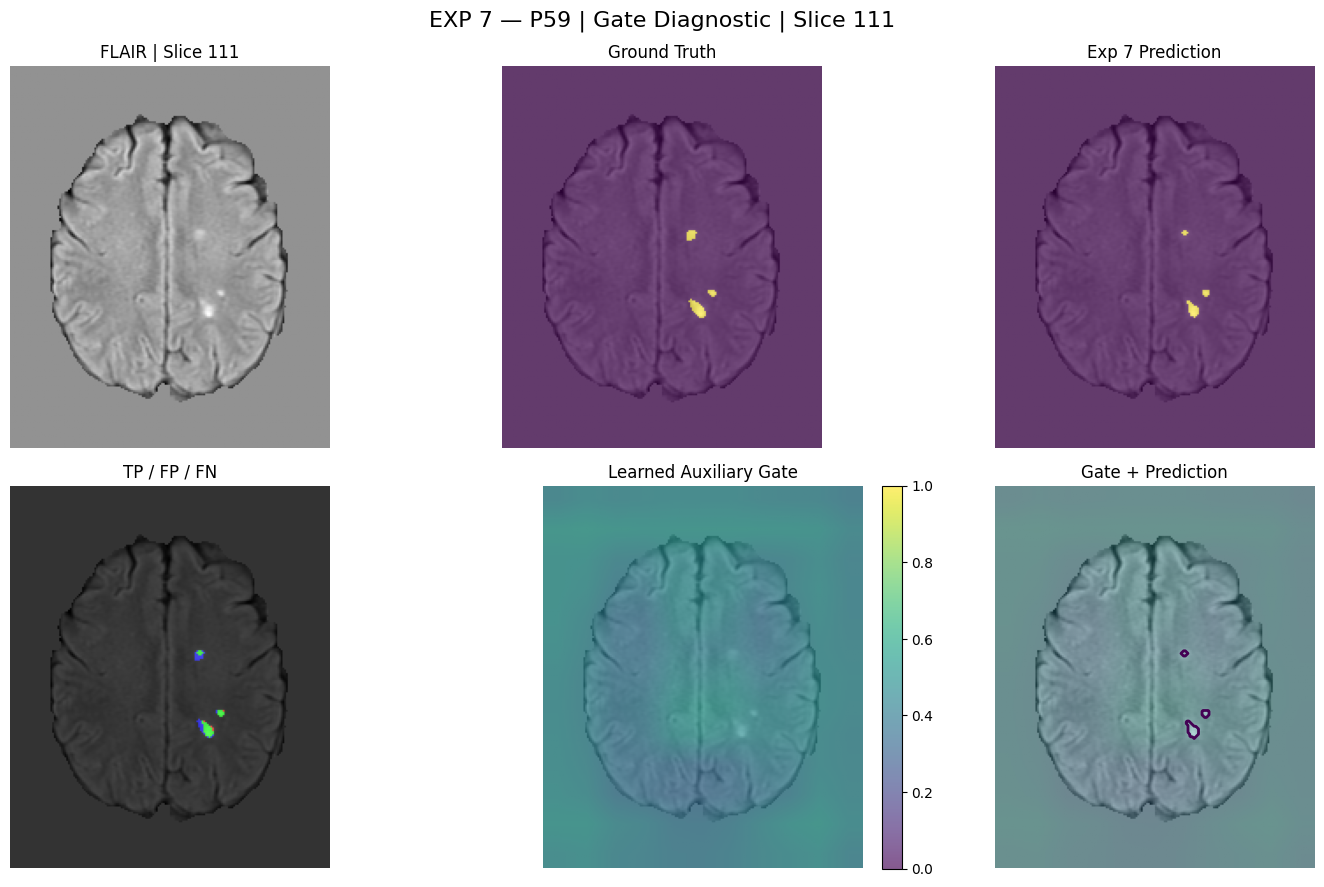


EXP 7 — P59 GATE ANALYSIS
Slice: 111
Full volume: (182, 218, 182)
GT lesion voxels on slice: 101
Predicted lesion voxels on slice: 63
TP: 58
FP: 5
FN: 43

--- GATE ---
Gate mean on GT: 0.4698
Gate median on GT: 0.4757
Gate max on GT: 0.4977
Gate mean on background: 0.4526
Gate mean on TP: 0.4724
Gate mean on FP: 0.4782
Gate mean on FN: 0.4664
Overall gate mean: 0.4526
Overall gate std: 0.0447
Overall gate min: 0.3312
Overall gate max: 0.5459

Raw gate shape: (1, 256, 11, 13, 11)
Upsampled gate shape: (1, 256, 182, 218, 182)
Final visualization gate shape: (182, 218, 182)


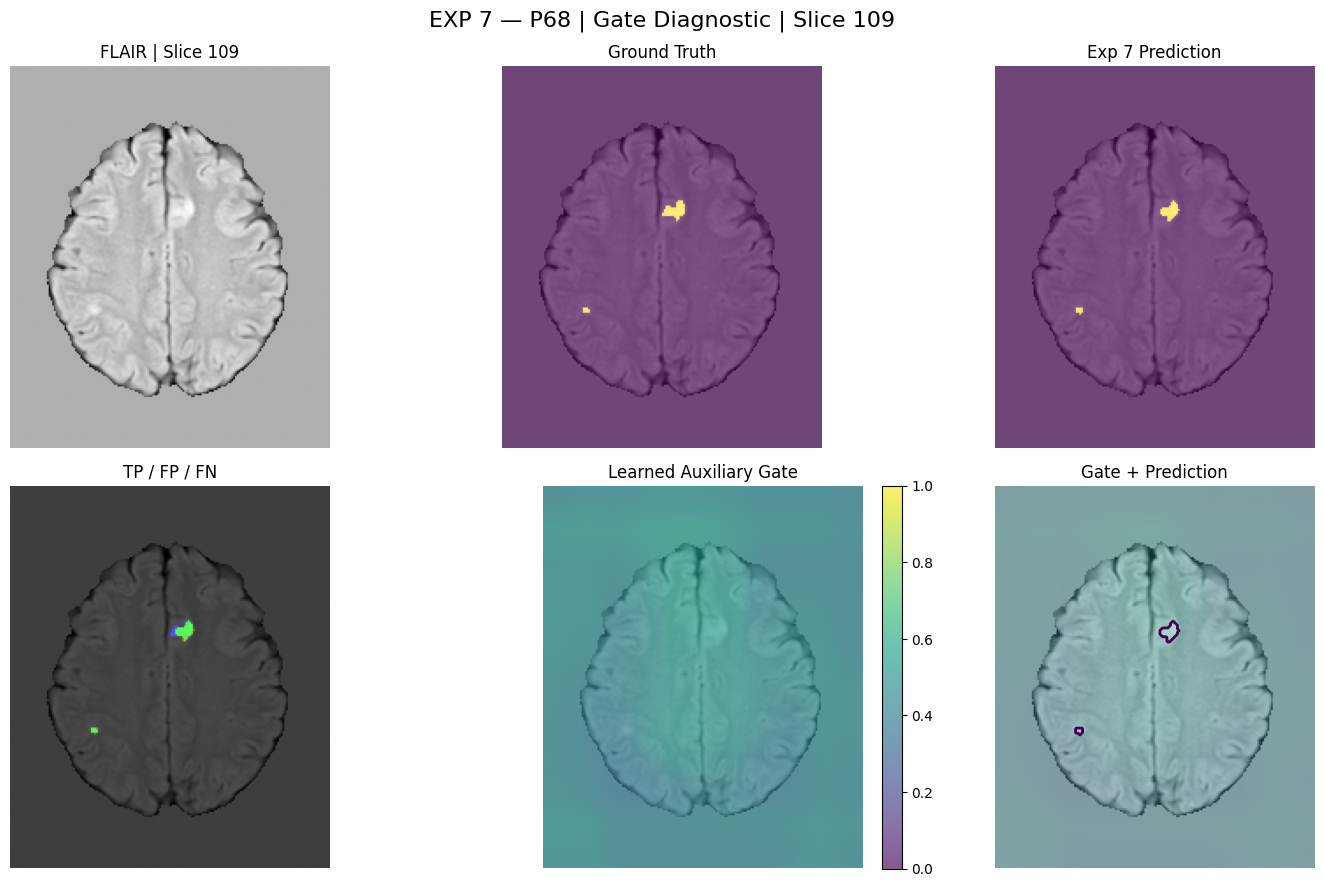


EXP 7 — P68 GATE ANALYSIS
Slice: 109
Full volume: (182, 218, 182)
GT lesion voxels on slice: 97
Predicted lesion voxels on slice: 83
TP: 77
FP: 6
FN: 20

--- GATE ---
Gate mean on GT: 0.5313
Gate median on GT: 0.5431
Gate max on GT: 0.5562
Gate mean on background: 0.4717
Gate mean on TP: 0.5265
Gate mean on FP: 0.5024
Gate mean on FN: 0.5497
Overall gate mean: 0.4719
Overall gate std: 0.0371
Overall gate min: 0.3820
Overall gate max: 0.5724

Raw gate shape: (1, 256, 11, 13, 11)
Upsampled gate shape: (1, 256, 182, 218, 182)
Final visualization gate shape: (182, 218, 182)


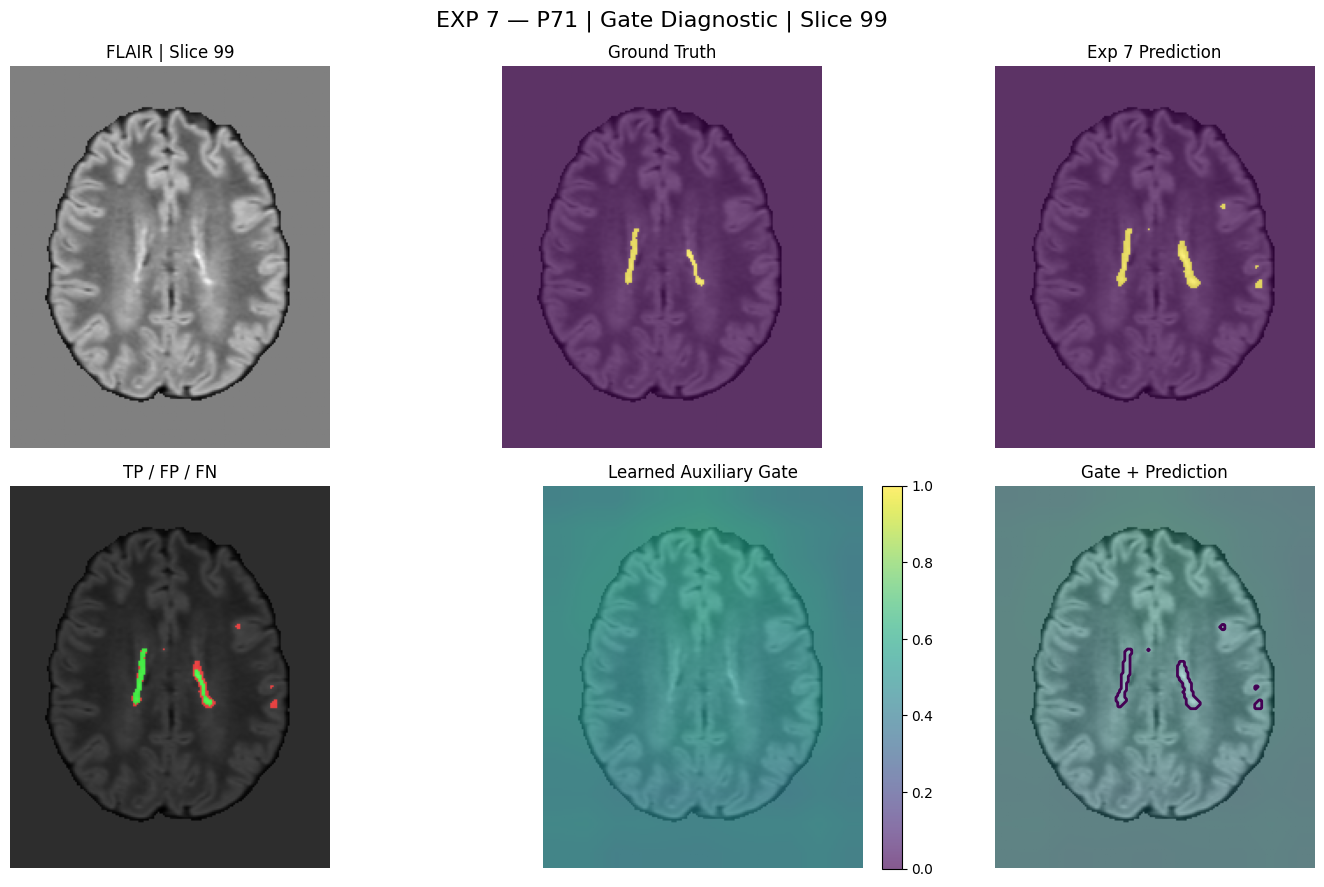


EXP 7 — P71 GATE ANALYSIS
Slice: 99
Full volume: (182, 218, 182)
GT lesion voxels on slice: 164
Predicted lesion voxels on slice: 296
TP: 164
FP: 132
FN: 0

--- GATE ---
Gate mean on GT: 0.5108
Gate median on GT: 0.5105
Gate max on GT: 0.5285
Gate mean on background: 0.4937
Gate mean on TP: 0.5108
Gate mean on FP: 0.5062
Overall gate mean: 0.4937
Overall gate std: 0.0358
Overall gate min: 0.4291
Overall gate max: 0.5944


In [20]:
# ============================================================
# EXPERIMENT 7 — KEY PATIENT GATE COMPARISON
# ============================================================

visualize_exp7_gate(
    "P59",
    slice_mode="best_gt"
)

visualize_exp7_gate(
    "P68",
    slice_mode="best_gt"
)

visualize_exp7_gate(
    "P71",
    slice_mode="best_gt"
)

In [21]:
# ============================================================
# EXPERIMENT 7 — FULL 22-PATIENT GATE AUDIT
#
# BEST MODEL:
#   Epoch 87
#   Best Validation Dice = 0.722013
#
# PURPOSE:
#   Quantify whether the learned T1/T2 gate is actually
#   selective for lesion regions.
#
# For each patient:
#
#   Gate_GT
#   Gate_Background
#   Gate_TP
#   Gate_FP
#   Gate_FN
#
# And:
#
#   ΔG_GT_BG = Gate_GT - Gate_Background
#   ΔG_FP_GT = Gate_FP - Gate_GT
#   ΔG_FN_GT = Gate_FN - Gate_GT
#
# NO TRAINING
# NO WEIGHT UPDATE
# ============================================================

import os
import gc
import numpy as np
import pandas as pd
import nibabel as nib
import torch

from monai.inferers import sliding_window_inference


# ============================================================
# 1. PATHS
# ============================================================

DATASET_ROOT = (
    r"C:\Defense_project\PROJECT_FILE"
    r"\MSLesSegDataset"
)

TEST_ROOT = os.path.join(
    DATASET_ROOT,
    "N4_Zscore_preprocessed",
    "test"
)

BEST_MODEL_EXP7 = os.path.join(
    DATASET_ROOT,
    "Experiment_7_FLAIR_Preserved_Gated",
    "best_model",
    "best_model_exp7_flair_preserved_gated.pth"
)


# ============================================================
# 2. REQUIRED MODEL
# ============================================================

if "model_exp7" not in globals():

    raise NameError(
        "model_exp7 is not available. "
        "Run the Experiment 7 architecture cell first."
    )


# ============================================================
# 3. LOAD BEST MODEL
# ============================================================

model_exp7.load_state_dict(
    torch.load(
        BEST_MODEL_EXP7,
        map_location=device,
        weights_only=True
    )
)

model_exp7.eval()


# ============================================================
# 4. SLIDING-WINDOW SEGMENTATION WRAPPER
# ============================================================

class Exp7GateAuditPredictor(
    torch.nn.Module
):

    def __init__(
        self,
        model
    ):

        super().__init__()

        self.model = model


    def forward(
        self,
        x
    ):

        return self.model(
            x
        )["logits"]


model_exp7_predictor = (
    Exp7GateAuditPredictor(
        model_exp7
    )
    .to(device)
)

model_exp7_predictor.eval()


# ============================================================
# 5. TEST PATIENTS
# ============================================================

test_patients_exp7 = sorted(
    [
        p
        for p in os.listdir(
            TEST_ROOT
        )
        if os.path.isdir(
            os.path.join(
                TEST_ROOT,
                p
            )
        )
    ],
    key=lambda x:
        int(x[1:])
        if (
            x.startswith("P")
            and
            x[1:].isdigit()
        )
        else x
)


if len(
    test_patients_exp7
) != 22:

    raise RuntimeError(
        f"Expected 22 test patients, "
        f"found {len(test_patients_exp7)}."
    )


# ============================================================
# 6. RESULT STORAGE
# ============================================================

gate_audit_results_exp7 = []


# ============================================================
# 7. PATIENT LOOP
# ============================================================

for patient_index, patient in enumerate(
    test_patients_exp7,
    start=1
):

    print(
        f"{patient_index:02d}/22 | {patient}"
    )


    patient_root = os.path.join(
        TEST_ROOT,
        patient
    )


    # ========================================================
    # PATHS
    # ========================================================

    flair_path = os.path.join(
        patient_root,
        f"{patient}_FLAIR_N4_Z.nii.gz"
    )

    t1_path = os.path.join(
        patient_root,
        f"{patient}_T1_N4_Z.nii.gz"
    )

    t2_path = os.path.join(
        patient_root,
        f"{patient}_T2_N4_Z.nii.gz"
    )

    mask_path = os.path.join(
        patient_root,
        f"{patient}_MASK.nii.gz"
    )


    # ========================================================
    # LOAD
    # ========================================================

    flair = nib.load(
        flair_path
    ).get_fdata(
        dtype=np.float32
    )

    t1 = nib.load(
        t1_path
    ).get_fdata(
        dtype=np.float32
    )

    t2 = nib.load(
        t2_path
    ).get_fdata(
        dtype=np.float32
    )

    gt = (
        nib.load(
            mask_path
        ).get_fdata(
            dtype=np.float32
        )
        > 0
    )


    # ========================================================
    # INPUT
    # ========================================================

    image = torch.from_numpy(
        np.stack(
            [
                flair,
                t1,
                t2
            ],
            axis=0
        )
    ).float()


    image_gpu = (
        image
        .unsqueeze(0)
        .to(
            device,
            non_blocking=True
        )
    )


    # ========================================================
    # 8. SEGMENTATION
    # ========================================================

    with torch.no_grad():

        with torch.autocast(
            device_type="cuda",
            dtype=torch.float16,
            enabled=torch.cuda.is_available()
        ):

            logits = (
                sliding_window_inference(

                    inputs=image_gpu,

                    roi_size=ROI_SIZE,

                    sw_batch_size=1,

                    predictor=model_exp7_predictor,

                    overlap=OVERLAP,

                    mode="gaussian"
                )
            )


    prediction = (
        torch.sigmoid(
            logits
        )
        >= 0.5
    ).squeeze().cpu().numpy()


    # ========================================================
    # 9. DIRECT FORWARD — GET GATE
    # ========================================================

    with torch.no_grad():

        direct_output = model_exp7(
            image_gpu
        )


    raw_gate = (
        direct_output[
            "gate"
        ]
        .float()
    )


    # ========================================================
    # 10. UPSAMPLE GATE
    #
    # Raw:
    #   (1, 256, Dg, Hg, Wg)
    #
    # Full:
    #   (1, 256, D, H, W)
    # ========================================================

    gate_full_channels = (
        torch.nn.functional.interpolate(

            raw_gate,

            size=flair.shape,

            mode="trilinear",

            align_corners=False
        )
    )


    # ========================================================
    # 11. MEAN ACROSS 256 GATE CHANNELS
    #
    # Final:
    #   (D, H, W)
    # ========================================================

    gate_map = (
        gate_full_channels
        .mean(
            dim=1
        )
        .squeeze(0)
        .cpu()
        .numpy()
    )


    # ========================================================
    # 12. BOOLEAN MASKS
    # ========================================================

    gt_bool = gt.astype(
        bool
    )

    pred_bool = prediction.astype(
        bool
    )


    tp_mask = (
        gt_bool
        &
        pred_bool
    )

    fp_mask = (
        ~gt_bool
        &
        pred_bool
    )

    fn_mask = (
        gt_bool
        &
        ~pred_bool
    )

    background_mask = ~gt_bool


    # ========================================================
    # 13. PATIENT-LEVEL CONFUSION COUNTS
    # ========================================================

    tp = int(
        tp_mask.sum()
    )

    fp = int(
        fp_mask.sum()
    )

    fn = int(
        fn_mask.sum()
    )


    # ========================================================
    # 14. PATIENT-LEVEL METRICS
    # ========================================================

    precision = (
        tp
        /
        (
            tp
            +
            fp
        )
        if (
            tp
            +
            fp
        ) > 0
        else 0.0
    )


    recall = (
        tp
        /
        (
            tp
            +
            fn
        )
        if (
            tp
            +
            fn
        ) > 0
        else 0.0
    )


    dice = (
        2.0
        *
        tp
        /
        (
            2.0
            *
            tp
            +
            fp
            +
            fn
        )
        if (
            2.0
            *
            tp
            +
            fp
            +
            fn
        ) > 0
        else 1.0
    )


    iou = (
        tp
        /
        (
            tp
            +
            fp
            +
            fn
        )
        if (
            tp
            +
            fp
            +
            fn
        ) > 0
        else 1.0
    )


    # ========================================================
    # 15. GATE GROUP STATISTICS
    # ========================================================

    gate_gt = gate_map[
        gt_bool
    ]

    gate_background = gate_map[
        background_mask
    ]

    gate_tp = gate_map[
        tp_mask
    ]

    gate_fp = gate_map[
        fp_mask
    ]

    gate_fn = gate_map[
        fn_mask
    ]


    # ========================================================
    # 16. SAFE MEAN HELPER
    # ========================================================

    def safe_mean(
        values
    ):

        if values.size == 0:

            return np.nan

        return float(
            np.mean(
                values
            )
        )


    def safe_median(
        values
    ):

        if values.size == 0:

            return np.nan

        return float(
            np.median(
                values
            )
        )


    def safe_std(
        values
    ):

        if values.size == 0:

            return np.nan

        return float(
            np.std(
                values
            )
        )


    # ========================================================
    # 17. MEANS
    # ========================================================

    mean_gt = safe_mean(
        gate_gt
    )

    mean_background = safe_mean(
        gate_background
    )

    mean_tp = safe_mean(
        gate_tp
    )

    mean_fp = safe_mean(
        gate_fp
    )

    mean_fn = safe_mean(
        gate_fn
    )


    # ========================================================
    # 18. DELTAS
    # ========================================================

    delta_gt_background = (
        mean_gt
        -
        mean_background
    )

    delta_fp_gt = (
        mean_fp
        -
        mean_gt
        if not np.isnan(mean_fp)
        else np.nan
    )

    delta_fn_gt = (
        mean_fn
        -
        mean_gt
        if not np.isnan(mean_fn)
        else np.nan
    )


    # ========================================================
    # 19. STORE
    # ========================================================

    gate_audit_results_exp7.append({

        "Patient":
            patient,

        # --------------------------------
        # segmentation
        # --------------------------------

        "TP":
            tp,

        "FP":
            fp,

        "FN":
            fn,

        "Precision":
            precision,

        "Recall":
            recall,

        "Dice":
            dice,

        "IoU":
            iou,

        # --------------------------------
        # gate
        # --------------------------------

        "Gate_GT_Mean":
            mean_gt,

        "Gate_GT_Median":
            safe_median(
                gate_gt
            ),

        "Gate_GT_Std":
            safe_std(
                gate_gt
            ),

        "Gate_Background_Mean":
            mean_background,

        "Gate_TP_Mean":
            mean_tp,

        "Gate_FP_Mean":
            mean_fp,

        "Gate_FN_Mean":
            mean_fn,

        # --------------------------------
        # deltas
        # --------------------------------

        "Delta_GT_vs_Background":
            delta_gt_background,

        "Delta_FP_vs_GT":
            delta_fp_gt,

        "Delta_FN_vs_GT":
            delta_fn_gt,

        # --------------------------------
        # gate overall
        # --------------------------------

        "Gate_Overall_Mean":
            float(
                gate_map.mean()
            ),

        "Gate_Overall_Std":
            float(
                gate_map.std()
            ),

        "Gate_Overall_Min":
            float(
                gate_map.min()
            ),

        "Gate_Overall_Max":
            float(
                gate_map.max()
            )
    })


    # ========================================================
    # CLEAN
    # ========================================================

    del flair
    del t1
    del t2
    del gt

    del image
    del image_gpu

    del logits
    del prediction

    del direct_output
    del raw_gate
    del gate_full_channels
    del gate_map

    del gt_bool
    del pred_bool

    del tp_mask
    del fp_mask
    del fn_mask
    del background_mask

    del gate_gt
    del gate_background
    del gate_tp
    del gate_fp
    del gate_fn

    if torch.cuda.is_available():

        torch.cuda.empty_cache()

    gc.collect()


# ============================================================
# 20. DATAFRAME
# ============================================================

gate_audit_df_exp7 = pd.DataFrame(
    gate_audit_results_exp7
)


# ============================================================
# 21. SORT BY GT-BACKGROUND SEPARATION
# ============================================================

gate_audit_df_exp7 = (
    gate_audit_df_exp7
    .sort_values(
        "Delta_GT_vs_Background",
        ascending=False
    )
    .reset_index(
        drop=True
    )
)


# ============================================================
# 22. DISPLAY FULL TABLE
# ============================================================

print("\n" + "=" * 120)
print(
    "EXPERIMENT 7 — FULL 22-PATIENT GATE AUDIT"
)
print("=" * 120)

display(
    gate_audit_df_exp7[
        [
            "Patient",
            "Dice",
            "Precision",
            "Recall",
            "TP",
            "FP",
            "FN",
            "Gate_GT_Mean",
            "Gate_Background_Mean",
            "Gate_TP_Mean",
            "Gate_FP_Mean",
            "Gate_FN_Mean",
            "Delta_GT_vs_Background",
            "Delta_FP_vs_GT",
            "Delta_FN_vs_GT"
        ]
    ]
)


# ============================================================
# 23. OVERALL SUMMARY
# ============================================================

print("\n" + "=" * 120)
print(
    "EXPERIMENT 7 — GATE AUDIT SUMMARY"
)
print("=" * 120)


print(
    "Mean Gate GT:",
    f"{gate_audit_df_exp7['Gate_GT_Mean'].mean():.4f}"
)

print(
    "Mean Gate Background:",
    f"{gate_audit_df_exp7['Gate_Background_Mean'].mean():.4f}"
)

print(
    "Mean Gate TP:",
    f"{gate_audit_df_exp7['Gate_TP_Mean'].mean():.4f}"
)

print(
    "Mean Gate FP:",
    f"{gate_audit_df_exp7['Gate_FP_Mean'].mean():.4f}"
)

print(
    "Mean Gate FN:",
    f"{gate_audit_df_exp7['Gate_FN_Mean'].mean():.4f}"
)


print(
    "\nMean ΔG(GT - Background):",
    f"{gate_audit_df_exp7['Delta_GT_vs_Background'].mean():.4f}"
)

print(
    "Mean ΔG(FP - GT):",
    f"{gate_audit_df_exp7['Delta_FP_vs_GT'].mean():.4f}"
)

print(
    "Mean ΔG(FN - GT):",
    f"{gate_audit_df_exp7['Delta_FN_vs_GT'].mean():.4f}"
)


# ============================================================
# 24. MEDIANS ACROSS PATIENTS
# ============================================================

print(
    "\nMedian ΔG(GT - Background):",
    f"{gate_audit_df_exp7['Delta_GT_vs_Background'].median():.4f}"
)

print(
    "Median ΔG(FP - GT):",
    f"{gate_audit_df_exp7['Delta_FP_vs_GT'].median():.4f}"
)

print(
    "Median ΔG(FN - GT):",
    f"{gate_audit_df_exp7['Delta_FN_vs_GT'].median():.4f}"
)


# ============================================================
# 25. HOW MANY PATIENTS HAVE:
#
# GT gate > background
# ============================================================

gt_better_count = (
    gate_audit_df_exp7[
        "Delta_GT_vs_Background"
    ]
    > 0
).sum()


fp_lower_than_gt_count = (
    gate_audit_df_exp7[
        "Delta_FP_vs_GT"
    ]
    < 0
).sum()


fn_higher_than_gt_count = (
    gate_audit_df_exp7[
        "Delta_FN_vs_GT"
    ]
    > 0
).sum()


print("\n" + "=" * 120)
print("PATIENT COUNTS")
print("=" * 120)

print(
    "Patients where Gate(GT) > Gate(background):",
    f"{gt_better_count}/22"
)

print(
    "Patients where Gate(FP) < Gate(GT):",
    f"{fp_lower_than_gt_count}/22"
)

print(
    "Patients where Gate(FN) > Gate(GT):",
    f"{fn_higher_than_gt_count}/22"
)


# ============================================================
# 26. WORST GATE SELECTIVITY
# ============================================================

print("\n" + "=" * 120)
print(
    "LOWEST GT-BACKGROUND GATE SEPARATION"
)
print("=" * 120)

display(
    gate_audit_df_exp7[
        [
            "Patient",
            "Dice",
            "Precision",
            "Recall",
            "Gate_GT_Mean",
            "Gate_Background_Mean",
            "Delta_GT_vs_Background",
            "Gate_FP_Mean",
            "Gate_FN_Mean"
        ]
    ]
    .sort_values(
        "Delta_GT_vs_Background",
        ascending=True
    )
    .head(10)
)


# ============================================================
# 27. MOST FP-PROBLEMATIC PATIENTS
# ============================================================

print("\n" + "=" * 120)
print(
    "PATIENTS WHERE FP GATE IS HIGH RELATIVE TO GT"
)
print("=" * 120)

display(
    gate_audit_df_exp7[
        [
            "Patient",
            "Precision",
            "Dice",
            "Gate_GT_Mean",
            "Gate_FP_Mean",
            "Delta_FP_vs_GT",
            "FP"
        ]
    ]
    .sort_values(
        "Delta_FP_vs_GT",
        ascending=False
    )
    .head(10)
)


# ============================================================
# 28. FN GATE ANALYSIS
# ============================================================

print("\n" + "=" * 120)
print(
    "PATIENTS WHERE FN GATE IS HIGHER THAN GT"
)
print("=" * 120)

display(
    gate_audit_df_exp7[
        [
            "Patient",
            "Recall",
            "Dice",
            "Gate_GT_Mean",
            "Gate_FN_Mean",
            "Delta_FN_vs_GT",
            "FN"
        ]
    ]
    .sort_values(
        "Delta_FN_vs_GT",
        ascending=False
    )
    .head(10)
)


# ============================================================
# 29. SAVE
# ============================================================

GATE_AUDIT_CSV = os.path.join(
    DATASET_ROOT,
    "Experiment_7_gate_audit_22_patients.csv"
)


gate_audit_df_exp7.to_csv(
    GATE_AUDIT_CSV,
    index=False
)


print("\n" + "=" * 120)
print("GATE AUDIT SAVED")
print("=" * 120)

print(
    GATE_AUDIT_CSV
)

print("=" * 120)

01/22 | P54
02/22 | P55
03/22 | P56
04/22 | P57
05/22 | P58
06/22 | P59
07/22 | P60
08/22 | P61
09/22 | P62
10/22 | P63
11/22 | P64
12/22 | P65
13/22 | P66
14/22 | P67
15/22 | P68
16/22 | P69
17/22 | P70
18/22 | P71
19/22 | P72
20/22 | P73
21/22 | P74
22/22 | P75

EXPERIMENT 7 — FULL 22-PATIENT GATE AUDIT


,Patient,Dice,Precision,Recall,TP,FP,FN,Gate_GT_Mean,Gate_Background_Mean,Gate_TP_Mean,Gate_FP_Mean,Gate_FN_Mean,Delta_GT_vs_Background,Delta_FP_vs_GT,Delta_FN_vs_GT
0,P75,0.731266,0.731763,0.730769,6992,2563,2576,0.546800,0.455348,0.546931,0.536343,0.546446,0.091452,-0.010457,-0.000354
1,P56,0.707351,0.688817,0.726910,1275,576,479,0.545659,0.455796,0.540630,0.530516,0.559046,0.089863,-0.015143,0.013387
2,P74,0.594785,0.502448,0.728702,1437,1423,535,0.543211,0.455348,0.546815,0.562475,0.533529,0.087863,0.019264,-0.009681
3,P67,0.695422,0.634228,0.769687,18033,10400,5396,0.535797,0.453664,0.531148,0.502979,0.551333,0.082133,-0.032818,0.015536
4,P65,0.747600,0.733462,0.762294,19315,7019,6023,0.527158,0.452465,0.535268,0.556305,0.501151,0.074692,0.029147,-0.026007
5,P69,0.778377,0.731894,0.831164,4982,1825,1012,0.527039,0.456036,0.528466,0.550736,0.520014,0.071003,0.023697,-0.007025
6,P62,0.674182,0.632196,0.722143,3020,1757,1162,0.518793,0.455738,0.520479,0.504814,0.514410,0.063055,-0.013979,-0.004383
7,P57,0.749244,0.813945,0.694071,29219,6679,12879,0.516868,0.453911,0.523722,0.547189,0.501317,0.062957,0.030322,-0.015551
8,P73,0.719277,0.691215,0.749713,9151,4088,3055,0.518700,0.457042,0.514915,0.520888,0.530039,0.061658,0.002187,0.011338
9,P55,0.581540,0.501251,0.692455,3607,3589,1602,0.509411,0.455546,0.516388,0.525495,0.493700,0.053865,0.016084,-0.015711



EXPERIMENT 7 — GATE AUDIT SUMMARY
Mean Gate GT: 0.4999
Mean Gate Background: 0.4561
Mean Gate TP: 0.4995
Mean Gate FP: 0.5057
Mean Gate FN: 0.5026

Mean ΔG(GT - Background): 0.0438
Mean ΔG(FP - GT): 0.0058
Mean ΔG(FN - GT): 0.0027

Median ΔG(GT - Background): 0.0435
Median ΔG(FP - GT): 0.0012
Median ΔG(FN - GT): 0.0014

PATIENT COUNTS
Patients where Gate(GT) > Gate(background): 21/22
Patients where Gate(FP) < Gate(GT): 10/22
Patients where Gate(FN) > Gate(GT): 12/22

LOWEST GT-BACKGROUND GATE SEPARATION


,Patient,Dice,Precision,Recall,Gate_GT_Mean,Gate_Background_Mean,Delta_GT_vs_Background,Gate_FP_Mean,Gate_FN_Mean
21,P64,0.560325,0.420598,0.839076,0.396225,0.456650,-0.060425,0.385702,0.400969
20,P66,0.654328,0.570500,0.767033,0.462433,0.454761,0.007672,0.518407,0.460086
19,P70,0.598095,0.450023,0.891392,0.463872,0.455957,0.007915,0.445097,0.495435
18,P54,0.436797,0.282503,0.962462,0.466360,0.457183,0.009177,0.472921,0.486729
17,P71,0.434943,0.287033,0.897358,0.481065,0.460140,0.020925,0.481253,0.489509
16,P60,0.526920,0.387715,0.822079,0.481567,0.458195,0.023373,0.453839,0.500337
15,P58,0.547377,0.506159,0.595904,0.486791,0.458899,0.027891,0.504208,0.482868
14,P63,0.658295,0.538226,0.847318,0.488292,0.459887,0.028405,0.465759,0.498491
13,P61,0.548237,0.394957,0.895948,0.494752,0.459208,0.035544,0.491563,0.495234
12,P59,0.100117,0.058277,0.354973,0.491618,0.453854,0.037764,0.570435,0.499076



PATIENTS WHERE FP GATE IS HIGH RELATIVE TO GT


,Patient,Precision,Dice,Gate_GT_Mean,Gate_FP_Mean,Delta_FP_vs_GT,FP
12,P59,0.058277,0.100117,0.491618,0.570435,0.078817,13784
20,P66,0.570500,0.654328,0.462433,0.518407,0.055974,9781
7,P57,0.813945,0.749244,0.516868,0.547189,0.030322,6679
4,P65,0.733462,0.747600,0.527158,0.556305,0.029147,7019
5,P69,0.731894,0.778377,0.527039,0.550736,0.023697,1825
2,P74,0.502448,0.594785,0.543211,0.562475,0.019264,1423
15,P58,0.506159,0.547377,0.486791,0.504208,0.017417,3889
9,P55,0.501251,0.581540,0.509411,0.525495,0.016084,3589
18,P54,0.282503,0.436797,0.466360,0.472921,0.006561,3256
10,P72,0.837120,0.788343,0.497134,0.500197,0.003063,4782



PATIENTS WHERE FN GATE IS HIGHER THAN GT


,Patient,Recall,Dice,Gate_GT_Mean,Gate_FN_Mean,Delta_FN_vs_GT,FN
19,P70,0.891392,0.598095,0.463872,0.495435,0.031563,1056
18,P54,0.962462,0.436797,0.466360,0.486729,0.020369,50
16,P60,0.822079,0.526920,0.481567,0.500337,0.018769,1183
3,P67,0.769687,0.695422,0.535797,0.551333,0.015536,5396
1,P56,0.726910,0.707351,0.545659,0.559046,0.013387,479
8,P73,0.749713,0.719277,0.518700,0.530039,0.011338,3055
14,P63,0.847318,0.658295,0.488292,0.498491,0.010200,444
17,P71,0.897358,0.434943,0.481065,0.489509,0.008444,338
12,P59,0.354973,0.100117,0.491618,0.499076,0.007457,1550
21,P64,0.839076,0.560325,0.396225,0.400969,0.004744,766



GATE AUDIT SAVED
C:\Defense_project\PROJECT_FILE\MSLesSegDataset\Experiment_7_gate_audit_22_patients.csv


# model phase 2

In [26]:
# ============================================================
# EXPERIMENT 7 — PHASE 2
# FLAIR-PRESERVED RESIDUAL MULTIMODAL CORRECTION
#
# CORE IDEA:
#
#   Final logits =
#       FLAIR baseline logits
#       +
#       correction_scale * multimodal correction logits
#
# IMPORTANT:
#   - FLAIR makes the primary prediction.
#   - T1/T2 cannot directly replace the FLAIR prediction.
#   - Correction head starts at ZERO.
#   - Same loss as Phase 1.
#   - Same sampling as Phase 1.
#
# PHASE 2 ONLY CHANGES:
#   Architecture.
# ============================================================

import torch
import torch.nn as nn
import torch.nn.functional as F


# ============================================================
# 1. BASIC CONV BLOCK
# ============================================================

class ResidualConvBlock3D(nn.Module):

    def __init__(
        self,
        in_channels,
        out_channels
    ):

        super().__init__()

        self.block = nn.Sequential(

            nn.Conv3d(
                in_channels,
                out_channels,
                kernel_size=3,
                padding=1,
                bias=False
            ),

            nn.InstanceNorm3d(
                out_channels
            ),

            nn.PReLU(
                out_channels
            ),

            nn.Conv3d(
                out_channels,
                out_channels,
                kernel_size=3,
                padding=1,
                bias=False
            ),

            nn.InstanceNorm3d(
                out_channels
            ),

            nn.PReLU(
                out_channels
            )
        )


    def forward(self, x):

        return self.block(x)


# ============================================================
# 2. ENCODER BLOCK
# ============================================================

class ResidualEncoderBlock3D(nn.Module):

    def __init__(
        self,
        in_channels,
        out_channels
    ):

        super().__init__()

        self.conv = ResidualConvBlock3D(
            in_channels,
            out_channels
        )

        self.down = nn.Conv3d(
            out_channels,
            out_channels,
            kernel_size=2,
            stride=2
        )


    def forward(self, x):

        features = self.conv(x)

        down = self.down(
            features
        )

        return features, down


# ============================================================
# 3. GATED FUSION
# ============================================================

class ResidualGatedFusion3D(nn.Module):

    def __init__(
        self,
        channels
    ):

        super().__init__()

        self.gate = nn.Sequential(

            nn.Conv3d(
                channels * 2,
                channels,
                kernel_size=1
            ),

            nn.Sigmoid()
        )


        self.refine = nn.Sequential(

            nn.Conv3d(
                channels,
                channels,
                kernel_size=3,
                padding=1,
                bias=False
            ),

            nn.InstanceNorm3d(
                channels
            ),

            nn.PReLU(
                channels
            )
        )


    def forward(
        self,
        flair_features,
        auxiliary_features
    ):

        gate_input = torch.cat(
            [
                flair_features,
                auxiliary_features
            ],
            dim=1
        )


        gate = self.gate(
            gate_input
        )


        # ----------------------------------------------------
        # FLAIR is preserved.
        # T1/T2 only provide additive auxiliary information.
        # ----------------------------------------------------

        fused = (
            flair_features
            +
            gate * auxiliary_features
        )


        fused = self.refine(
            fused
        )


        return fused, gate


# ============================================================
# 4. DECODER BLOCK
# ============================================================

class ResidualDecoderBlock3D(nn.Module):

    def __init__(
        self,
        in_channels,
        skip_channels,
        out_channels
    ):

        super().__init__()

        self.up = nn.ConvTranspose3d(
            in_channels,
            out_channels,
            kernel_size=2,
            stride=2
        )


        self.conv = ResidualConvBlock3D(
            out_channels + skip_channels,
            out_channels
        )


    def forward(
        self,
        x,
        skip
    ):

        x = self.up(x)


        if x.shape[2:] != skip.shape[2:]:

            x = F.interpolate(
                x,
                size=skip.shape[2:],
                mode="trilinear",
                align_corners=False
            )


        x = torch.cat(
            [
                x,
                skip
            ],
            dim=1
        )


        return self.conv(x)


# ============================================================
# 5. MAIN PHASE 2 MODEL
# ============================================================

class FLAIRPreservedResidualNet3D(
    nn.Module
):


    def __init__(
        self,
        base_channels=16,
        correction_scale=0.50
    ):

        super().__init__()


        self.base_channels = (
            base_channels
        )


        self.correction_scale = (
            correction_scale
        )


        # ====================================================
        # FLAIR PRIMARY ENCODER
        # ====================================================

        self.flair_encoder1 = (
            ResidualEncoderBlock3D(
                1,
                base_channels
            )
        )

        self.flair_encoder2 = (
            ResidualEncoderBlock3D(
                base_channels,
                base_channels * 2
            )
        )

        self.flair_encoder3 = (
            ResidualEncoderBlock3D(
                base_channels * 2,
                base_channels * 4
            )
        )

        self.flair_encoder4 = (
            ResidualEncoderBlock3D(
                base_channels * 4,
                base_channels * 8
            )
        )


        # ====================================================
        # T1 + T2 AUXILIARY ENCODER
        # ====================================================

        self.aux_encoder1 = (
            ResidualEncoderBlock3D(
                2,
                base_channels
            )
        )

        self.aux_encoder2 = (
            ResidualEncoderBlock3D(
                base_channels,
                base_channels * 2
            )
        )

        self.aux_encoder3 = (
            ResidualEncoderBlock3D(
                base_channels * 2,
                base_channels * 4
            )
        )

        self.aux_encoder4 = (
            ResidualEncoderBlock3D(
                base_channels * 4,
                base_channels * 8
            )
        )


        # ====================================================
        # BOTTLENECKS
        # ====================================================

        self.flair_bottleneck = (
            ResidualConvBlock3D(
                base_channels * 8,
                base_channels * 16
            )
        )

        self.aux_bottleneck = (
            ResidualConvBlock3D(
                base_channels * 8,
                base_channels * 16
            )
        )


        # ====================================================
        # GATED FUSION
        # ====================================================

        self.gated_fusion = (
            ResidualGatedFusion3D(
                base_channels * 16
            )
        )


        # ====================================================
        # PRIMARY FLAIR DECODER
        #
        # This produces the baseline prediction.
        # ====================================================

        self.flair_decoder4 = (
            ResidualDecoderBlock3D(
                base_channels * 16,
                base_channels * 8,
                base_channels * 8
            )
        )

        self.flair_decoder3 = (
            ResidualDecoderBlock3D(
                base_channels * 8,
                base_channels * 4,
                base_channels * 4
            )
        )

        self.flair_decoder2 = (
            ResidualDecoderBlock3D(
                base_channels * 4,
                base_channels * 2,
                base_channels * 2
            )
        )

        self.flair_decoder1 = (
            ResidualDecoderBlock3D(
                base_channels * 2,
                base_channels,
                base_channels
            )
        )


        # ====================================================
        # PRIMARY FLAIR HEAD
        # ====================================================

        self.flair_head = nn.Conv3d(
            base_channels,
            1,
            kernel_size=1
        )


        # ====================================================
        # MULTIMODAL CORRECTION DECODER
        #
        # Lighter correction branch.
        # ====================================================

        self.correction_decoder4 = (
            ResidualDecoderBlock3D(
                base_channels * 16,
                base_channels * 8,
                base_channels * 8
            )
        )

        self.correction_decoder3 = (
            ResidualDecoderBlock3D(
                base_channels * 8,
                base_channels * 4,
                base_channels * 4
            )
        )

        self.correction_decoder2 = (
            ResidualDecoderBlock3D(
                base_channels * 4,
                base_channels * 2,
                base_channels * 2
            )
        )

        self.correction_decoder1 = (
            ResidualDecoderBlock3D(
                base_channels * 2,
                base_channels,
                base_channels
            )
        )


        # ====================================================
        # CORRECTION HEAD
        #
        # IMPORTANT:
        # Zero initialization means:
        #
        #   correction = 0
        #
        # at initialization.
        #
        # Therefore:
        #
        #   final = flair prediction
        #
        # initially.
        # ====================================================

        self.correction_head = nn.Conv3d(
            base_channels,
            1,
            kernel_size=1
        )


        nn.init.zeros_(
            self.correction_head.weight
        )

        nn.init.zeros_(
            self.correction_head.bias
        )


        # ====================================================
        # DIAGNOSTIC STORAGE
        # ====================================================

        self.last_gate = None

        self.last_flair_logits = None

        self.last_correction_logits = None


    def forward(
        self,
        x
    ):

        # ====================================================
        # SPLIT MODALITIES
        # ====================================================

        flair = x[
            :,
            0:1
        ]

        auxiliary = x[
            :,
            1:3
        ]


        # ====================================================
        # FLAIR ENCODER
        # ====================================================

        flair_s1, flair_d1 = (
            self.flair_encoder1(
                flair
            )
        )

        flair_s2, flair_d2 = (
            self.flair_encoder2(
                flair_d1
            )
        )

        flair_s3, flair_d3 = (
            self.flair_encoder3(
                flair_d2
            )
        )

        flair_s4, flair_d4 = (
            self.flair_encoder4(
                flair_d3
            )
        )


        # ====================================================
        # AUXILIARY ENCODER
        # ====================================================

        aux_s1, aux_d1 = (
            self.aux_encoder1(
                auxiliary
            )
        )

        aux_s2, aux_d2 = (
            self.aux_encoder2(
                aux_d1
            )
        )

        aux_s3, aux_d3 = (
            self.aux_encoder3(
                aux_d2
            )
        )

        aux_s4, aux_d4 = (
            self.aux_encoder4(
                aux_d3
            )
        )


        # ====================================================
        # BOTTLENECK
        # ====================================================

        flair_b = self.flair_bottleneck(
            flair_d4
        )

        aux_b = self.aux_bottleneck(
            aux_d4
        )


        # ====================================================
        # GATED FUSION
        # ====================================================

        fused_b, gate = (
            self.gated_fusion(
                flair_b,
                aux_b
            )
        )


        # ====================================================
        # PRIMARY FLAIR DECODER
        #
        # Notice:
        # The primary branch starts from FLAIR bottleneck,
        # not fused bottleneck.
        #
        # This protects the FLAIR prediction.
        # ====================================================

        f4 = self.flair_decoder4(
            flair_b,
            flair_s4
        )

        f3 = self.flair_decoder3(
            f4,
            flair_s3
        )

        f2 = self.flair_decoder2(
            f3,
            flair_s2
        )

        f1 = self.flair_decoder1(
            f2,
            flair_s1
        )


        # ====================================================
        # FLAIR BASE PREDICTION
        # ====================================================

        flair_logits = (
            self.flair_head(
                f1
            )
        )


        # ====================================================
        # CORRECTION DECODER
        #
        # Uses fused multimodal bottleneck.
        # Still uses FLAIR spatial skip features.
        # ====================================================

        c4 = self.correction_decoder4(
            fused_b,
            flair_s4
        )

        c3 = self.correction_decoder3(
            c4,
            flair_s3
        )

        c2 = self.correction_decoder2(
            c3,
            flair_s2
        )

        c1 = self.correction_decoder1(
            c2,
            flair_s1
        )


        # ====================================================
        # RAW CORRECTION
        # ====================================================

        correction_logits = (
            self.correction_head(
                c1
            )
        )


        # ====================================================
        # CONSTRAINED RESIDUAL CORRECTION
        #
        # tanh keeps the correction bounded.
        #
        # Final:
        #
        #   Flair + 0.50 * bounded correction
        # ====================================================

        bounded_correction = (
            torch.tanh(
                correction_logits
            )
        )


        final_logits = (
            flair_logits
            +
            self.correction_scale
            *
            bounded_correction
        )


        # ====================================================
        # STORE DIAGNOSTIC VALUES
        # ====================================================

        self.last_gate = gate

        self.last_flair_logits = (
            flair_logits
        )

        self.last_correction_logits = (
            correction_logits
        )


        # ====================================================
        # RETURN
        # ====================================================

        return {

            "logits":
                final_logits,

            "flair_logits":
                flair_logits,

            "correction_logits":
                correction_logits,

            "gate":
                gate
        }


# ============================================================
# 6. CREATE MODEL
# ============================================================

model_exp7_phase2 = (
    FLAIRPreservedResidualNet3D(
        base_channels=FEATURE_SIZE,
        correction_scale=0.50
    )
    .to(device)
)


# ============================================================
# 7. PARAMETER COUNT
# ============================================================

total_params_phase2 = sum(
    p.numel()
    for p in model_exp7_phase2.parameters()
)

trainable_params_phase2 = sum(
    p.numel()
    for p in model_exp7_phase2.parameters()
    if p.requires_grad
)


print("=" * 110)
print("EXPERIMENT 7 — PHASE 2 MODEL CREATED")
print("=" * 110)

print(
    "Input:",
    "FLAIR + T1 + T2"
)

print(
    "Primary branch:",
    "FLAIR"
)

print(
    "Auxiliary branch:",
    "T1 + T2"
)

print(
    "Fusion:",
    "Gated"
)

print(
    "Correction:",
    "Bounded residual"
)

print(
    "Correction scale:",
    0.50
)

print(
    "Correction head:",
    "ZERO INITIALIZED"
)

print(
    "Total parameters:",
    f"{total_params_phase2:,}"
)

print(
    "Trainable parameters:",
    f"{trainable_params_phase2:,}"
)

print("=" * 110)

EXPERIMENT 7 — PHASE 2 MODEL CREATED
Input: FLAIR + T1 + T2
Primary branch: FLAIR
Auxiliary branch: T1 + T2
Fusion: Gated
Correction: Bounded residual
Correction scale: 0.5
Correction head: ZERO INITIALIZED
Total parameters: 13,539,954
Trainable parameters: 13,539,954


In [27]:
# ============================================================
# EXPERIMENT 7 — PHASE 2
# RESIDUAL INITIALIZATION CHECK
# ============================================================

print("=" * 110)
print("EXPERIMENT 7 — PHASE 2 INITIALIZATION CHECK")
print("=" * 110)


model_exp7_phase2.eval()


# ============================================================
# 1. DUMMY INPUT
# ============================================================

dummy_input_phase2 = torch.randn(
    1,
    3,
    144,
    144,
    144,
    device=device
)


# ============================================================
# 2. FORWARD
# ============================================================

with torch.no_grad():

    output_phase2 = (
        model_exp7_phase2(
            dummy_input_phase2
        )
    )


# ============================================================
# 3. SHAPES
# ============================================================

print(
    "Final logits:",
    tuple(
        output_phase2[
            "logits"
        ].shape
    )
)

print(
    "FLAIR logits:",
    tuple(
        output_phase2[
            "flair_logits"
        ].shape
    )
)

print(
    "Correction logits:",
    tuple(
        output_phase2[
            "correction_logits"
        ].shape
    )
)

print(
    "Gate:",
    tuple(
        output_phase2[
            "gate"
        ].shape
    )
)


# ============================================================
# 4. CORRECTION CHECK
# ============================================================

correction = output_phase2[
    "correction_logits"
]

flair_logits = output_phase2[
    "flair_logits"
]

final_logits = output_phase2[
    "logits"
]


print(
    "\nCorrection mean:",
    float(
        correction.mean()
    )
)

print(
    "Correction absolute max:",
    float(
        correction.abs().max()
    )
)


# ============================================================
# 5. FINAL vs FLAIR
# ============================================================

difference = (
    final_logits
    -
    flair_logits
)


print(
    "\nFinal - FLAIR max difference:",
    float(
        difference.abs().max()
    )
)


# ============================================================
# 6. EXPECTED
# ============================================================

if float(
    correction.abs().max()
) != 0.0:

    raise RuntimeError(
        "Correction head is not zero initialized."
    )


if float(
    difference.abs().max()
) != 0.0:

    raise RuntimeError(
        "Final prediction is not equal to "
        "FLAIR baseline at initialization."
    )


print(
    "\n✓ Correction head starts at zero."
)

print(
    "✓ Initial final logits = FLAIR logits."
)

print(
    "✓ Phase 2 residual initialization is correct."
)


# ============================================================
# 7. CLEAN
# ============================================================

del dummy_input_phase2
del output_phase2
del correction
del flair_logits
del final_logits
del difference


if torch.cuda.is_available():

    torch.cuda.empty_cache()


print("=" * 110)

EXPERIMENT 7 — PHASE 2 INITIALIZATION CHECK
Final logits: (1, 1, 144, 144, 144)
FLAIR logits: (1, 1, 144, 144, 144)
Correction logits: (1, 1, 144, 144, 144)
Gate: (1, 256, 9, 9, 9)

Correction mean: 0.0
Correction absolute max: 0.0

Final - FLAIR max difference: 0.0

✓ Correction head starts at zero.
✓ Initial final logits = FLAIR logits.
✓ Phase 2 residual initialization is correct.


In [28]:
# ============================================================
# EXPERIMENT 7 — PHASE 2
# REAL BATCH MEMORY TEST
# ============================================================

print("=" * 110)
print("EXPERIMENT 7 — PHASE 2 REAL BATCH TEST")
print("=" * 110)


model_exp7_phase2.train()


# ============================================================
# 1. ONE REAL BATCH
# ============================================================

phase2_batch = next(
    iter(
        train_loader_exp7
    )
)


phase2_images = (
    phase2_batch["image"]
    .to(
        device,
        non_blocking=True
    )
)

phase2_labels = (
    phase2_batch["label"]
    .to(
        device,
        non_blocking=True
    )
)


print(
    "Input:",
    tuple(
        phase2_images.shape
    )
)

print(
    "Label:",
    tuple(
        phase2_labels.shape
    )
)


# ============================================================
# 2. MEMORY RESET
# ============================================================

if torch.cuda.is_available():

    torch.cuda.empty_cache()

    torch.cuda.reset_peak_memory_stats()


# ============================================================
# 3. FORWARD + LOSS
# ============================================================

with torch.autocast(
    device_type="cuda",
    dtype=torch.float16,
    enabled=(
        USE_AMP
        and
        torch.cuda.is_available()
    )
):

    phase2_output = (
        model_exp7_phase2(
            phase2_images
        )
    )


    phase2_loss = loss_function_exp7(
        phase2_output["logits"],
        phase2_labels
    )


# ============================================================
# 4. MEMORY
# ============================================================

if torch.cuda.is_available():

    phase2_peak_memory = (
        torch.cuda.max_memory_allocated()
        /
        (1024 ** 3)
    )

else:

    phase2_peak_memory = 0.0


# ============================================================
# 5. OUTPUT
# ============================================================

print(
    "\nFinal output:",
    tuple(
        phase2_output[
            "logits"
        ].shape
    )
)

print(
    "Loss:",
    float(
        phase2_loss
    )
)

print(
    "Peak GPU memory:",
    f"{phase2_peak_memory:.2f} GB"
)


print(
    "\nGate mean:",
    float(
        phase2_output[
            "gate"
        ]
        .float()
        .mean()
    )
)


print(
    "Correction mean:",
    float(
        phase2_output[
            "correction_logits"
        ]
        .float()
        .mean()
    )
)


print(
    "Correction abs max:",
    float(
        phase2_output[
            "correction_logits"
        ]
        .float()
        .abs()
        .max()
    )
)


# ============================================================
# 6. CLEAN
# ============================================================

del phase2_batch
del phase2_images
del phase2_labels
del phase2_output
del phase2_loss


if torch.cuda.is_available():

    torch.cuda.empty_cache()

gc.collect()


print(
    "\n✓ Real batch Phase 2 test completed."
)

print("=" * 110)

EXPERIMENT 7 — PHASE 2 REAL BATCH TEST
Input: (1, 3, 144, 144, 144)
Label: (1, 1, 144, 144, 144)


NameError: name 'loss_function_exp7' is not defined

In [25]:
# ============================================================
# EXPERIMENT 7 — PHASE 2 TRAINING
# FLAIR-PRESERVED RESIDUAL MULTIMODAL CORRECTION
#
# IMPORTANT:
#   Same dataset
#   Same split
#   Same loss
#   Same sampling
#
# ONLY architecture is changed.
# ============================================================

import os
import gc
import time
import json

import numpy as np
import pandas as pd
import torch

from tqdm.auto import tqdm
from monai.inferers import sliding_window_inference


# ============================================================
# 1. SAFETY CHECKS
# ============================================================

required_objects = [
    "model_exp7_phase2",
    "train_loader_exp7",
    "val_loader_exp7",
    "loss_function_exp7",
    "device",
    "NUM_EPOCHS",
    "ROI_SIZE",
    "SW_BATCH_SIZE",
    "OVERLAP",
    "USE_AMP"
]


missing_objects = [
    name
    for name in required_objects
    if name not in globals()
]


if missing_objects:

    raise RuntimeError(
        "Missing required objects:\n"
        + "\n".join(
            missing_objects
        )
    )


# ============================================================
# 2. PHASE 2 OUTPUT PATHS
# ============================================================

PHASE2_DIR = os.path.join(
    DATASET_ROOT,
    "Experiment_7_Phase2"
)

PHASE2_BEST_DIR = os.path.join(
    PHASE2_DIR,
    "best_model"
)

PHASE2_LOG_DIR = os.path.join(
    PHASE2_DIR,
    "logs"
)


os.makedirs(
    PHASE2_BEST_DIR,
    exist_ok=True
)

os.makedirs(
    PHASE2_LOG_DIR,
    exist_ok=True
)


BEST_MODEL_EXP7_PHASE2 = os.path.join(
    PHASE2_BEST_DIR,
    "best_model_exp7_phase2_residual.pth"
)


# ============================================================
# 3. OPTIMIZER
# ============================================================

optimizer_exp7_phase2 = torch.optim.Adam(
    model_exp7_phase2.parameters(),
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY
)


# ============================================================
# 4. AMP SCALER
# ============================================================

scaler_exp7_phase2 = torch.amp.GradScaler(
    "cuda",
    enabled=(
        USE_AMP
        and
        torch.cuda.is_available()
    )
)


# ============================================================
# 5. HISTORY
# ============================================================

phase2_history = []

best_val_dice_phase2 = -1.0
best_epoch_phase2 = -1


# ============================================================
# 6. TRAINING
# ============================================================

for epoch in range(
    1,
    NUM_EPOCHS + 1
):

    epoch_start = time.time()


    # ========================================================
    # TRAIN
    # ========================================================

    model_exp7_phase2.train()


    total_train_loss = 0.0
    train_batches = 0


    train_gate_means = []
    train_gate_stds = []

    train_correction_abs_means = []
    train_correction_abs_maxs = []


    train_bar = tqdm(
        train_loader_exp7,
        desc=(
            f"Phase 2 — "
            f"Epoch {epoch}/{NUM_EPOCHS} — Train"
        )
    )


    for batch in train_bar:

        # ----------------------------------------------------
        # DATA
        # ----------------------------------------------------

        images = (
            batch["image"]
            .to(
                device,
                non_blocking=True
            )
        )

        labels = (
            batch["label"]
            .to(
                device,
                non_blocking=True
            )
        )


        # ----------------------------------------------------
        # GRADIENT RESET
        # ----------------------------------------------------

        optimizer_exp7_phase2.zero_grad(
            set_to_none=True
        )


        # ----------------------------------------------------
        # FORWARD
        # ----------------------------------------------------

        with torch.autocast(
            device_type="cuda",
            dtype=torch.float16,
            enabled=(
                USE_AMP
                and
                torch.cuda.is_available()
            )
        ):

            outputs = model_exp7_phase2(
                images
            )


            logits = outputs[
                "logits"
            ]


            loss = loss_function_exp7(
                logits,
                labels
            )


        # ----------------------------------------------------
        # BACKWARD
        # ----------------------------------------------------

        scaler_exp7_phase2.scale(
            loss
        ).backward()


        scaler_exp7_phase2.step(
            optimizer_exp7_phase2
        )

        scaler_exp7_phase2.update()


        # ----------------------------------------------------
        # TRAIN LOSS
        # ----------------------------------------------------

        loss_value = float(
            loss.detach()
            .cpu()
        )


        total_train_loss += (
            loss_value
        )

        train_batches += 1


        # ----------------------------------------------------
        # GATE
        # ----------------------------------------------------

        with torch.no_grad():

            gate = outputs[
                "gate"
            ]


            train_gate_means.append(
                float(
                    gate.float()
                    .mean()
                    .cpu()
                )
            )


            train_gate_stds.append(
                float(
                    gate.float()
                    .std()
                    .cpu()
                )
            )


        # ----------------------------------------------------
        # CORRECTION
        # ----------------------------------------------------

        with torch.no_grad():

            correction = outputs[
                "correction_logits"
            ]


            train_correction_abs_means.append(
                float(
                    correction.float()
                    .abs()
                    .mean()
                    .cpu()
                )
            )


            train_correction_abs_maxs.append(
                float(
                    correction.float()
                    .abs()
                    .max()
                    .cpu()
                )
            )


        # ----------------------------------------------------
        # PROGRESS
        # ----------------------------------------------------

        train_bar.set_postfix(

            loss=f"{loss_value:.4f}",

            gate=f"{train_gate_means[-1]:.3f}",

            corr=f"{train_correction_abs_means[-1]:.3f}"
        )


        # ----------------------------------------------------
        # CLEAN
        # ----------------------------------------------------

        del images
        del labels
        del outputs
        del logits
        del loss
        del gate
        del correction


        if torch.cuda.is_available():

            torch.cuda.empty_cache()


    # ========================================================
    # TRAIN SUMMARY
    # ========================================================

    mean_train_loss = (
        total_train_loss
        /
        max(
            train_batches,
            1
        )
    )


    mean_train_gate = (
        float(
            np.mean(
                train_gate_means
            )
        )
        if train_gate_means
        else np.nan
    )


    mean_train_gate_std = (
        float(
            np.mean(
                train_gate_stds
            )
        )
        if train_gate_stds
        else np.nan
    )


    mean_correction_abs = (
        float(
            np.mean(
                train_correction_abs_means
            )
        )
        if train_correction_abs_means
        else np.nan
    )


    max_correction_abs = (
        float(
            np.max(
                train_correction_abs_maxs
            )
        )
        if train_correction_abs_maxs
        else np.nan
    )


    # ========================================================
    # VALIDATION
    # ========================================================

    model_exp7_phase2.eval()


    validation_dices = []


    val_bar = tqdm(
        val_loader_exp7,
        desc=(
            f"Phase 2 — "
            f"Epoch {epoch}/{NUM_EPOCHS} — Val"
        ),
        leave=False
    )


    with torch.no_grad():

        for val_batch in val_bar:

            val_image = (
                val_batch["image"]
                .to(
                    device,
                    non_blocking=True
                )
            )

            val_label = (
                val_batch["label"]
                .to(
                    device,
                    non_blocking=True
                )
            )


            # ------------------------------------------------
            # FULL VOLUME INFERENCE
            # ------------------------------------------------

            with torch.autocast(
                device_type="cuda",
                dtype=torch.float16,
                enabled=(
                    USE_AMP
                    and
                    torch.cuda.is_available()
                )
            ):

                val_logits = (
                    sliding_window_inference(

                        inputs=val_image,

                        roi_size=ROI_SIZE,

                        sw_batch_size=SW_BATCH_SIZE,

                        predictor=lambda x:
                            model_exp7_phase2(x)[
                                "logits"
                            ],

                        overlap=OVERLAP,

                        mode="gaussian"
                    )
                )


            # ------------------------------------------------
            # PREDICTION
            # ------------------------------------------------

            val_prediction = (
                torch.sigmoid(
                    val_logits
                )
                >= 0.5
            ).float()


            # ------------------------------------------------
            # DICE
            # ------------------------------------------------

            intersection = (
                val_prediction
                *
                val_label
            ).sum()


            denominator = (
                val_prediction.sum()
                +
                val_label.sum()
            )


            dice = (

                (
                    2.0
                    *
                    intersection
                    +
                    1e-5
                )
                /
                (
                    denominator
                    +
                    1e-5
                )
            )


            validation_dices.append(
                float(
                    dice
                    .cpu()
                )
            )


            # ------------------------------------------------
            # CLEAN
            # ------------------------------------------------

            del val_image
            del val_label
            del val_logits
            del val_prediction
            del intersection
            del denominator
            del dice


            if torch.cuda.is_available():

                torch.cuda.empty_cache()


    # ========================================================
    # VALIDATION DICE
    # ========================================================

    mean_val_dice = float(
        np.mean(
            validation_dices
        )
    )


    # ========================================================
    # BEST MODEL
    # ========================================================

    is_best = (
        mean_val_dice
        >
        best_val_dice_phase2
    )


    if is_best:

        best_val_dice_phase2 = (
            mean_val_dice
        )

        best_epoch_phase2 = epoch


        torch.save(
            model_exp7_phase2.state_dict(),
            BEST_MODEL_EXP7_PHASE2
        )


    # ========================================================
    # TIME
    # ========================================================

    epoch_time = (
        time.time()
        -
        epoch_start
    )


    # ========================================================
    # RECORD
    # ========================================================

    record = {

        "epoch":
            epoch,

        "train_loss":
            mean_train_loss,

        "val_dice":
            mean_val_dice,

        "gate_mean":
            mean_train_gate,

        "gate_std":
            mean_train_gate_std,

        "correction_abs_mean":
            mean_correction_abs,

        "correction_abs_max":
            max_correction_abs,

        "epoch_time_seconds":
            epoch_time,

        "is_best":
            is_best,

        "best_epoch":
            best_epoch_phase2,

        "best_val_dice":
            best_val_dice_phase2
    }


    phase2_history.append(
        record
    )


    # ========================================================
    # SAVE LOG
    # ========================================================

    phase2_df = pd.DataFrame(
        phase2_history
    )


    phase2_csv = os.path.join(
        PHASE2_LOG_DIR,
        "training_log_phase2.csv"
    )


    phase2_df.to_csv(
        phase2_csv,
        index=False
    )


    phase2_json = os.path.join(
        PHASE2_LOG_DIR,
        "training_log_phase2.json"
    )


    with open(
        phase2_json,
        "w"
    ) as f:

        json.dump(
            phase2_history,
            f,
            indent=2
        )


    # ========================================================
    # PRINT
    # ========================================================

    print("\n")
    print("=" * 105)

    print(
        f"PHASE 2 — EPOCH {epoch}/{NUM_EPOCHS}"
    )

    print(
        f"Train Loss            : "
        f"{mean_train_loss:.6f}"
    )

    print(
        f"Validation Dice       : "
        f"{mean_val_dice:.6f}"
    )

    print(
        f"Gate Mean             : "
        f"{mean_train_gate:.6f}"
    )

    print(
        f"Gate Std              : "
        f"{mean_train_gate_std:.6f}"
    )

    print(
        f"Correction |mean|     : "
        f"{mean_correction_abs:.6f}"
    )

    print(
        f"Correction |max|      : "
        f"{max_correction_abs:.6f}"
    )

    print(
        f"Epoch Time            : "
        f"{epoch_time:.1f} sec"
    )


    if is_best:

        print(
            "\n✓ NEW BEST PHASE 2 MODEL"
        )

        print(
            f"Best Dice = "
            f"{best_val_dice_phase2:.6f}"
        )

        print(
            BEST_MODEL_EXP7_PHASE2
        )

    else:

        print(
            f"\nBest Dice so far = "
            f"{best_val_dice_phase2:.6f}"
        )


    print("=" * 105)


    # ========================================================
    # CLEAN
    # ========================================================

    if torch.cuda.is_available():

        torch.cuda.empty_cache()

    gc.collect()


# ============================================================
# FINAL SUMMARY
# ============================================================

print("\n")
print("=" * 110)
print("EXPERIMENT 7 — PHASE 2 TRAINING COMPLETE")
print("=" * 110)

print(
    "Best Epoch:",
    best_epoch_phase2
)

print(
    "Best Validation Dice:",
    f"{best_val_dice_phase2:.6f}"
)

print(
    "Best Model:",
    BEST_MODEL_EXP7_PHASE2
)

print(
    "Model Exists:",
    os.path.exists(
        BEST_MODEL_EXP7_PHASE2
    )
)

print(
    "Training Log:",
    phase2_csv
)

print("=" * 110)

Phase 2 — Epoch 1/100 — Train:   0%|          | 0/70 [00:00<?, ?it/s]

Phase 2 — Epoch 1/100 — Val:   0%|          | 0/23 [00:00<?, ?it/s]



PHASE 2 — EPOCH 1/100
Train Loss            : 1.649660
Validation Dice       : 0.013231
Gate Mean             : 0.501892
Gate Std              : 0.100488
Correction |mean|     : 0.022642
Correction |max|      : 0.126587
Epoch Time            : 91.9 sec

✓ NEW BEST PHASE 2 MODEL
Best Dice = 0.013231
C:\Defense_project\PROJECT_FILE\MSLesSegDataset\Experiment_7_Phase2\best_model\best_model_exp7_phase2_residual.pth


Phase 2 — Epoch 2/100 — Train:   0%|          | 0/70 [00:00<?, ?it/s]

Phase 2 — Epoch 2/100 — Val:   0%|          | 0/23 [00:00<?, ?it/s]

...

Phase 2 — Epoch 99/100 — Val:   0%|          | 0/23 [00:00<?, ?it/s]



PHASE 2 — EPOCH 99/100
Train Loss            : 0.501104
Validation Dice       : 0.709714
Gate Mean             : 0.578636
Gate Std              : 0.266221
Correction |mean|     : 2.605021
Correction |max|      : 4.609375
Epoch Time            : 91.9 sec

Best Dice so far = 0.735091


Phase 2 — Epoch 100/100 — Train:   0%|          | 0/70 [00:00<?, ?it/s]

Phase 2 — Epoch 100/100 — Val:   0%|          | 0/23 [00:00<?, ?it/s]



PHASE 2 — EPOCH 100/100
Train Loss            : 0.491188
Validation Dice       : 0.717473
Gate Mean             : 0.582353
Gate Std              : 0.260920
Correction |mean|     : 2.621118
Correction |max|      : 4.742188
Epoch Time            : 92.0 sec

Best Dice so far = 0.735091


EXPERIMENT 7 — PHASE 2 TRAINING COMPLETE
Best Epoch: 91
Best Validation Dice: 0.735091
Best Model: C:\Defense_project\PROJECT_FILE\MSLesSegDataset\Experiment_7_Phase2\best_model\best_model_exp7_phase2_residual.pth
Model Exists: True
Training Log: C:\Defense_project\PROJECT_FILE\MSLesSegDataset\Experiment_7_Phase2\logs\training_log_phase2.csv


In [2]:
# ============================================================
# EXPERIMENT 7 PHASE 2 — RESTORE ENVIRONMENT
# ============================================================

import os
import gc
import numpy as np
import pandas as pd
import nibabel as nib
import torch
import torch.nn as nn
import torch.nn.functional as F

from scipy import ndimage
from tqdm.auto import tqdm
from monai.inferers import sliding_window_inference


# ============================================================
# DEVICE
# ============================================================

device = torch.device(
    "cuda"
    if torch.cuda.is_available()
    else "cpu"
)


print("=" * 100)
print("EXPERIMENT 7 — ENVIRONMENT RESTORED")
print("=" * 100)

print(
    "PyTorch:",
    torch.__version__
)

print(
    "CUDA available:",
    torch.cuda.is_available()
)

print(
    "Device:",
    device
)

if torch.cuda.is_available():

    print(
        "GPU:",
        torch.cuda.get_device_name(0)
    )

print("=" * 100)

EXPERIMENT 7 — ENVIRONMENT RESTORED
PyTorch: 2.5.1+cu124
CUDA available: True
Device: cuda
GPU: NVIDIA GeForce RTX 3060


In [4]:
# ============================================================
# EXPERIMENT 7 — PHASE 2 ARCHITECTURE RESTORE
# ============================================================


class ResidualConvBlock3D(nn.Module):

    def __init__(
        self,
        in_channels,
        out_channels
    ):

        super().__init__()

        self.block = nn.Sequential(

            nn.Conv3d(
                in_channels,
                out_channels,
                kernel_size=3,
                padding=1,
                bias=False
            ),

            nn.InstanceNorm3d(
                out_channels
            ),

            nn.PReLU(
                out_channels
            ),

            nn.Conv3d(
                out_channels,
                out_channels,
                kernel_size=3,
                padding=1,
                bias=False
            ),

            nn.InstanceNorm3d(
                out_channels
            ),

            nn.PReLU(
                out_channels
            )
        )


    def forward(self, x):

        return self.block(x)


class ResidualEncoderBlock3D(nn.Module):

    def __init__(
        self,
        in_channels,
        out_channels
    ):

        super().__init__()

        self.conv = ResidualConvBlock3D(
            in_channels,
            out_channels
        )

        self.down = nn.Conv3d(
            out_channels,
            out_channels,
            kernel_size=2,
            stride=2
        )


    def forward(self, x):

        features = self.conv(
            x
        )

        down = self.down(
            features
        )

        return features, down


class ResidualGatedFusion3D(nn.Module):

    def __init__(
        self,
        channels
    ):

        super().__init__()

        self.gate = nn.Sequential(

            nn.Conv3d(
                channels * 2,
                channels,
                kernel_size=1
            ),

            nn.Sigmoid()
        )

        self.refine = nn.Sequential(

            nn.Conv3d(
                channels,
                channels,
                kernel_size=3,
                padding=1,
                bias=False
            ),

            nn.InstanceNorm3d(
                channels
            ),

            nn.PReLU(
                channels
            )
        )


    def forward(
        self,
        flair_features,
        auxiliary_features
    ):

        gate_input = torch.cat(
            [
                flair_features,
                auxiliary_features
            ],
            dim=1
        )

        gate = self.gate(
            gate_input
        )

        fused = (
            flair_features
            +
            gate * auxiliary_features
        )

        fused = self.refine(
            fused
        )

        return fused, gate


class ResidualDecoderBlock3D(nn.Module):

    def __init__(
        self,
        in_channels,
        skip_channels,
        out_channels
    ):

        super().__init__()

        self.up = nn.ConvTranspose3d(
            in_channels,
            out_channels,
            kernel_size=2,
            stride=2
        )

        self.conv = ResidualConvBlock3D(
            out_channels + skip_channels,
            out_channels
        )


    def forward(
        self,
        x,
        skip
    ):

        x = self.up(
            x
        )

        if x.shape[2:] != skip.shape[2:]:

            x = F.interpolate(
                x,
                size=skip.shape[2:],
                mode="trilinear",
                align_corners=False
            )

        x = torch.cat(
            [
                x,
                skip
            ],
            dim=1
        )

        return self.conv(
            x
        )


class FLAIRPreservedResidualNet3D(
    nn.Module
):

    def __init__(
        self,
        base_channels=16,
        correction_scale=0.50
    ):

        super().__init__()

        self.base_channels = base_channels

        self.correction_scale = (
            correction_scale
        )

        # ----------------------------------------------------
        # FLAIR encoder
        # ----------------------------------------------------

        self.flair_encoder1 = (
            ResidualEncoderBlock3D(
                1,
                base_channels
            )
        )

        self.flair_encoder2 = (
            ResidualEncoderBlock3D(
                base_channels,
                base_channels * 2
            )
        )

        self.flair_encoder3 = (
            ResidualEncoderBlock3D(
                base_channels * 2,
                base_channels * 4
            )
        )

        self.flair_encoder4 = (
            ResidualEncoderBlock3D(
                base_channels * 4,
                base_channels * 8
            )
        )

        # ----------------------------------------------------
        # T1 + T2 encoder
        # ----------------------------------------------------

        self.aux_encoder1 = (
            ResidualEncoderBlock3D(
                2,
                base_channels
            )
        )

        self.aux_encoder2 = (
            ResidualEncoderBlock3D(
                base_channels,
                base_channels * 2
            )
        )

        self.aux_encoder3 = (
            ResidualEncoderBlock3D(
                base_channels * 2,
                base_channels * 4
            )
        )

        self.aux_encoder4 = (
            ResidualEncoderBlock3D(
                base_channels * 4,
                base_channels * 8
            )
        )

        # ----------------------------------------------------
        # Bottleneck
        # ----------------------------------------------------

        self.flair_bottleneck = (
            ResidualConvBlock3D(
                base_channels * 8,
                base_channels * 16
            )
        )

        self.aux_bottleneck = (
            ResidualConvBlock3D(
                base_channels * 8,
                base_channels * 16
            )
        )

        # ----------------------------------------------------
        # Gated fusion
        # ----------------------------------------------------

        self.gated_fusion = (
            ResidualGatedFusion3D(
                base_channels * 16
            )
        )

        # ----------------------------------------------------
        # FLAIR primary decoder
        # ----------------------------------------------------

        self.flair_decoder4 = (
            ResidualDecoderBlock3D(
                base_channels * 16,
                base_channels * 8,
                base_channels * 8
            )
        )

        self.flair_decoder3 = (
            ResidualDecoderBlock3D(
                base_channels * 8,
                base_channels * 4,
                base_channels * 4
            )
        )

        self.flair_decoder2 = (
            ResidualDecoderBlock3D(
                base_channels * 4,
                base_channels * 2,
                base_channels * 2
            )
        )

        self.flair_decoder1 = (
            ResidualDecoderBlock3D(
                base_channels * 2,
                base_channels,
                base_channels
            )
        )

        self.flair_head = nn.Conv3d(
            base_channels,
            1,
            kernel_size=1
        )

        # ----------------------------------------------------
        # Correction decoder
        # ----------------------------------------------------

        self.correction_decoder4 = (
            ResidualDecoderBlock3D(
                base_channels * 16,
                base_channels * 8,
                base_channels * 8
            )
        )

        self.correction_decoder3 = (
            ResidualDecoderBlock3D(
                base_channels * 8,
                base_channels * 4,
                base_channels * 4
            )
        )

        self.correction_decoder2 = (
            ResidualDecoderBlock3D(
                base_channels * 4,
                base_channels * 2,
                base_channels * 2
            )
        )

        self.correction_decoder1 = (
            ResidualDecoderBlock3D(
                base_channels * 2,
                base_channels,
                base_channels
            )
        )

        self.correction_head = nn.Conv3d(
            base_channels,
            1,
            kernel_size=1
        )

        # ----------------------------------------------------
        # CRITICAL:
        # Same zero initialization used during training.
        # ----------------------------------------------------

        nn.init.zeros_(
            self.correction_head.weight
        )

        nn.init.zeros_(
            self.correction_head.bias
        )

        # ----------------------------------------------------
        # Diagnostics
        # ----------------------------------------------------

        self.last_gate = None

        self.last_flair_logits = None

        self.last_correction_logits = None


    def forward(self, x):

        flair = x[
            :,
            0:1
        ]

        auxiliary = x[
            :,
            1:3
        ]

        # ----------------------------------------------------
        # FLAIR encoder
        # ----------------------------------------------------

        flair_s1, flair_d1 = (
            self.flair_encoder1(
                flair
            )
        )

        flair_s2, flair_d2 = (
            self.flair_encoder2(
                flair_d1
            )
        )

        flair_s3, flair_d3 = (
            self.flair_encoder3(
                flair_d2
            )
        )

        flair_s4, flair_d4 = (
            self.flair_encoder4(
                flair_d3
            )
        )

        # ----------------------------------------------------
        # Auxiliary encoder
        # ----------------------------------------------------

        aux_s1, aux_d1 = (
            self.aux_encoder1(
                auxiliary
            )
        )

        aux_s2, aux_d2 = (
            self.aux_encoder2(
                aux_d1
            )
        )

        aux_s3, aux_d3 = (
            self.aux_encoder3(
                aux_d2
            )
        )

        aux_s4, aux_d4 = (
            self.aux_encoder4(
                aux_d3
            )
        )

        # ----------------------------------------------------
        # Bottleneck
        # ----------------------------------------------------

        flair_b = (
            self.flair_bottleneck(
                flair_d4
            )
        )

        aux_b = (
            self.aux_bottleneck(
                aux_d4
            )
        )

        # ----------------------------------------------------
        # Gated fusion
        # ----------------------------------------------------

        fused_b, gate = (
            self.gated_fusion(
                flair_b,
                aux_b
            )
        )

        # ----------------------------------------------------
        # FLAIR primary prediction
        # ----------------------------------------------------

        f4 = self.flair_decoder4(
            flair_b,
            flair_s4
        )

        f3 = self.flair_decoder3(
            f4,
            flair_s3
        )

        f2 = self.flair_decoder2(
            f3,
            flair_s2
        )

        f1 = self.flair_decoder1(
            f2,
            flair_s1
        )

        flair_logits = self.flair_head(
            f1
        )

        # ----------------------------------------------------
        # Multimodal correction
        # ----------------------------------------------------

        c4 = self.correction_decoder4(
            fused_b,
            flair_s4
        )

        c3 = self.correction_decoder3(
            c4,
            flair_s3
        )

        c2 = self.correction_decoder2(
            c3,
            flair_s2
        )

        c1 = self.correction_decoder1(
            c2,
            flair_s1
        )

        correction_logits = (
            self.correction_head(
                c1
            )
        )

        bounded_correction = torch.tanh(
            correction_logits
        )

        final_logits = (
            flair_logits
            +
            self.correction_scale
            *
            bounded_correction
        )

        # ----------------------------------------------------
        # diagnostics
        # ----------------------------------------------------

        self.last_gate = gate

        self.last_flair_logits = (
            flair_logits
        )

        self.last_correction_logits = (
            correction_logits
        )

        return {

            "logits":
                final_logits,

            "flair_logits":
                flair_logits,

            "correction_logits":
                correction_logits,

            "gate":
                gate
        }


# ============================================================
# CREATE MODEL
# ============================================================

model_exp7_phase2 = (
    FLAIRPreservedResidualNet3D(
        base_channels=16,
        correction_scale=0.50
    )
    .to(device)
)


print("=" * 100)
print("✓ PHASE 2 ARCHITECTURE RESTORED")
print("=" * 100)

print(
    "Parameters:",
    f"{sum(p.numel() for p in model_exp7_phase2.parameters()):,}"
)

print("=" * 100)

✓ PHASE 2 ARCHITECTURE RESTORED
Parameters: 13,539,954


In [5]:
# ============================================================
# EXPERIMENT 7 — LOAD TRAINED PHASE 2 MODEL
# ============================================================

BEST_MODEL_PHASE2 = os.path.join(
    DATASET_ROOT,
    "Experiment_7_Phase2",
    "best_model",
    "best_model_exp7_phase2_residual.pth"
)


print("=" * 100)
print("LOADING PHASE 2 BEST MODEL")
print("=" * 100)

print(
    BEST_MODEL_PHASE2
)

print(
    "Exists:",
    os.path.exists(
        BEST_MODEL_PHASE2
    )
)


if not os.path.exists(
    BEST_MODEL_PHASE2
):

    raise FileNotFoundError(
        BEST_MODEL_PHASE2
    )


state_dict_phase2 = torch.load(
    BEST_MODEL_PHASE2,
    map_location=device,
    weights_only=True
)


model_exp7_phase2.load_state_dict(
    state_dict_phase2
)


model_exp7_phase2.eval()


print(
    "\n✓ MODEL WEIGHTS LOADED"
)

print(
    "Best epoch:",
    91
)

print(
    "Best validation Dice:",
    0.735091
)

print("=" * 100)

LOADING PHASE 2 BEST MODEL
C:\Defense_project\PROJECT_FILE\MSLesSegDataset\Experiment_7_Phase2\best_model\best_model_exp7_phase2_residual.pth
Exists: True

✓ MODEL WEIGHTS LOADED
Best epoch: 91
Best validation Dice: 0.735091


In [6]:
# ============================================================
# EXPERIMENT 7 — PHASE 2 PREDICTOR
# ============================================================

class Exp7Phase2Predictor(
    nn.Module
):

    def __init__(
        self,
        model
    ):

        super().__init__()

        self.model = model


    def forward(
        self,
        x
    ):

        return self.model(
            x
        )["logits"]


model_exp7_phase2_predictor = (
    Exp7Phase2Predictor(
        model_exp7_phase2
    )
    .to(device)
)


model_exp7_phase2_predictor.eval()


print(
    "✓ Phase 2 sliding-window predictor ready."
)

✓ Phase 2 sliding-window predictor ready.


In [8]:
# ============================================================
# EXPERIMENT 7 — RESTORE INFERENCE CONFIG
# ============================================================

import torch


# ------------------------------------------------------------
# INFERENCE CONFIG
# ------------------------------------------------------------

ROI_SIZE = (
    144,
    144,
    144
)

# Your previous inference setup used batch size 1
SW_BATCH_SIZE = 1

# Same overlap used throughout the experiments
OVERLAP = 0.5


# ------------------------------------------------------------
# AMP
# ------------------------------------------------------------

USE_AMP = (
    torch.cuda.is_available()
)


# ------------------------------------------------------------
# DEVICE
# ------------------------------------------------------------

device = torch.device(
    "cuda"
    if torch.cuda.is_available()
    else "cpu"
)


# ------------------------------------------------------------
# CHECK
# ------------------------------------------------------------

print("=" * 100)
print("EXPERIMENT 7 — INFERENCE CONFIG RESTORED")
print("=" * 100)

print(
    "Device:",
    device
)

print(
    "GPU available:",
    torch.cuda.is_available()
)

if torch.cuda.is_available():

    print(
        "GPU:",
        torch.cuda.get_device_name(0)
    )

print(
    "ROI_SIZE:",
    ROI_SIZE
)

print(
    "SW_BATCH_SIZE:",
    SW_BATCH_SIZE
)

print(
    "OVERLAP:",
    OVERLAP
)

print(
    "AMP:",
    USE_AMP
)

print("=" * 100)

EXPERIMENT 7 — INFERENCE CONFIG RESTORED
Device: cuda
GPU available: True
GPU: NVIDIA GeForce RTX 3060
ROI_SIZE: (144, 144, 144)
SW_BATCH_SIZE: 1
OVERLAP: 0.5
AMP: True


In [9]:
# ============================================================
# EXPERIMENT 7 — PHASE 2 FINAL TEST EVALUATION
#
# BEST MODEL:
#   Epoch 91
#   Validation Dice = 0.735091
#
# Test:
#   22 patients
#
# Produces:
#   1. Patient-level metrics
#   2. Global TP / FP / FN
#   3. FLAIR baseline prediction
#   4. Phase-2 final prediction
#   5. Residual correction statistics
#   6. Gate statistics
#   7. GT lesion components for 874-lesion analysis
#
# NO TRAINING
# NO WEIGHT UPDATE
# ============================================================

import os
import gc
import numpy as np
import pandas as pd
import nibabel as nib
import torch

from scipy import ndimage
from monai.inferers import sliding_window_inference


# ============================================================
# 1. PATHS
# ============================================================

DATASET_ROOT = (
    r"C:\Defense_project\PROJECT_FILE"
    r"\MSLesSegDataset"
)

TEST_ROOT = os.path.join(
    DATASET_ROOT,
    "N4_Zscore_preprocessed",
    "test"
)

BEST_MODEL_PHASE2 = os.path.join(
    DATASET_ROOT,
    "Experiment_7_Phase2",
    "best_model",
    "best_model_exp7_phase2_residual.pth"
)


# ============================================================
# 2. CHECKS
# ============================================================

print("=" * 110)
print("EXPERIMENT 7 — PHASE 2 FINAL TEST EVALUATION")
print("=" * 110)

print(
    "Best model:",
    BEST_MODEL_PHASE2
)

print(
    "Exists:",
    os.path.exists(
        BEST_MODEL_PHASE2
    )
)


if not os.path.exists(
    BEST_MODEL_PHASE2
):

    raise FileNotFoundError(
        BEST_MODEL_PHASE2
    )


if "model_exp7_phase2" not in globals():

    raise NameError(
        "model_exp7_phase2 is not available. "
        "Run the Phase 2 architecture cell first."
    )


# ============================================================
# 3. LOAD BEST MODEL
# ============================================================

model_exp7_phase2.load_state_dict(
    torch.load(
        BEST_MODEL_PHASE2,
        map_location=device,
        weights_only=True
    )
)

model_exp7_phase2.eval()


print(
    "\n✓ Phase 2 Epoch-91 best model loaded."
)

print(
    "Best validation Dice:",
    "0.735091"
)


# ============================================================
# 4. SAFE SLIDING WINDOW PREDICTOR
# ============================================================

class Exp7Phase2TestPredictor(
    torch.nn.Module
):

    def __init__(
        self,
        model
    ):

        super().__init__()

        self.model = model


    def forward(
        self,
        x
    ):

        return self.model(
            x
        )["logits"]


model_exp7_phase2_predictor = (
    Exp7Phase2TestPredictor(
        model_exp7_phase2
    )
    .to(device)
)

model_exp7_phase2_predictor.eval()


# ============================================================
# 5. TEST PATIENTS
# ============================================================

test_patients_phase2 = sorted(
    [
        p
        for p in os.listdir(
            TEST_ROOT
        )
        if os.path.isdir(
            os.path.join(
                TEST_ROOT,
                p
            )
        )
    ],
    key=lambda x:
        int(x[1:])
        if (
            x.startswith("P")
            and x[1:].isdigit()
        )
        else x
)


if len(
    test_patients_phase2
) != 22:

    raise RuntimeError(
        f"Expected 22 patients, "
        f"found {len(test_patients_phase2)}"
    )


print(
    "\nTest patients:",
    test_patients_phase2
)


# ============================================================
# 6. STORAGE
# ============================================================

patient_results_phase2 = []

lesion_base_phase2 = []

prediction_storage_phase2 = {}


# ============================================================
# 7. CONNECTIVITY
# ============================================================

structure_3d = (
    ndimage.generate_binary_structure(
        3,
        3
    )
)


# ============================================================
# 8. PATIENT LOOP
# ============================================================

for patient_index, patient in enumerate(
    test_patients_phase2,
    start=1
):

    print(
        "\n"
        + "=" * 110
    )

    print(
        f"PATIENT {patient_index}/22 — {patient}"
    )

    print(
        "=" * 110
    )


    patient_root = os.path.join(
        TEST_ROOT,
        patient
    )


    # ========================================================
    # PATHS
    # ========================================================

    flair_path = os.path.join(
        patient_root,
        f"{patient}_FLAIR_N4_Z.nii.gz"
    )

    t1_path = os.path.join(
        patient_root,
        f"{patient}_T1_N4_Z.nii.gz"
    )

    t2_path = os.path.join(
        patient_root,
        f"{patient}_T2_N4_Z.nii.gz"
    )

    mask_path = os.path.join(
        patient_root,
        f"{patient}_MASK.nii.gz"
    )


    # ========================================================
    # LOAD
    # ========================================================

    flair = nib.load(
        flair_path
    ).get_fdata(
        dtype=np.float32
    )

    t1 = nib.load(
        t1_path
    ).get_fdata(
        dtype=np.float32
    )

    t2 = nib.load(
        t2_path
    ).get_fdata(
        dtype=np.float32
    )

    gt = (
        nib.load(
            mask_path
        ).get_fdata(
            dtype=np.float32
        )
        > 0
    )


    # ========================================================
    # INPUT
    # ========================================================

    image = torch.from_numpy(
        np.stack(
            [
                flair,
                t1,
                t2
            ],
            axis=0
        )
    ).float()


    image_gpu = (
        image
        .unsqueeze(0)
        .to(
            device,
            non_blocking=True
        )
    )


    # ========================================================
    # PHASE 2 FINAL PREDICTION
    # ========================================================

    with torch.no_grad():

        with torch.autocast(
            device_type="cuda",
            dtype=torch.float16,
            enabled=torch.cuda.is_available()
        ):

            final_logits = (
                sliding_window_inference(

                    inputs=image_gpu,

                    roi_size=ROI_SIZE,

                    sw_batch_size=SW_BATCH_SIZE,

                    predictor=model_exp7_phase2_predictor,

                    overlap=OVERLAP,

                    mode="gaussian"
                )
            )


    final_probability = (
        torch.sigmoid(
            final_logits
        )
    )


    final_prediction = (
        final_probability
        >= 0.5
    ).squeeze().cpu().numpy()


    # ========================================================
    # DIRECT FULL-VOLUME FORWARD
    #
    # Used for:
    #   FLAIR logits
    #   correction logits
    #   gate
    #
    # This is diagnostic only.
    # ========================================================

    with torch.no_grad():

        with torch.autocast(
            device_type="cuda",
            dtype=torch.float16,
            enabled=torch.cuda.is_available()
        ):

            direct_output = model_exp7_phase2(
                image_gpu
            )


    flair_logits = (
        direct_output[
            "flair_logits"
        ]
        .float()
    )


    correction_logits = (
        direct_output[
            "correction_logits"
        ]
        .float()
    )


    gate_raw = (
        direct_output[
            "gate"
        ]
        .float()
    )


    # ========================================================
    # FLAIR-ONLY BASELINE PREDICTION
    #
    # IMPORTANT:
    # This is NOT Experiment 6 UNETR.
    #
    # This is the internal FLAIR branch of Phase 2.
    #
    # Used only to understand how much residual correction
    # changed the primary FLAIR prediction.
    # ========================================================

    flair_probability = torch.sigmoid(
        flair_logits
    )


    flair_prediction = (
        flair_probability
        >= 0.5
    ).squeeze().cpu().numpy()


    # ========================================================
    # 9. RESIDUAL MAGNITUDE
    # ========================================================

    correction_abs = (
        correction_logits
        .abs()
    )


    correction_mean = float(
        correction_abs.mean()
        .cpu()
    )


    correction_max = float(
        correction_abs.max()
        .cpu()
    )


    # ========================================================
    # 10. GATE -> FULL RESOLUTION
    # ========================================================

    gate_full_channels = (
        torch.nn.functional.interpolate(

            gate_raw,

            size=flair.shape,

            mode="trilinear",

            align_corners=False
        )
    )


    gate_map = (
        gate_full_channels
        .mean(
            dim=1
        )
        .squeeze(0)
        .cpu()
        .numpy()
    )


    # ========================================================
    # 11. GT / PREDICTION
    # ========================================================

    gt_bool = gt.astype(
        bool
    )

    final_bool = final_prediction.astype(
        bool
    )


    flair_bool = flair_prediction.astype(
        bool
    )


    # ========================================================
    # 12. PHASE 2 CONFUSION MATRIX
    # ========================================================

    tp = int(
        np.logical_and(
            gt_bool,
            final_bool
        ).sum()
    )

    fp = int(
        np.logical_and(
            ~gt_bool,
            final_bool
        ).sum()
    )

    fn = int(
        np.logical_and(
            gt_bool,
            ~final_bool
        ).sum()
    )


    # ========================================================
    # 13. PHASE 2 METRICS
    # ========================================================

    precision = (
        tp
        /
        (
            tp
            +
            fp
        )
        if (
            tp
            +
            fp
        ) > 0
        else 0.0
    )


    recall = (
        tp
        /
        (
            tp
            +
            fn
        )
        if (
            tp
            +
            fn
        ) > 0
        else 0.0
    )


    dice = (
        2.0
        *
        tp
        /
        (
            2.0
            *
            tp
            +
            fp
            +
            fn
        )
        if (
            2.0
            *
            tp
            +
            fp
            +
            fn
        ) > 0
        else 1.0
    )


    iou = (
        tp
        /
        (
            tp
            +
            fp
            +
            fn
        )
        if (
            tp
            +
            fp
            +
            fn
        ) > 0
        else 1.0
    )


    # ========================================================
    # 14. INTERNAL FLAIR BRANCH METRICS
    # ========================================================

    flair_tp = int(
        np.logical_and(
            gt_bool,
            flair_bool
        ).sum()
    )

    flair_fp = int(
        np.logical_and(
            ~gt_bool,
            flair_bool
        ).sum()
    )

    flair_fn = int(
        np.logical_and(
            gt_bool,
            ~flair_bool
        ).sum()
    )


    flair_precision = (
        flair_tp
        /
        (
            flair_tp
            +
            flair_fp
        )
        if (
            flair_tp
            +
            flair_fp
        ) > 0
        else 0.0
    )


    flair_recall = (
        flair_tp
        /
        (
            flair_tp
            +
            flair_fn
        )
        if (
            flair_tp
            +
            flair_fn
        ) > 0
        else 0.0
    )


    flair_dice = (
        2.0
        *
        flair_tp
        /
        (
            2.0
            *
            flair_tp
            +
            flair_fp
            +
            flair_fn
        )
        if (
            2.0
            *
            flair_tp
            +
            flair_fp
            +
            flair_fn
        ) > 0
        else 1.0
    )


    # ========================================================
    # 15. PREDICTION CHANGE
    #
    # How many voxels changed after residual correction?
    # ========================================================

    added_by_residual = (
        final_bool
        &
        ~flair_bool
    )

    removed_by_residual = (
        flair_bool
        &
        ~final_bool
    )


    added_voxels = int(
        added_by_residual.sum()
    )

    removed_voxels = int(
        removed_by_residual.sum()
    )


    # ========================================================
    # 16. GATE STATISTICS
    # ========================================================

    gate_gt = gate_map[
        gt_bool
    ]

    gate_background = gate_map[
        ~gt_bool
    ]


    gate_tp = gate_map[
        np.logical_and(
            gt_bool,
            final_bool
        )
    ]

    gate_fp = gate_map[
        np.logical_and(
            ~gt_bool,
            final_bool
        )
    ]

    gate_fn = gate_map[
        np.logical_and(
            gt_bool,
            ~final_bool
        )
    ]


    def safe_mean(
        x
    ):

        return (
            float(
                np.mean(x)
            )
            if x.size > 0
            else np.nan
        )


    gate_gt_mean = safe_mean(
        gate_gt
    )

    gate_bg_mean = safe_mean(
        gate_background
    )

    gate_tp_mean = safe_mean(
        gate_tp
    )

    gate_fp_mean = safe_mean(
        gate_fp
    )

    gate_fn_mean = safe_mean(
        gate_fn
    )


    # ========================================================
    # 17. PATIENT RESULT
    # ========================================================

    patient_results_phase2.append({

        "Patient":
            patient,

        "GT_Lesion_Voxels":
            int(gt_bool.sum()),

        "Predicted_Lesion_Voxels":
            int(final_bool.sum()),

        "TP":
            tp,

        "FP":
            fp,

        "FN":
            fn,

        "Precision":
            precision,

        "Recall":
            recall,

        "Dice":
            dice,

        "IoU":
            iou,

        # Internal FLAIR branch
        "FLAIR_Branch_Precision":
            flair_precision,

        "FLAIR_Branch_Recall":
            flair_recall,

        "FLAIR_Branch_Dice":
            flair_dice,

        # Residual effect
        "Residual_Added_Voxels":
            added_voxels,

        "Residual_Removed_Voxels":
            removed_voxels,

        "Correction_Mean_Abs":
            correction_mean,

        "Correction_Max_Abs":
            correction_max,

        # Gate
        "Gate_GT_Mean":
            gate_gt_mean,

        "Gate_Background_Mean":
            gate_bg_mean,

        "Gate_TP_Mean":
            gate_tp_mean,

        "Gate_FP_Mean":
            gate_fp_mean,

        "Gate_FN_Mean":
            gate_fn_mean,

        "Gate_GT_minus_BG":
            gate_gt_mean
            -
            gate_bg_mean,

        "Gate_FP_minus_GT":
            gate_fp_mean
            -
            gate_gt_mean
            if not np.isnan(
                gate_fp_mean
            )
            else np.nan,

        "Gate_FN_minus_GT":
            gate_fn_mean
            -
            gate_gt_mean
            if not np.isnan(
                gate_fn_mean
            )
            else np.nan
    })


    # ========================================================
    # 18. CONNECTED COMPONENTS
    # ========================================================

    labeled_gt, num_lesions = (
        ndimage.label(
            gt_bool,
            structure=structure_3d
        )
    )


    # ========================================================
    # 19. LESION RECORDS
    # ========================================================

    for lesion_id in range(
        1,
        num_lesions + 1
    ):

        lesion_mask = (
            labeled_gt
            ==
            lesion_id
        )


        lesion_voxels = int(
            lesion_mask.sum()
        )


        if lesion_voxels == 0:

            continue


        lesion_flair = flair[
            lesion_mask
        ]


        lesion_t1 = t1[
            lesion_mask
        ]


        lesion_t2 = t2[
            lesion_mask
        ]


        # ----------------------------------------------------
        # Intensities
        # ----------------------------------------------------

        flair_mean = float(
            lesion_flair.mean()
        )

        flair_median = float(
            np.median(
                lesion_flair
            )
        )

        flair_p10 = float(
            np.percentile(
                lesion_flair,
                10
            )
        )

        flair_p90 = float(
            np.percentile(
                lesion_flair,
                90
            )
        )


        t1_mean = float(
            lesion_t1.mean()
        )

        t1_median = float(
            np.median(
                lesion_t1
            )
        )


        t2_mean = float(
            lesion_t2.mean()
        )

        t2_median = float(
            np.median(
                lesion_t2
            )
        )


        # ----------------------------------------------------
        # Exp 7 Phase 2 recall
        # ----------------------------------------------------

        lesion_tp = int(
            np.logical_and(
                lesion_mask,
                final_bool
            ).sum()
        )


        lesion_fn = (
            lesion_voxels
            -
            lesion_tp
        )


        lesion_recall = (
            lesion_tp
            /
            lesion_voxels
        )


        # ----------------------------------------------------
        # Internal FLAIR branch recall
        # ----------------------------------------------------

        flair_lesion_tp = int(
            np.logical_and(
                lesion_mask,
                flair_bool
            ).sum()
        )


        flair_lesion_recall = (
            flair_lesion_tp
            /
            lesion_voxels
        )


        # ----------------------------------------------------
        # Detection
        # ----------------------------------------------------

        detected_phase2 = (
            lesion_tp > 0
        )


        detected_flair_branch = (
            flair_lesion_tp > 0
        )


        # ----------------------------------------------------
        # Gate inside lesion
        # ----------------------------------------------------

        lesion_gate_values = gate_map[
            lesion_mask
        ]


        lesion_gate_mean = float(
            lesion_gate_values.mean()
        )


        # ----------------------------------------------------
        # Residual inside lesion
        # ----------------------------------------------------

        lesion_correction = (
            correction_abs
            .squeeze()
            .cpu()
            .numpy()
        )


        lesion_correction_values = (
            lesion_correction[
                lesion_mask
            ]
        )


        lesion_correction_mean = float(
            lesion_correction_values.mean()
        )


        # ----------------------------------------------------
        # Store
        # ----------------------------------------------------

        lesion_base_phase2.append({

            "Patient":
                patient,

            "Lesion_ID":
                lesion_id,

            "Lesion_Voxels":
                lesion_voxels,

            "FLAIR_Mean":
                flair_mean,

            "FLAIR_Median":
                flair_median,

            "FLAIR_P10":
                flair_p10,

            "FLAIR_P90":
                flair_p90,

            "T1_Mean":
                t1_mean,

            "T1_Median":
                t1_median,

            "T2_Mean":
                t2_mean,

            "T2_Median":
                t2_median,

            "Phase2_TP":
                lesion_tp,

            "Phase2_FN":
                lesion_fn,

            "Phase2_Recall":
                lesion_recall,

            "FLAIR_Branch_Recall":
                flair_lesion_recall,

            "Phase2_Detected":
                detected_phase2,

            "FLAIR_Branch_Detected":
                detected_flair_branch,

            "Gate_Lesion_Mean":
                lesion_gate_mean,

            "Correction_Lesion_Mean_Abs":
                lesion_correction_mean
        })


    # ========================================================
    # 20. PRINT PATIENT
    # ========================================================

    print(
        f"GT voxels        : {int(gt_bool.sum()):,}"
    )

    print(
        f"Predicted voxels : {int(final_bool.sum()):,}"
    )

    print(
        f"TP               : {tp:,}"
    )

    print(
        f"FP               : {fp:,}"
    )

    print(
        f"FN               : {fn:,}"
    )

    print(
        f"Precision        : {precision:.4f}"
    )

    print(
        f"Recall           : {recall:.4f}"
    )

    print(
        f"Dice             : {dice:.4f}"
    )

    print(
        f"Internal FLAIR Dice : {flair_dice:.4f}"
    )

    print(
        f"Residual added   : {added_voxels:,}"
    )

    print(
        f"Residual removed : {removed_voxels:,}"
    )

    print(
        f"Correction |mean|: {correction_mean:.4f}"
    )

    print(
        f"Gate GT          : {gate_gt_mean:.4f}"
    )

    print(
        f"Gate background  : {gate_bg_mean:.4f}"
    )


    # ========================================================
    # 21. STORE PREDICTION FOR OPTIONAL VISUALIZATION
    # ========================================================

    prediction_storage_phase2[
        patient
    ] = {

        "flair":
            flair.copy(),

        "t1":
            t1.copy(),

        "t2":
            t2.copy(),

        "gt":
            gt.copy(),

        "prediction":
            final_bool.copy(),

        "flair_prediction":
            flair_bool.copy(),

        "gate":
            gate_map.copy(),

        "correction":
            correction_abs.squeeze().cpu().numpy()
    }


    # ========================================================
    # 22. CLEAN
    # ========================================================

    del flair
    del t1
    del t2
    del gt

    del image
    del image_gpu

    del final_logits
    del final_probability
    del final_prediction

    del direct_output
    del flair_logits
    del correction_logits
    del gate_raw
    del gate_full_channels
    del gate_map

    del flair_probability
    del flair_prediction

    del correction_abs

    del gt_bool
    del final_bool
    del flair_bool

    del added_by_residual
    del removed_by_residual

    del gate_gt
    del gate_background
    del gate_tp
    del gate_fp
    del gate_fn

    del labeled_gt

    if torch.cuda.is_available():

        torch.cuda.empty_cache()

    gc.collect()


# ============================================================
# 23. DATAFRAMES
# ============================================================

patient_df_phase2 = pd.DataFrame(
    patient_results_phase2
)

lesion_df_phase2 = pd.DataFrame(
    lesion_base_phase2
)


# ============================================================
# 24. VERIFY PATIENT / LESION COUNT
# ============================================================

print("\n" + "=" * 110)
print("EXPERIMENT 7 — PHASE 2 TEST SUMMARY")
print("=" * 110)

print(
    "Patients:",
    len(patient_df_phase2)
)

print(
    "GT lesions:",
    len(lesion_df_phase2)
)


if len(patient_df_phase2) != 22:

    raise RuntimeError(
        "Expected 22 test patients."
    )


if len(lesion_df_phase2) != 874:

    raise RuntimeError(
        f"Expected 874 GT lesions, "
        f"found {len(lesion_df_phase2)}."
    )


print(
    "✓ 22 patients verified."
)

print(
    "✓ 874 lesions verified."
)


# ============================================================
# 25. PATIENT TABLE
# ============================================================

print("\n" + "=" * 110)
print(
    "PATIENT-WISE PHASE 2 RESULTS"
)
print("=" * 110)

display(
    patient_df_phase2[
        [
            "Patient",
            "GT_Lesion_Voxels",
            "Predicted_Lesion_Voxels",
            "TP",
            "FP",
            "FN",
            "Precision",
            "Recall",
            "Dice",
            "IoU",
            "FLAIR_Branch_Dice",
            "Residual_Added_Voxels",
            "Residual_Removed_Voxels"
        ]
    ]
)


# ============================================================
# 26. MEAN PATIENT METRICS
# ============================================================

print("\n" + "=" * 110)
print(
    "PATIENT-WISE SUMMARY"
)
print("=" * 110)


for metric in [
    "Precision",
    "Recall",
    "Dice",
    "IoU",
    "FLAIR_Branch_Dice"
]:

    values = (
        patient_df_phase2[
            metric
        ]
        .to_numpy()
    )


    print(
        f"{metric:<20}"
        f" Mean = {np.mean(values):.4f}"
        f" | Std = {np.std(values):.4f}"
        f" | Median = {np.median(values):.4f}"
        f" | Min = {np.min(values):.4f}"
        f" | Max = {np.max(values):.4f}"
    )


# ============================================================
# 27. GLOBAL COUNTS
# ============================================================

global_tp_phase2 = int(
    patient_df_phase2[
        "TP"
    ].sum()
)

global_fp_phase2 = int(
    patient_df_phase2[
        "FP"
    ].sum()
)

global_fn_phase2 = int(
    patient_df_phase2[
        "FN"
    ].sum()
)


global_precision_phase2 = (
    global_tp_phase2
    /
    (
        global_tp_phase2
        +
        global_fp_phase2
    )
)


global_recall_phase2 = (
    global_tp_phase2
    /
    (
        global_tp_phase2
        +
        global_fn_phase2
    )
)


global_dice_phase2 = (
    2.0
    *
    global_tp_phase2
    /
    (
        2.0
        *
        global_tp_phase2
        +
        global_fp_phase2
        +
        global_fn_phase2
    )
)


global_iou_phase2 = (
    global_tp_phase2
    /
    (
        global_tp_phase2
        +
        global_fp_phase2
        +
        global_fn_phase2
    )
)


print("\n" + "=" * 110)
print(
    "GLOBAL PHASE 2 TEST METRICS"
)
print("=" * 110)

print(
    "Global TP:",
    f"{global_tp_phase2:,}"
)

print(
    "Global FP:",
    f"{global_fp_phase2:,}"
)

print(
    "Global FN:",
    f"{global_fn_phase2:,}"
)

print(
    "Global Precision:",
    f"{global_precision_phase2:.4f}"
)

print(
    "Global Recall:",
    f"{global_recall_phase2:.4f}"
)

print(
    "Global Dice:",
    f"{global_dice_phase2:.4f}"
)

print(
    "Global IoU:",
    f"{global_iou_phase2:.4f}"
)


# ============================================================
# 28. GATE SUMMARY
# ============================================================

print("\n" + "=" * 110)
print(
    "PHASE 2 GATE SUMMARY"
)
print("=" * 110)

print(
    "Mean Gate GT:",
    f"{patient_df_phase2['Gate_GT_Mean'].mean():.4f}"
)

print(
    "Mean Gate Background:",
    f"{patient_df_phase2['Gate_Background_Mean'].mean():.4f}"
)

print(
    "Mean Gate TP:",
    f"{patient_df_phase2['Gate_TP_Mean'].mean():.4f}"
)

print(
    "Mean Gate FP:",
    f"{patient_df_phase2['Gate_FP_Mean'].mean():.4f}"
)

print(
    "Mean Gate FN:",
    f"{patient_df_phase2['Gate_FN_Mean'].mean():.4f}"
)

print(
    "\nMean Gate GT - Background:",
    f"{patient_df_phase2['Gate_GT_minus_BG'].mean():.4f}"
)

print(
    "Mean Gate FP - GT:",
    f"{patient_df_phase2['Gate_FP_minus_GT'].mean():.4f}"
)

print(
    "Mean Gate FN - GT:",
    f"{patient_df_phase2['Gate_FN_minus_GT'].mean():.4f}"
)


# ============================================================
# 29. RESIDUAL SUMMARY
# ============================================================

print("\n" + "=" * 110)
print(
    "PHASE 2 RESIDUAL SUMMARY"
)
print("=" * 110)

print(
    "Total voxels added:",
    f"{patient_df_phase2['Residual_Added_Voxels'].sum():,}"
)

print(
    "Total voxels removed:",
    f"{patient_df_phase2['Residual_Removed_Voxels'].sum():,}"
)

print(
    "Mean correction |x|:",
    f"{patient_df_phase2['Correction_Mean_Abs'].mean():.4f}"
)

print(
    "Mean correction max:",
    f"{patient_df_phase2['Correction_Max_Abs'].mean():.4f}"
)


# ============================================================
# 30. SAVE
# ============================================================

PATIENT_CSV_PHASE2 = os.path.join(
    DATASET_ROOT,
    "Experiment_7_Phase2_patient_test_results.csv"
)

LESION_CSV_PHASE2 = os.path.join(
    DATASET_ROOT,
    "Experiment_7_Phase2_lesion_test_results.csv"
)


patient_df_phase2.to_csv(
    PATIENT_CSV_PHASE2,
    index=False
)

lesion_df_phase2.to_csv(
    LESION_CSV_PHASE2,
    index=False
)


print("\n" + "=" * 110)
print("FILES SAVED")
print("=" * 110)

print(
    "Patient:",
    PATIENT_CSV_PHASE2
)

print(
    "Lesion:",
    LESION_CSV_PHASE2
)

print("=" * 110)

EXPERIMENT 7 — PHASE 2 FINAL TEST EVALUATION
Best model: C:\Defense_project\PROJECT_FILE\MSLesSegDataset\Experiment_7_Phase2\best_model\best_model_exp7_phase2_residual.pth
Exists: True

✓ Phase 2 Epoch-91 best model loaded.
Best validation Dice: 0.735091

Test patients: ['P54', 'P55', 'P56', 'P57', 'P58', 'P59', 'P60', 'P61', 'P62', 'P63', 'P64', 'P65', 'P66', 'P67', 'P68', 'P69', 'P70', 'P71', 'P72', 'P73', 'P74', 'P75']

PATIENT 1/22 — P54
GT voxels        : 1,332
Predicted voxels : 3,116
TP               : 1,249
FP               : 1,867
FN               : 83
Precision        : 0.4008
Recall           : 0.9377
Dice             : 0.5616
Internal FLAIR Dice : 0.0357
Residual added   : 139
Residual removed : 69,255
Correction |mean|: 2.4508
Gate GT          : 0.4136
Gate background  : 0.5860

PATIENT 2/22 — P55
GT voxels        : 5,209
Predicted voxels : 4,930
TP               : 3,251
FP               : 1,679
FN               : 1,958
Precision        : 0.6594
Recall           : 0.6241
D

,Patient,GT_Lesion_Voxels,Predicted_Lesion_Voxels,TP,FP,FN,Precision,Recall,Dice,IoU,FLAIR_Branch_Dice,Residual_Added_Voxels,Residual_Removed_Voxels
0,P54,1332,3116,1249,1867,83,0.400834,0.937688,0.561601,0.390435,0.035697,139,69255
1,P55,5209,4930,3251,1679,1958,0.659432,0.624112,0.641286,0.471980,0.062908,2087,76739
2,P56,1754,2748,1225,1523,529,0.445779,0.698404,0.544203,0.373818,0.095317,369,23564
3,P57,42098,33090,28039,5051,14059,0.847356,0.666041,0.745837,0.594689,0.468380,4424,57888
4,P58,6689,7550,4248,3302,2441,0.562649,0.635073,0.596671,0.425183,0.144871,505,55569
5,P59,2403,2494,953,1541,1450,0.382117,0.396588,0.389218,0.241633,0.262565,224,4818
6,P60,6649,14172,5444,8728,1205,0.384138,0.818770,0.522934,0.354035,0.211732,1449,34583
7,P61,4738,9168,4057,5111,681,0.442517,0.856268,0.583489,0.411920,0.087580,662,85158
8,P62,4182,3986,2760,1226,1422,0.692423,0.659971,0.675808,0.510355,0.060393,1509,71132
9,P63,2908,3915,2451,1464,457,0.626054,0.842847,0.718452,0.560613,0.066832,762,58519



PATIENT-WISE SUMMARY
Precision            Mean = 0.5910 | Std = 0.1683 | Median = 0.6088 | Min = 0.2654 | Max = 0.8474
Recall               Mean = 0.7439 | Std = 0.1154 | Median = 0.7392 | Min = 0.3966 | Max = 0.9464
Dice                 Mean = 0.6400 | Std = 0.1135 | Median = 0.6394 | Min = 0.3879 | Max = 0.8088
IoU                  Mean = 0.4805 | Std = 0.1189 | Median = 0.4699 | Min = 0.2406 | Max = 0.6790
FLAIR_Branch_Dice    Mean = 0.2238 | Std = 0.1724 | Median = 0.2084 | Min = 0.0294 | Max = 0.5469

GLOBAL PHASE 2 TEST METRICS
Global TP: 166,695
Global FP: 83,837
Global FN: 58,399
Global Precision: 0.6654
Global Recall: 0.7406
Global Dice: 0.7009
Global IoU: 0.5396

PHASE 2 GATE SUMMARY
Mean Gate GT: 0.4383
Mean Gate Background: 0.5824
Mean Gate TP: 0.4380
Mean Gate FP: 0.4471
Mean Gate FN: 0.4401

Mean Gate GT - Background: -0.1441
Mean Gate FP - GT: 0.0088
Mean Gate FN - GT: 0.0018

PHASE 2 RESIDUAL SUMMARY
Total voxels added: 27,304
Total voxels removed: 1,071,135
Mean corre

In [10]:
# ============================================================
# EXPERIMENT 7 — EXACT LESION-LEVEL COMPARISON
#
# EXP 6:
#   FLAIR-only UNETR
#
# EXP 7:
#   Phase 2 FLAIR-preserved residual multimodal model
#
# SAME:
#   22 test patients
#   874 GT lesions
#
# NO NEW INFERENCE
# ============================================================

import os
import numpy as np
import pandas as pd


# ============================================================
# 1. ROOT
# ============================================================

DATASET_ROOT = (
    r"C:\Defense_project\PROJECT_FILE"
    r"\MSLesSegDataset"
)


# ============================================================
# 2. FILES
# ============================================================

EXP6_LESION_CSV = os.path.join(
    DATASET_ROOT,
    "Experiment_6_UNETR_lesion_level_analysis.csv"
)

EXP7_PHASE2_LESION_CSV = os.path.join(
    DATASET_ROOT,
    "Experiment_7_Phase2_lesion_test_results.csv"
)


# ============================================================
# 3. CHECK
# ============================================================

print("=" * 110)
print("EXPERIMENT 6 vs EXPERIMENT 7 PHASE 2")
print("EXACT 874-LESION COMPARISON")
print("=" * 110)

print(
    "Exp 6 file:",
    EXP6_LESION_CSV
)

print(
    "Exists:",
    os.path.exists(
        EXP6_LESION_CSV
    )
)

print(
    "\nExp 7 Phase 2 file:",
    EXP7_PHASE2_LESION_CSV
)

print(
    "Exists:",
    os.path.exists(
        EXP7_PHASE2_LESION_CSV
    )
)


if not os.path.exists(
    EXP6_LESION_CSV
):

    raise FileNotFoundError(
        "Experiment 6 lesion-level CSV not found:\n"
        + EXP6_LESION_CSV
    )


if not os.path.exists(
    EXP7_PHASE2_LESION_CSV
):

    raise FileNotFoundError(
        "Experiment 7 Phase 2 lesion-level CSV not found:\n"
        + EXP7_PHASE2_LESION_CSV
    )


# ============================================================
# 4. LOAD
# ============================================================

exp6 = pd.read_csv(
    EXP6_LESION_CSV
)

exp7 = pd.read_csv(
    EXP7_PHASE2_LESION_CSV
)


print(
    "\nExp 6 rows:",
    len(exp6)
)

print(
    "Exp 7 rows:",
    len(exp7)
)


# ============================================================
# 5. SHOW COLUMNS
# ============================================================

print(
    "\nExp 6 columns:"
)

print(
    exp6.columns.tolist()
)


print(
    "\nExp 7 columns:"
)

print(
    exp7.columns.tolist()
)


print("=" * 110)

EXPERIMENT 6 vs EXPERIMENT 7 PHASE 2
EXACT 874-LESION COMPARISON
Exp 6 file: C:\Defense_project\PROJECT_FILE\MSLesSegDataset\Experiment_6_UNETR_lesion_level_analysis.csv
Exists: True

Exp 7 Phase 2 file: C:\Defense_project\PROJECT_FILE\MSLesSegDataset\Experiment_7_Phase2_lesion_test_results.csv
Exists: True

Exp 6 rows: 874
Exp 7 rows: 874

Exp 6 columns:
['Patient', 'Lesion_ID', 'Lesion_Voxels', 'FLAIR_Mean', 'FLAIR_Median', 'FLAIR_Min', 'FLAIR_Max', 'FLAIR_P10', 'FLAIR_P25', 'FLAIR_P75', 'FLAIR_P90', 'T1_Mean', 'T1_Median', 'T1_P10', 'T1_P90', 'T2_Mean', 'T2_Median', 'T2_P10', 'T2_P90', 'UNETR_TP', 'UNETR_FN', 'UNETR_Recall', 'UNETR_Detected', 'MM_TP', 'MM_FN', 'MM_Recall', 'MM_Detected', 'Recall_Improvement_MM_minus_UNETR', 'Status', 'FLAIR_Brightness_Group']

Exp 7 columns:
['Patient', 'Lesion_ID', 'Lesion_Voxels', 'FLAIR_Mean', 'FLAIR_Median', 'FLAIR_P10', 'FLAIR_P90', 'T1_Mean', 'T1_Median', 'T2_Mean', 'T2_Median', 'Phase2_TP', 'Phase2_FN', 'Phase2_Recall', 'FLAIR_Branch_Recall',

In [11]:
# ============================================================
# EXPERIMENT 6 vs EXPERIMENT 7
# EXACT LESION ID MATCHING
# ============================================================


# ============================================================
# 1. NORMALIZE COLUMN NAMES
# ============================================================

exp6 = exp6.copy()

exp7 = exp7.copy()


# ============================================================
# 2. STANDARDIZE ID TYPES
# ============================================================

exp6["Patient"] = (
    exp6["Patient"]
    .astype(str)
    .str.strip()
)

exp7["Patient"] = (
    exp7["Patient"]
    .astype(str)
    .str.strip()
)


exp6["Lesion_ID"] = (
    exp6["Lesion_ID"]
    .astype(int)
)

exp7["Lesion_ID"] = (
    exp7["Lesion_ID"]
    .astype(int)
)


# ============================================================
# 3. SORT
# ============================================================

exp6 = exp6.sort_values(
    [
        "Patient",
        "Lesion_ID"
    ]
).reset_index(
    drop=True
)


exp7 = exp7.sort_values(
    [
        "Patient",
        "Lesion_ID"
    ]
).reset_index(
    drop=True
)


# ============================================================
# 4. UNIQUE KEY
# ============================================================

exp6["Lesion_Key"] = (
    exp6["Patient"]
    +
    "_"
    +
    exp6["Lesion_ID"].astype(str)
)


exp7["Lesion_Key"] = (
    exp7["Patient"]
    +
    "_"
    +
    exp7["Lesion_ID"].astype(str)
)


# ============================================================
# 5. EXACT COUNT
# ============================================================

print("=" * 110)
print("EXACT LESION MATCH CHECK")
print("=" * 110)

print(
    "Exp 6 lesions:",
    len(exp6)
)

print(
    "Exp 7 lesions:",
    len(exp7)
)

print(
    "Exp 6 unique keys:",
    exp6["Lesion_Key"].nunique()
)

print(
    "Exp 7 unique keys:",
    exp7["Lesion_Key"].nunique()
)


# ============================================================
# 6. KEY DIFFERENCES
# ============================================================

exp6_keys = set(
    exp6["Lesion_Key"]
)

exp7_keys = set(
    exp7["Lesion_Key"]
)


only_exp6 = (
    exp6_keys
    -
    exp7_keys
)

only_exp7 = (
    exp7_keys
    -
    exp6_keys
)


print(
    "\nOnly in Exp 6:",
    len(only_exp6)
)

print(
    "Only in Exp 7:",
    len(only_exp7)
)


if (
    len(exp6) != 874
    or
    len(exp7) != 874
):

    raise RuntimeError(
        "Expected exactly 874 lesions in both datasets."
    )


if (
    only_exp6
    or
    only_exp7
):

    raise RuntimeError(
        "Lesion IDs do not match exactly."
    )


print(
    "\n✓ Both contain exactly 874 lesions."
)

print(
    "✓ Patient + Lesion_ID keys match exactly."
)

print("=" * 110)

EXACT LESION MATCH CHECK
Exp 6 lesions: 874
Exp 7 lesions: 874
Exp 6 unique keys: 874
Exp 7 unique keys: 874

Only in Exp 6: 0
Only in Exp 7: 0

✓ Both contain exactly 874 lesions.
✓ Patient + Lesion_ID keys match exactly.


In [13]:
# ============================================================
# EXPERIMENT 6 vs EXPERIMENT 7
# BUILD EXACT COMPARISON DATAFRAME
# ============================================================

# ------------------------------------------------------------
# EXP 6:
# Your earlier Exp 6 CSV contains the UNETR recall.
# ------------------------------------------------------------

print(
    "Exp 6 lesion columns:"
)

print(
    exp6.columns.tolist()
)


print(
    "\nExp 7 lesion columns:"
)

print(
    exp7.columns.tolist()
)


# ============================================================
# 1. CREATE BASE
# ============================================================

comparison = exp6[
    [
        "Patient",
        "Lesion_ID",
        "Lesion_Voxels",
        "FLAIR_Mean",
        "FLAIR_Median",
        "FLAIR_P10",
        "FLAIR_P90",
        "UNETR_Recall"
    ]
].copy()


# ============================================================
# 2. MERGE PHASE 2
# ============================================================

phase2_merge = exp7[
    [
        "Patient",
        "Lesion_ID",
        "Phase2_Recall",
        "Phase2_Detected",
        "FLAIR_Branch_Recall",
        "FLAIR_Branch_Detected",
        "Gate_Lesion_Mean",
        "Correction_Lesion_Mean_Abs"
    ]
].copy()


comparison = comparison.merge(
    phase2_merge,
    on=[
        "Patient",
        "Lesion_ID"
    ],
    how="inner",
    validate="one_to_one"
)


# ============================================================
# 3. VERIFY
# ============================================================

print(
    "\nComparison rows:",
    len(comparison)
)


if len(comparison) != 874:

    raise RuntimeError(
        f"Expected 874 merged lesions, "
        f"got {len(comparison)}."
    )


print(
    "✓ Exact 874-lesion merge successful."
)


# ============================================================
# 4. STANDARDIZE NUMERIC TYPES
# ============================================================

comparison["Lesion_Voxels"] = (
    comparison["Lesion_Voxels"]
    .astype(int)
)

comparison["UNETR_Recall"] = (
    comparison["UNETR_Recall"]
    .astype(float)
)

comparison["Phase2_Recall"] = (
    comparison["Phase2_Recall"]
    .astype(float)
)


# ============================================================
# 5. DETECTION STATUS
#
# IMPORTANT:
#
# "Detected" means lesion recall > 0,
# i.e. at least one GT voxel was predicted.
# ============================================================

comparison["UNETR_Detected"] = (
    comparison["UNETR_Recall"]
    >
    0
)

comparison["Phase2_Detected"] = (
    comparison["Phase2_Recall"]
    >
    0
)


# ============================================================
# 6. RECALL DIFFERENCE
# ============================================================

comparison["Recall_Difference"] = (
    comparison["Phase2_Recall"]
    -
    comparison["UNETR_Recall"]
)


# ============================================================
# 7. STATUS
# ============================================================

def classify_status(row):

    u = bool(
        row["UNETR_Detected"]
    )

    m = bool(
        row["Phase2_Detected"]
    )

    if u and m:

        return "DETECTED_BY_BOTH"

    if (
        not u
        and
        m
    ):

        return "RESCUED_BY_PHASE2"

    if (
        u
        and
        not m
    ):

        return "UNETR_ONLY"

    return "MISSED_BY_BOTH"


comparison["Status"] = (
    comparison.apply(
        classify_status,
        axis=1
    )
)


# ============================================================
# 8. DISPLAY
# ============================================================

display(
    comparison[
        [
            "Patient",
            "Lesion_ID",
            "Lesion_Voxels",
            "FLAIR_Mean",
            "FLAIR_Median",
            "FLAIR_P10",
            "UNETR_Recall",
            "Phase2_Recall",
            "Recall_Difference",
            "Status"
        ]
    ]
)


print(
    "\n✓ Comparison dataframe ready."
)

Exp 6 lesion columns:
['Patient', 'Lesion_ID', 'Lesion_Voxels', 'FLAIR_Mean', 'FLAIR_Median', 'FLAIR_Min', 'FLAIR_Max', 'FLAIR_P10', 'FLAIR_P25', 'FLAIR_P75', 'FLAIR_P90', 'T1_Mean', 'T1_Median', 'T1_P10', 'T1_P90', 'T2_Mean', 'T2_Median', 'T2_P10', 'T2_P90', 'UNETR_TP', 'UNETR_FN', 'UNETR_Recall', 'UNETR_Detected', 'MM_TP', 'MM_FN', 'MM_Recall', 'MM_Detected', 'Recall_Improvement_MM_minus_UNETR', 'Status', 'FLAIR_Brightness_Group', 'Lesion_Key']

Exp 7 lesion columns:
['Patient', 'Lesion_ID', 'Lesion_Voxels', 'FLAIR_Mean', 'FLAIR_Median', 'FLAIR_P10', 'FLAIR_P90', 'T1_Mean', 'T1_Median', 'T2_Mean', 'T2_Median', 'Phase2_TP', 'Phase2_FN', 'Phase2_Recall', 'FLAIR_Branch_Recall', 'Phase2_Detected', 'FLAIR_Branch_Detected', 'Gate_Lesion_Mean', 'Correction_Lesion_Mean_Abs', 'Lesion_Key']

Comparison rows: 874
✓ Exact 874-lesion merge successful.


,Patient,Lesion_ID,Lesion_Voxels,FLAIR_Mean,FLAIR_Median,FLAIR_P10,UNETR_Recall,Phase2_Recall,Recall_Difference,Status
0,P54,1,91,1.704892,1.737877,1.332133,0.560440,0.230769,-0.329670,DETECTED_BY_BOTH
1,P54,2,59,1.118212,1.126117,0.758589,0.457627,0.779661,0.322034,DETECTED_BY_BOTH
2,P54,3,169,2.295731,2.190010,1.838706,1.000000,1.000000,0.000000,DETECTED_BY_BOTH
3,P54,4,531,2.593231,2.509426,1.843234,0.998117,1.000000,0.001883,DETECTED_BY_BOTH
4,P54,5,482,2.154497,2.061176,1.640005,0.995851,1.000000,0.004149,DETECTED_BY_BOTH
...,...,...,...,...,...,...,...,...,...,...
869,P75,64,29,0.746727,0.639282,0.329351,0.172414,0.448276,0.275862,DETECTED_BY_BOTH
870,P75,65,17,1.296072,1.276554,0.952236,0.117647,0.588235,0.470588,DETECTED_BY_BOTH
871,P75,66,71,0.601445,0.572322,0.168562,0.000000,0.000000,0.000000,MISSED_BY_BOTH
872,P75,67,42,1.115867,1.022764,0.690645,0.619048,0.714286,0.095238,DETECTED_BY_BOTH



✓ Comparison dataframe ready.


In [17]:
print(
    "Exp 6 columns:",
    exp6.columns.tolist()
)

print(
    "\nExp 7 columns:",
    exp7.columns.tolist()
)

Exp 6 columns: ['Patient', 'Lesion_ID', 'Lesion_Voxels', 'FLAIR_Mean', 'FLAIR_Median', 'FLAIR_Min', 'FLAIR_Max', 'FLAIR_P10', 'FLAIR_P25', 'FLAIR_P75', 'FLAIR_P90', 'T1_Mean', 'T1_Median', 'T1_P10', 'T1_P90', 'T2_Mean', 'T2_Median', 'T2_P10', 'T2_P90', 'UNETR_TP', 'UNETR_FN', 'UNETR_Recall', 'UNETR_Detected', 'MM_TP', 'MM_FN', 'MM_Recall', 'MM_Detected', 'Recall_Improvement_MM_minus_UNETR', 'Status', 'FLAIR_Brightness_Group', 'Lesion_Key']

Exp 7 columns: ['Patient', 'Lesion_ID', 'Lesion_Voxels', 'FLAIR_Mean', 'FLAIR_Median', 'FLAIR_P10', 'FLAIR_P90', 'T1_Mean', 'T1_Median', 'T2_Mean', 'T2_Median', 'Phase2_TP', 'Phase2_FN', 'Phase2_Recall', 'FLAIR_Branch_Recall', 'Phase2_Detected', 'FLAIR_Branch_Detected', 'Gate_Lesion_Mean', 'Correction_Lesion_Mean_Abs', 'Lesion_Key']


In [14]:
# ============================================================
# EXPERIMENT 7 PHASE 2
# LESION STATUS SUMMARY
# ============================================================

print("=" * 110)
print(
    "EXPERIMENT 6 UNETR vs EXPERIMENT 7 PHASE 2"
)
print(
    "LESION STATUS SUMMARY"
)
print("=" * 110)


status_counts = (
    comparison[
        "Status"
    ]
    .value_counts()
)


for status in [
    "DETECTED_BY_BOTH",
    "RESCUED_BY_PHASE2",
    "UNETR_ONLY",
    "MISSED_BY_BOTH"
]:

    count = int(
        status_counts.get(
            status,
            0
        )
    )

    percentage = (
        100.0
        *
        count
        /
        len(comparison)
    )


    print(
        f"{status:<25}"
        f": {count:>4}"
        f" ({percentage:.2f}%)"
    )


print("=" * 110)

EXPERIMENT 6 UNETR vs EXPERIMENT 7 PHASE 2
LESION STATUS SUMMARY
DETECTED_BY_BOTH         :  580 (66.36%)
RESCUED_BY_PHASE2        :   46 (5.26%)
UNETR_ONLY               :   46 (5.26%)
MISSED_BY_BOTH           :  202 (23.11%)


In [16]:
# ============================================================
# LESION-LEVEL RECALL COMPARISON
# ============================================================

print("=" * 110)
print("LESION-LEVEL RECALL COMPARISON")
print("=" * 110)


# ============================================================
# 1. MEAN LESION RECALL
# ============================================================

unetr_recall_mean = (
    comparison["UNETR_Recall"]
    .mean()
)

phase2_recall_mean = (
    comparison["Phase2_Recall"]
    .mean()
)

recall_difference_mean = (
    phase2_recall_mean
    -
    unetr_recall_mean
)


print(
    "UNETR mean lesion recall :",
    f"{unetr_recall_mean:.4f}"
)

print(
    "Phase 2 mean lesion recall:",
    f"{phase2_recall_mean:.4f}"
)

print(
    "Recall difference         :",
    f"{recall_difference_mean:+.4f}"
)


# ============================================================
# 2. LESION DETECTION RATE
# ============================================================

unetr_detection_rate = (
    comparison["UNETR_Detected"]
    .mean()
)

phase2_detection_rate = (
    comparison["Phase2_Detected"]
    .mean()
)

detection_improvement = (
    phase2_detection_rate
    -
    unetr_detection_rate
)


print(
    "\nUNETR lesion detection rate :",
    f"{unetr_detection_rate:.4f}"
)

print(
    "Phase 2 lesion detection rate:",
    f"{phase2_detection_rate:.4f}"
)

print(
    "Detection improvement        :",
    f"{detection_improvement:+.4f}"
)


# ============================================================
# 3. STATUS COUNTS
# ============================================================

status_counts = (
    comparison["Status"]
    .value_counts()
)


rescued = int(
    status_counts.get(
        "RESCUED_BY_PHASE2",
        0
    )
)

unetr_only = int(
    status_counts.get(
        "UNETR_ONLY",
        0
    )
)

detected_both = int(
    status_counts.get(
        "DETECTED_BY_BOTH",
        0
    )
)

missed_both = int(
    status_counts.get(
        "MISSED_BY_BOTH",
        0
    )
)


print(
    "\n--- LESION STATUS ---"
)

print(
    "Detected by both  :",
    detected_both
)

print(
    "Rescued by Phase 2:",
    rescued
)

print(
    "UNETR only        :",
    unetr_only
)

print(
    "Missed by both    :",
    missed_both
)


# ============================================================
# 4. NET CHANGE IN DETECTION
# ============================================================

net_detection_change = (
    rescued
    -
    unetr_only
)


print(
    "\nNet detection change:",
    f"{net_detection_change:+d}"
)


# ============================================================
# 5. RESCUE / HARM RATIO
# ============================================================

if unetr_only > 0:

    rescue_harm_ratio = (
        rescued
        /
        unetr_only
    )

    print(
        "Rescue / harm ratio:",
        f"{rescue_harm_ratio:.4f}"
    )

else:

    print(
        "Rescue / harm ratio: undefined"
    )


print("=" * 110)

LESION-LEVEL RECALL COMPARISON
UNETR mean lesion recall : 0.4200
Phase 2 mean lesion recall: 0.4830
Recall difference         : +0.0630

UNETR lesion detection rate : 0.7162
Phase 2 lesion detection rate: 0.7162
Detection improvement        : +0.0000

--- LESION STATUS ---
Detected by both  : 580
Rescued by Phase 2: 46
UNETR only        : 46
Missed by both    : 202

Net detection change: +0
Rescue / harm ratio: 1.0000


In [18]:
# ============================================================
# EXPERIMENT 6 UNETR vs EXPERIMENT 7 PHASE 2
# EXACT 874-LESION COMPARISON
# ============================================================

import os
import numpy as np
import pandas as pd


# ============================================================
# 1. PATHS
# ============================================================

DATASET_ROOT = (
    r"C:\Defense_project\PROJECT_FILE"
    r"\MSLesSegDataset"
)

EXP6_CSV = os.path.join(
    DATASET_ROOT,
    "Experiment_6_UNETR_lesion_level_analysis.csv"
)

EXP7_CSV = os.path.join(
    DATASET_ROOT,
    "Experiment_7_Phase2_lesion_test_results.csv"
)


# ============================================================
# 2. LOAD
# ============================================================

exp6 = pd.read_csv(
    EXP6_CSV
)

exp7 = pd.read_csv(
    EXP7_CSV
)


print("=" * 110)
print("EXPERIMENT 6 vs EXPERIMENT 7 PHASE 2")
print("=" * 110)

print(
    "Exp 6 rows:",
    len(exp6)
)

print(
    "Exp 7 rows:",
    len(exp7)
)


# ============================================================
# 3. STANDARDIZE KEY COLUMNS
# ============================================================

for df in [exp6, exp7]:

    df["Patient"] = (
        df["Patient"]
        .astype(str)
        .str.strip()
    )

    df["Lesion_ID"] = (
        df["Lesion_ID"]
        .astype(int)
    )


# ============================================================
# 4. CREATE EXACT KEY
# ============================================================

exp6["Lesion_Key"] = (
    exp6["Patient"]
    + "_"
    + exp6["Lesion_ID"].astype(str)
)

exp7["Lesion_Key"] = (
    exp7["Patient"]
    + "_"
    + exp7["Lesion_ID"].astype(str)
)


# ============================================================
# 5. VERIFY UNIQUENESS
# ============================================================

if (
    exp6["Lesion_Key"].nunique()
    !=
    len(exp6)
):

    raise RuntimeError(
        "Duplicate lesion keys found in Exp 6."
    )


if (
    exp7["Lesion_Key"].nunique()
    !=
    len(exp7)
):

    raise RuntimeError(
        "Duplicate lesion keys found in Exp 7."
    )


# ============================================================
# 6. CHECK EXACT KEY MATCH
# ============================================================

keys6 = set(
    exp6["Lesion_Key"]
)

keys7 = set(
    exp7["Lesion_Key"]
)


only6 = keys6 - keys7
only7 = keys7 - keys6


print(
    "\nOnly in Exp 6:",
    len(only6)
)

print(
    "Only in Exp 7:",
    len(only7)
)


if only6 or only7:

    print(
        "\nFirst Exp 6-only keys:",
        list(only6)[:10]
    )

    print(
        "First Exp 7-only keys:",
        list(only7)[:10]
    )

    raise RuntimeError(
        "Exp 6 and Exp 7 lesion IDs do not match."
    )


if len(exp6) != 874:

    raise RuntimeError(
        f"Exp 6 should contain 874 lesions, "
        f"found {len(exp6)}."
    )


if len(exp7) != 874:

    raise RuntimeError(
        f"Exp 7 should contain 874 lesions, "
        f"found {len(exp7)}."
    )


print(
    "\n✓ Both datasets contain exactly 874 lesions."
)

print(
    "✓ Lesion keys match exactly."
)


# ============================================================
# 7. SELECT REQUIRED COLUMNS
# ============================================================

exp6_small = exp6[
    [
        "Patient",
        "Lesion_ID",
        "Lesion_Voxels",
        "FLAIR_Mean",
        "FLAIR_Median",
        "FLAIR_P10",
        "FLAIR_P90",
        "UNETR_TP",
        "UNETR_FN",
        "UNETR_Recall",
        "UNETR_Detected"
    ]
].copy()


exp7_small = exp7[
    [
        "Patient",
        "Lesion_ID",
        "Phase2_TP",
        "Phase2_FN",
        "Phase2_Recall",
        "Phase2_Detected",
        "FLAIR_Branch_Recall",
        "FLAIR_Branch_Detected",
        "Gate_Lesion_Mean",
        "Correction_Lesion_Mean_Abs"
    ]
].copy()


# ============================================================
# 8. EXACT MERGE
# ============================================================

comparison = exp6_small.merge(
    exp7_small,
    on=[
        "Patient",
        "Lesion_ID"
    ],
    how="inner",
    validate="one_to_one"
)


# ============================================================
# 9. VERIFY MERGE
# ============================================================

if len(comparison) != 874:

    raise RuntimeError(
        f"Expected 874 merged lesions, "
        f"found {len(comparison)}."
    )


print(
    "✓ Exact 874-lesion merge successful."
)


# ============================================================
# 10. FORCE BOOLEAN DETECTION
# ============================================================

comparison["UNETR_Detected"] = (
    comparison["UNETR_Detected"]
    .astype(bool)
)

comparison["Phase2_Detected"] = (
    comparison["Phase2_Detected"]
    .astype(bool)
)


# ============================================================
# 11. RECALL DIFFERENCE
# ============================================================

comparison["Recall_Difference"] = (
    comparison["Phase2_Recall"]
    -
    comparison["UNETR_Recall"]
)


# ============================================================
# 12. CLASSIFY STATUS
# ============================================================

def classify_status(row):

    unetr = row[
        "UNETR_Detected"
    ]

    phase2 = row[
        "Phase2_Detected"
    ]


    if unetr and phase2:

        return "DETECTED_BY_BOTH"


    if (
        not unetr
        and
        phase2
    ):

        return "RESCUED_BY_PHASE2"


    if (
        unetr
        and
        not phase2
    ):

        return "UNETR_ONLY"


    return "MISSED_BY_BOTH"


comparison["Status"] = (
    comparison.apply(
        classify_status,
        axis=1
    )
)


# ============================================================
# 13. SORT
# ============================================================

comparison = (
    comparison
    .sort_values(
        "Recall_Difference",
        ascending=False
    )
    .reset_index(
        drop=True
    )
)


# ============================================================
# 14. DISPLAY
# ============================================================

print("\n" + "=" * 110)
print("EXACT LESION-LEVEL COMPARISON")
print("=" * 110)

display(
    comparison[
        [
            "Patient",
            "Lesion_ID",
            "Lesion_Voxels",
            "FLAIR_Mean",
            "FLAIR_Median",
            "FLAIR_P10",
            "UNETR_Recall",
            "Phase2_Recall",
            "Recall_Difference",
            "Status"
        ]
    ]
)


# ============================================================
# 15. STATUS COUNTS
# ============================================================

status_order = [
    "DETECTED_BY_BOTH",
    "RESCUED_BY_PHASE2",
    "UNETR_ONLY",
    "MISSED_BY_BOTH"
]


status_counts = (
    comparison[
        "Status"
    ]
    .value_counts()
)


print("\n" + "=" * 110)
print("LESION STATUS")
print("=" * 110)


for status in status_order:

    count = int(
        status_counts.get(
            status,
            0
        )
    )

    percentage = (
        count
        /
        874
        *
        100
    )


    print(
        f"{status:<25}"
        f": {count:>4}"
        f" ({percentage:.2f}%)"
    )


# ============================================================
# 16. NET DETECTION CHANGE
# ============================================================

rescued = int(
    status_counts.get(
        "RESCUED_BY_PHASE2",
        0
    )
)

unetr_only = int(
    status_counts.get(
        "UNETR_ONLY",
        0
    )
)

detected_both = int(
    status_counts.get(
        "DETECTED_BY_BOTH",
        0
    )
)

missed_both = int(
    status_counts.get(
        "MISSED_BY_BOTH",
        0
    )
)


net_change = (
    rescued
    -
    unetr_only
)


print(
    "\nNet lesion detection change:",
    f"{net_change:+d}"
)


if unetr_only > 0:

    print(
        "Rescue / harm ratio:",
        f"{rescued / unetr_only:.4f}"
    )


# ============================================================
# 17. OVERALL LESION RECALL
# ============================================================

mean_unetr_recall = (
    comparison[
        "UNETR_Recall"
    ]
    .mean()
)

mean_phase2_recall = (
    comparison[
        "Phase2_Recall"
    ]
    .mean()


)


print("\n" + "=" * 110)
print("MEAN LESION RECALL")
print("=" * 110)

print(
    "UNETR mean lesion recall :",
    f"{mean_unetr_recall:.4f}"
)

print(
    "Phase 2 mean lesion recall:",
    f"{mean_phase2_recall:.4f}"
)

print(
    "Difference:",
    f"{mean_phase2_recall - mean_unetr_recall:+.4f}"
)


# ============================================================
# 18. DETECTION RATE
# ============================================================

unetr_detection = (
    comparison[
        "UNETR_Detected"
    ]
    .mean()
)

phase2_detection = (
    comparison[
        "Phase2_Detected"
    ]
    .mean()
)


print(
    "\nUNETR detection rate:",
    f"{unetr_detection:.4f}"
)

print(
    "Phase 2 detection rate:",
    f"{phase2_detection:.4f}"
)

print(
    "Detection-rate change:",
    f"{phase2_detection - unetr_detection:+.4f}"
)


# ============================================================
# 19. SAVE
# ============================================================

comparison_csv = os.path.join(
    DATASET_ROOT,
    "Exp6_UNETR_vs_Exp7_Phase2_874_lesion_comparison.csv"
)


comparison.to_csv(
    comparison_csv,
    index=False
)


print(
    "\nSaved:",
    comparison_csv
)


print("=" * 110)

EXPERIMENT 6 vs EXPERIMENT 7 PHASE 2
Exp 6 rows: 874
Exp 7 rows: 874

Only in Exp 6: 0
Only in Exp 7: 0

✓ Both datasets contain exactly 874 lesions.
✓ Lesion keys match exactly.
✓ Exact 874-lesion merge successful.

EXACT LESION-LEVEL COMPARISON


,Patient,Lesion_ID,Lesion_Voxels,FLAIR_Mean,FLAIR_Median,FLAIR_P10,UNETR_Recall,Phase2_Recall,Recall_Difference,Status
0,P73,10,3,1.807835,1.810539,1.776577,0.000000,1.000000,1.000000,RESCUED_BY_PHASE2
1,P60,2,13,1.505684,1.503966,1.391014,0.000000,1.000000,1.000000,RESCUED_BY_PHASE2
2,P65,99,13,2.070599,2.044791,1.755840,0.000000,0.923077,0.923077,RESCUED_BY_PHASE2
3,P70,12,168,1.772776,1.717485,1.350480,0.059524,0.982143,0.922619,RESCUED_BY_PHASE2
4,P67,63,98,1.650887,1.628142,1.346384,0.000000,0.918367,0.918367,RESCUED_BY_PHASE2
...,...,...,...,...,...,...,...,...,...,...
869,P65,48,38,1.928075,1.882165,1.699192,0.736842,0.000000,-0.736842,UNETR_ONLY
870,P73,1,38,1.831438,1.797182,1.632023,0.842105,0.000000,-0.842105,UNETR_ONLY
871,P65,112,7,1.827351,1.823726,1.532291,0.857143,0.000000,-0.857143,UNETR_ONLY
872,P62,1,24,1.753323,1.721078,1.517472,1.000000,0.000000,-1.000000,UNETR_ONLY



LESION STATUS
DETECTED_BY_BOTH         :  545 (62.36%)
RESCUED_BY_PHASE2        :   81 (9.27%)
UNETR_ONLY               :   33 (3.78%)
MISSED_BY_BOTH           :  215 (24.60%)

Net lesion detection change: +48
Rescue / harm ratio: 2.4545

MEAN LESION RECALL
UNETR mean lesion recall : 0.4200
Phase 2 mean lesion recall: 0.4830
Difference: +0.0630

UNETR detection rate: 0.6613
Phase 2 detection rate: 0.7162
Detection-rate change: +0.0549

Saved: C:\Defense_project\PROJECT_FILE\MSLesSegDataset\Exp6_UNETR_vs_Exp7_Phase2_874_lesion_comparison.csv


In [19]:
# ============================================================
# EXPERIMENT 6 vs EXPERIMENT 7 PHASE 2
# SMALL / LARGE × LOW / HIGH
# ============================================================

median_volume = (
    comparison[
        "Lesion_Voxels"
    ]
    .median()
)

median_flair = (
    comparison[
        "FLAIR_Mean"
    ]
    .median()
)


comparison["Size_Group"] = np.where(
    comparison[
        "Lesion_Voxels"
    ]
    <
    median_volume,
    "SMALL",
    "LARGE"
)


comparison["Brightness_Group"] = np.where(
    comparison[
        "FLAIR_Mean"
    ]
    <
    median_flair,
    "LOW",
    "HIGH"
)


comparison["Difficulty_Group"] = (
    comparison["Size_Group"]
    +
    " + "
    +
    comparison["Brightness_Group"]
)


print("=" * 110)
print("SIZE × BRIGHTNESS ANALYSIS")
print("=" * 110)

print(
    "Median lesion volume:",
    median_volume
)

print(
    "Median FLAIR mean:",
    median_flair
)


rows = []


for group in [
    "SMALL + LOW",
    "SMALL + HIGH",
    "LARGE + LOW",
    "LARGE + HIGH"
]:

    subset = comparison[
        comparison[
            "Difficulty_Group"
        ]
        ==
        group
    ]


    n = len(subset)


    unetr_recall = (
        subset[
            "UNETR_Recall"
        ]
        .mean()
    )


    phase2_recall = (
        subset[
            "Phase2_Recall"
        ]
        .mean()
    )


    rescued_group = (
        (
            subset["Status"]
            ==
            "RESCUED_BY_PHASE2"
        )
        .sum()
    )


    unetr_only_group = (
        (
            subset["Status"]
            ==
            "UNETR_ONLY"
        )
        .sum()
    )


    missed_group = (
        (
            subset["Status"]
            ==
            "MISSED_BY_BOTH"
        )
        .sum()
    )


    both_group = (
        (
            subset["Status"]
            ==
            "DETECTED_BY_BOTH"
        )
        .sum()
    )


    rows.append({

        "Difficulty_Group":
            group,

        "Lesions":
            n,

        "UNETR_Mean_Recall":
            unetr_recall,

        "Phase2_Mean_Recall":
            phase2_recall,

        "Recall_Improvement":
            phase2_recall
            -
            unetr_recall,

        "Rescued":
            rescued_group,

        "UNETR_Only":
            unetr_only_group,

        "Missed_By_Both":
            missed_group,

        "Detected_By_Both":
            both_group
    })


difficulty_summary = pd.DataFrame(
    rows
)


display(
    difficulty_summary
)

SIZE × BRIGHTNESS ANALYSIS
Median lesion volume: 63.0
Median FLAIR mean: 1.4307479858398438


,Difficulty_Group,Lesions,UNETR_Mean_Recall,Phase2_Mean_Recall,Recall_Improvement,Rescued,UNETR_Only,Missed_By_Both,Detected_By_Both
0,SMALL + LOW,310,0.141460,0.206485,0.065025,30,7,177,96
1,SMALL + HIGH,126,0.534770,0.500196,-0.034574,8,20,18,80
2,LARGE + LOW,127,0.266050,0.391457,0.125407,34,2,18,73
3,LARGE + HIGH,311,0.714029,0.789076,0.075047,9,4,2,296


In [20]:
# ============================================================
# BRIGHTNESS DECILE ANALYSIS
# ============================================================

brightness_df = (
    comparison
    .sort_values(
        "FLAIR_Mean"
    )
    .reset_index(
        drop=True
    )
)


brightness_df["Decile"] = (
    pd.qcut(
        brightness_df[
            "FLAIR_Mean"
        ],
        q=10,
        labels=False,
        duplicates="drop"
    )
)


decile_rows = []


for decile in sorted(
    brightness_df[
        "Decile"
    ]
    .dropna()
    .unique()
):

    subset = brightness_df[
        brightness_df[
            "Decile"
        ]
        ==
        decile
    ]


    unetr_recall = (
        subset[
            "UNETR_Recall"
        ]
        .mean()
    )


    phase2_recall = (
        subset[
            "Phase2_Recall"
        ]
        .mean()
    )


    decile_rows.append({

        "Decile":
            int(decile) + 1,

        "Lesions":
            len(subset),

        "Mean_FLAIR":
            subset[
                "FLAIR_Mean"
            ].mean(),

        "UNETR_Recall":
            unetr_recall,

        "Phase2_Recall":
            phase2_recall,

        "Improvement":
            phase2_recall
            -
            unetr_recall
    })


decile_summary = pd.DataFrame(
    decile_rows
)


print("=" * 110)
print("FLAIR BRIGHTNESS DECILE COMPARISON")
print("=" * 110)

display(
    decile_summary
)


# ============================================================
# BRIGHTNESS BIAS
# ============================================================

darkest = decile_summary.iloc[0]

brightest = decile_summary.iloc[-1]


unetr_bias = (
    brightest["UNETR_Recall"]
    -
    darkest["UNETR_Recall"]
)


phase2_bias = (
    brightest["Phase2_Recall"]
    -
    darkest["Phase2_Recall"]
)


print(
    "\nUNETR darkest 10% recall:",
    f"{darkest['UNETR_Recall']:.4f}"
)

print(
    "UNETR brightest 10% recall:",
    f"{brightest['UNETR_Recall']:.4f}"
)

print(
    "UNETR brightness bias:",
    f"{unetr_bias:.4f}"
)


print(
    "\nPhase 2 darkest 10% recall:",
    f"{darkest['Phase2_Recall']:.4f}"
)

print(
    "Phase 2 brightest 10% recall:",
    f"{brightest['Phase2_Recall']:.4f}"
)

print(
    "Phase 2 brightness bias:",
    f"{phase2_bias:.4f}"
)


print(
    "\nBias reduction:",
    f"{unetr_bias - phase2_bias:+.4f}"
)


print("=" * 110)

FLAIR BRIGHTNESS DECILE COMPARISON


,Decile,Lesions,Mean_FLAIR,UNETR_Recall,Phase2_Recall,Improvement
0,1,88,0.618922,0.029942,0.051984,0.022042
1,2,87,0.971089,0.115757,0.181903,0.066146
2,3,87,1.110859,0.178393,0.286207,0.107814
3,4,88,1.241159,0.238360,0.391171,0.152811
4,5,87,1.365292,0.326887,0.390828,0.063941
5,6,87,1.491248,0.371646,0.455527,0.083881
6,7,88,1.640571,0.573266,0.640946,0.067680
7,8,87,1.804690,0.682464,0.699805,0.017340
8,9,87,2.029050,0.802216,0.849292,0.047076
9,10,88,2.400431,0.880638,0.882065,0.001427



UNETR darkest 10% recall: 0.0299
UNETR brightest 10% recall: 0.8806
UNETR brightness bias: 0.8507

Phase 2 darkest 10% recall: 0.0520
Phase 2 brightest 10% recall: 0.8821
Phase 2 brightness bias: 0.8301

Bias reduction: +0.0206


In [21]:
# ============================================================
# EXPERIMENT 7 — FLAIR BRIGHTNESS DECILE ANALYSIS
# UNETR vs PHASE 2
# ============================================================

import numpy as np
import pandas as pd


# ============================================================
# 1. SORT BY FLAIR BRIGHTNESS
# ============================================================

brightness_df = (
    comparison
    .sort_values(
        "FLAIR_Mean"
    )
    .reset_index(
        drop=True
    )
)


# ============================================================
# 2. CREATE 10 EQUAL-SIZED DECILES
# ============================================================

brightness_df["Decile"] = pd.qcut(
    brightness_df[
        "FLAIR_Mean"
    ],
    q=10,
    labels=False,
    duplicates="drop"
)


# ============================================================
# 3. DECILE SUMMARY
# ============================================================

decile_rows = []


for decile in sorted(
    brightness_df[
        "Decile"
    ]
    .dropna()
    .unique()
):

    subset = brightness_df[
        brightness_df["Decile"]
        ==
        decile
    ]


    unetr_recall = (
        subset[
            "UNETR_Recall"
        ]
        .mean()
    )


    phase2_recall = (
        subset[
            "Phase2_Recall"
        ]
        .mean()
    )


    improvement = (
        phase2_recall
        -
        unetr_recall
    )


    decile_rows.append({

        "Decile":
            int(decile) + 1,

        "Brightness_Range":
            (
                f"{subset['FLAIR_Mean'].min():.4f}"
                " - "
                f"{subset['FLAIR_Mean'].max():.4f}"
            ),

        "Lesions":
            len(subset),

        "Mean_FLAIR":
            subset[
                "FLAIR_Mean"
            ].mean(),

        "UNETR_Recall":
            unetr_recall,

        "Phase2_Recall":
            phase2_recall,

        "Improvement":
            improvement,

        "Rescued":
            (
                subset["Status"]
                ==
                "RESCUED_BY_PHASE2"
            ).sum(),

        "UNETR_Only":
            (
                subset["Status"]
                ==
                "UNETR_ONLY"
            ).sum()
    })


decile_summary = pd.DataFrame(
    decile_rows
)


# ============================================================
# 4. DISPLAY
# ============================================================

print("=" * 120)
print(
    "FLAIR BRIGHTNESS DECILE COMPARISON"
)
print("=" * 120)

display(
    decile_summary
)


# ============================================================
# 5. DARKest / BRIGHTEST
# ============================================================

darkest = decile_summary.iloc[0]

brightest = decile_summary.iloc[-1]


# ============================================================
# 6. BRIGHTNESS BIAS
# ============================================================

unetr_bias = (
    brightest["UNETR_Recall"]
    -
    darkest["UNETR_Recall"]
)


phase2_bias = (
    brightest["Phase2_Recall"]
    -
    darkest["Phase2_Recall"]
)


bias_reduction = (
    unetr_bias
    -
    phase2_bias
)


# ============================================================
# 7. PRINT
# ============================================================

print("\n" + "=" * 120)
print("BRIGHTNESS BIAS")
print("=" * 120)


print(
    "UNETR darkest 10% recall:",
    f"{darkest['UNETR_Recall']:.4f}"
)

print(
    "UNETR brightest 10% recall:",
    f"{brightest['UNETR_Recall']:.4f}"
)

print(
    "UNETR brightness bias:",
    f"{unetr_bias:.4f}"
)


print(
    "\nPhase 2 darkest 10% recall:",
    f"{darkest['Phase2_Recall']:.4f}"
)

print(
    "Phase 2 brightest 10% recall:",
    f"{brightest['Phase2_Recall']:.4f}"
)

print(
    "Phase 2 brightness bias:",
    f"{phase2_bias:.4f}"
)


print(
    "\nBias reduction:",
    f"{bias_reduction:+.4f}"
)


# ============================================================
# 8. BEST / WORST DECILE FOR PHASE 2
# ============================================================

best_decile = (
    decile_summary
    .loc[
        decile_summary[
            "Improvement"
        ]
        .idxmax()
    ]
)


worst_decile = (
    decile_summary
    .loc[
        decile_summary[
            "Improvement"
        ]
        .idxmin()
    ]
)


print("\n" + "=" * 120)
print("PHASE 2 DECILE PERFORMANCE")
print("=" * 120)


print(
    "Largest Phase 2 improvement:"
)

print(
    f"Decile {int(best_decile['Decile'])}"
)

print(
    f"Improvement = "
    f"{best_decile['Improvement']:+.4f}"
)

print(
    f"Mean FLAIR = "
    f"{best_decile['Mean_FLAIR']:.4f}"
)


print(
    "\nLargest Phase 2 deterioration:"
)

print(
    f"Decile {int(worst_decile['Decile'])}"
)

print(
    f"Change = "
    f"{worst_decile['Improvement']:+.4f}"
)

print(
    f"Mean FLAIR = "
    f"{worst_decile['Mean_FLAIR']:.4f}"
)


# ============================================================
# 9. RESCUE COUNT BY DECILE
# ============================================================

print("\n" + "=" * 120)
print("RESCUED LESIONS BY BRIGHTNESS DECILE")
print("=" * 120)

display(
    decile_summary[
        [
            "Decile",
            "Mean_FLAIR",
            "Lesions",
            "Rescued",
            "UNETR_Only",
            "Improvement"
        ]
    ]
)


# ============================================================
# 10. SAVE
# ============================================================

decile_csv = os.path.join(
    DATASET_ROOT,
    "Exp6_vs_Exp7_Phase2_FLAIR_brightness_deciles.csv"
)


decile_summary.to_csv(
    decile_csv,
    index=False
)


print(
    "\nSaved:",
    decile_csv
)

print("=" * 120)

FLAIR BRIGHTNESS DECILE COMPARISON


,Decile,Brightness_Range,Lesions,Mean_FLAIR,UNETR_Recall,Phase2_Recall,Improvement,Rescued,UNETR_Only
0,1,-0.1728 - 0.8599,88,0.618922,0.029942,0.051984,0.022042,7,0
1,2,0.8601 - 1.0468,87,0.971089,0.115757,0.181903,0.066146,15,1
2,3,1.0483 - 1.1715,87,1.110859,0.178393,0.286207,0.107814,18,1
3,4,1.1718 - 1.3012,88,1.241159,0.238360,0.391171,0.152811,15,2
4,5,1.3080 - 1.4306,87,1.365292,0.326887,0.390828,0.063941,9,5
5,6,1.4309 - 1.5646,87,1.491248,0.371646,0.455527,0.083881,7,7
6,7,1.5663 - 1.7143,88,1.640571,0.573266,0.640946,0.067680,4,4
7,8,1.7202 - 1.9124,87,1.804690,0.682464,0.699805,0.017340,4,9
8,9,1.9173 - 2.1471,87,2.029050,0.802216,0.849292,0.047076,1,2
9,10,2.1473 - 3.1253,88,2.400431,0.880638,0.882065,0.001427,1,2



BRIGHTNESS BIAS
UNETR darkest 10% recall: 0.0299
UNETR brightest 10% recall: 0.8806
UNETR brightness bias: 0.8507

Phase 2 darkest 10% recall: 0.0520
Phase 2 brightest 10% recall: 0.8821
Phase 2 brightness bias: 0.8301

Bias reduction: +0.0206

PHASE 2 DECILE PERFORMANCE
Largest Phase 2 improvement:
Decile 4
Improvement = +0.1528
Mean FLAIR = 1.2412

Largest Phase 2 deterioration:
Decile 10
Change = +0.0014
Mean FLAIR = 2.4004

RESCUED LESIONS BY BRIGHTNESS DECILE


,Decile,Mean_FLAIR,Lesions,Rescued,UNETR_Only,Improvement
0,1,0.618922,88,7,0,0.022042
1,2,0.971089,87,15,1,0.066146
2,3,1.110859,87,18,1,0.107814
3,4,1.241159,88,15,2,0.152811
4,5,1.365292,87,9,5,0.063941
5,6,1.491248,87,7,7,0.083881
6,7,1.640571,88,4,4,0.067680
7,8,1.804690,87,4,9,0.017340
8,9,2.029050,87,1,2,0.047076
9,10,2.400431,88,1,2,0.001427



Saved: C:\Defense_project\PROJECT_FILE\MSLesSegDataset\Exp6_vs_Exp7_Phase2_FLAIR_brightness_deciles.csv


In [36]:
import torch

print("PyTorch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

PyTorch: 2.5.1+cu124
CUDA available: True
GPU: NVIDIA GeForce RTX 3060


In [38]:
import torch
import torch.nn as nn
import torch.nn.functional as F

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
FEATURE_SIZE = 16

CHECKPOINT = r"C:\Defense_project\PROJECT_FILE\MSLesSegDataset\Experiment_7_Phase2\best_model\best_model_exp7_phase2_residual.pth"


class ResidualConvBlock3D(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()

        self.block = nn.Sequential(
            nn.Conv3d(in_channels, out_channels, 3, padding=1, bias=False),
            nn.InstanceNorm3d(out_channels),
            nn.PReLU(out_channels),
            nn.Conv3d(out_channels, out_channels, 3, padding=1, bias=False),
            nn.InstanceNorm3d(out_channels),
            nn.PReLU(out_channels)
        )

    def forward(self, x):
        return self.block(x)


class ResidualEncoderBlock3D(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()

        self.conv = ResidualConvBlock3D(in_channels, out_channels)

        self.down = nn.Conv3d(
            out_channels,
            out_channels,
            kernel_size=2,
            stride=2
        )

    def forward(self, x):
        features = self.conv(x)
        down = self.down(features)
        return features, down


class ResidualDecoderBlock3D(nn.Module):
    def __init__(self, in_channels, skip_channels, out_channels):
        super().__init__()

        self.up = nn.ConvTranspose3d(
            in_channels,
            out_channels,
            kernel_size=2,
            stride=2
        )

        self.conv = ResidualConvBlock3D(
            out_channels + skip_channels,
            out_channels
        )

    def forward(self, x, skip):
        x = self.up(x)

        if x.shape[2:] != skip.shape[2:]:
            x = F.interpolate(
                x,
                size=skip.shape[2:],
                mode="trilinear",
                align_corners=False
            )

        return self.conv(
            torch.cat([x, skip], dim=1)
        )


class ResidualGatedFusion3D(nn.Module):
    def __init__(self, channels):
        super().__init__()

        self.gate = nn.Sequential(
            nn.Conv3d(
                channels * 2,
                channels,
                kernel_size=1,
                bias=True
            ),
            nn.Sigmoid()
        )

        self.refine = nn.Sequential(
            nn.Conv3d(
                channels,
                channels,
                kernel_size=3,
                padding=1,
                bias=False
            ),
            nn.InstanceNorm3d(channels),
            nn.PReLU(channels)
        )

    def forward(self, flair_features, auxiliary_features):

        gate = self.gate(
            torch.cat(
                [flair_features, auxiliary_features],
                dim=1
            )
        )

        fused = flair_features + gate * auxiliary_features

        fused = self.refine(fused)

        return fused, gate


class Phase2ResidualGatedNet3D(nn.Module):

    def __init__(self, base_channels=16):
        super().__init__()

        # FLAIR encoder
        self.flair_encoder1 = ResidualEncoderBlock3D(
            1, base_channels
        )
        self.flair_encoder2 = ResidualEncoderBlock3D(
            base_channels, base_channels * 2
        )
        self.flair_encoder3 = ResidualEncoderBlock3D(
            base_channels * 2, base_channels * 4
        )
        self.flair_encoder4 = ResidualEncoderBlock3D(
            base_channels * 4, base_channels * 8
        )

        # T1 + T2 encoder
        self.aux_encoder1 = ResidualEncoderBlock3D(
            2, base_channels
        )
        self.aux_encoder2 = ResidualEncoderBlock3D(
            base_channels, base_channels * 2
        )
        self.aux_encoder3 = ResidualEncoderBlock3D(
            base_channels * 2, base_channels * 4
        )
        self.aux_encoder4 = ResidualEncoderBlock3D(
            base_channels * 4, base_channels * 8
        )

        # Bottleneck
        self.flair_bottleneck = ResidualConvBlock3D(
            base_channels * 8,
            base_channels * 16
        )

        self.aux_bottleneck = ResidualConvBlock3D(
            base_channels * 8,
            base_channels * 16
        )

        self.gated_fusion = ResidualGatedFusion3D(
            base_channels * 16
        )

        # FLAIR decoder
        self.flair_decoder4 = ResidualDecoderBlock3D(
            base_channels * 16,
            base_channels * 8,
            base_channels * 8
        )
        self.flair_decoder3 = ResidualDecoderBlock3D(
            base_channels * 8,
            base_channels * 4,
            base_channels * 4
        )
        self.flair_decoder2 = ResidualDecoderBlock3D(
            base_channels * 4,
            base_channels * 2,
            base_channels * 2
        )
        self.flair_decoder1 = ResidualDecoderBlock3D(
            base_channels * 2,
            base_channels,
            base_channels
        )

        self.flair_head = nn.Conv3d(
            base_channels,
            1,
            kernel_size=1
        )

        # Correction decoder
        self.correction_decoder4 = ResidualDecoderBlock3D(
            base_channels * 16,
            base_channels * 8,
            base_channels * 8
        )
        self.correction_decoder3 = ResidualDecoderBlock3D(
            base_channels * 8,
            base_channels * 4,
            base_channels * 4
        )
        self.correction_decoder2 = ResidualDecoderBlock3D(
            base_channels * 4,
            base_channels * 2,
            base_channels * 2
        )
        self.correction_decoder1 = ResidualDecoderBlock3D(
            base_channels * 2,
            base_channels,
            base_channels
        )

        self.correction_head = nn.Conv3d(
            base_channels,
            1,
            kernel_size=1
        )

        self.correction_scale = 1.0

    def forward(self, x):

        flair = x[:, 0:1]
        auxiliary = x[:, 1:3]

        flair_s1, flair_d1 = self.flair_encoder1(flair)
        flair_s2, flair_d2 = self.flair_encoder2(flair_d1)
        flair_s3, flair_d3 = self.flair_encoder3(flair_d2)
        flair_s4, flair_d4 = self.flair_encoder4(flair_d3)

        aux_s1, aux_d1 = self.aux_encoder1(auxiliary)
        aux_s2, aux_d2 = self.aux_encoder2(aux_d1)
        aux_s3, aux_d3 = self.aux_encoder3(aux_d2)
        aux_s4, aux_d4 = self.aux_encoder4(aux_d3)

        flair_b = self.flair_bottleneck(flair_d4)
        aux_b = self.aux_bottleneck(aux_d4)

        fused_b, gate = self.gated_fusion(
            flair_b,
            aux_b
        )

        f4 = self.flair_decoder4(flair_b, flair_s4)
        f3 = self.flair_decoder3(f4, flair_s3)
        f2 = self.flair_decoder2(f3, flair_s2)
        f1 = self.flair_decoder1(f2, flair_s1)

        flair_logits = self.flair_head(f1)

        c4 = self.correction_decoder4(fused_b, flair_s4)
        c3 = self.correction_decoder3(c4, flair_s3)
        c2 = self.correction_decoder2(c3, flair_s2)
        c1 = self.correction_decoder1(c2, flair_s1)

        correction_logits = self.correction_head(c1)

        bounded_correction = torch.tanh(
            correction_logits
        )

        final_logits = (
            flair_logits
            + self.correction_scale
            * bounded_correction
        )

        return {
            "logits": final_logits,
            "flair_logits": flair_logits,
            "correction_logits": correction_logits,
            "gate": gate
        }


model_exp7 = Phase2ResidualGatedNet3D(
    base_channels=FEATURE_SIZE
).to(device)

state_dict = torch.load(
    CHECKPOINT,
    map_location=device,
    weights_only=False
)

model_exp7.load_state_dict(
    state_dict,
    strict=True
)

model_exp7.eval()

print("✓ Phase 2 model loaded successfully")
print("✓ Device:", device)

✓ Phase 2 model loaded successfully
✓ Device: cuda


In [41]:
# NEXT: 3D SLIDING-WINDOW INFERENCE FOR PHASE 2

import os
import numpy as np
import nibabel as nib
import torch
from monai.inferers import sliding_window_inference

# ---------------------------------------------------------
# PATHS
# ---------------------------------------------------------

TEST_DIR = r"C:\Defense_project\PROJECT_FILE\MSLesSegDataset\N4_Zscore_preprocessed\test"

OUTPUT_DIR = r"C:\Defense_project\PROJECT_FILE\MSLesSegDataset\Experiment_7_Phase2\predictions"

os.makedirs(OUTPUT_DIR, exist_ok=True)

# ---------------------------------------------------------
# SETTINGS
# ---------------------------------------------------------

ROI_SIZE = (144, 144, 144)
SW_BATCH_SIZE = 1
OVERLAP = 0.5

TEST_PATIENTS = [
    f"P{i}" for i in range(54, 76)
]

# ---------------------------------------------------------
# FIND FILE
# ---------------------------------------------------------

def find_file(patient_dir, patient, modality):

    possible_names = [
        f"{patient}_{modality}_N4_Z.nii.gz",
        f"{patient}_{modality}_N4_Z.nii",
        f"{patient}_{modality}.nii.gz",
        f"{patient}_{modality}.nii"
    ]

    for name in possible_names:
        path = os.path.join(patient_dir, name)
        if os.path.exists(path):
            return path

    # fallback: search recursively
    for root, _, files in os.walk(patient_dir):
        for file in files:
            if (
                file.endswith(".nii.gz") or
                file.endswith(".nii")
            ):
                if (
                    file.startswith(patient + "_") and
                    f"_{modality}" in file
                ):
                    return os.path.join(root, file)

    return None


# ---------------------------------------------------------
# LOAD NIFTI
# ---------------------------------------------------------

def load_nifti(path):

    nii = nib.load(path)
    data = nii.get_fdata(dtype=np.float32)

    return data, nii.affine, nii.header


# ---------------------------------------------------------
# PREDICT ONE PATIENT
# ---------------------------------------------------------

def predict_patient(patient):

    patient_dir = os.path.join(TEST_DIR, patient)

    flair_path = find_file(
        patient_dir,
        patient,
        "FLAIR"
    )

    t1_path = find_file(
        patient_dir,
        patient,
        "T1"
    )

    t2_path = find_file(
        patient_dir,
        patient,
        "T2"
    )

    if flair_path is None:
        raise FileNotFoundError(
            f"FLAIR not found for {patient}"
        )

    if t1_path is None:
        raise FileNotFoundError(
            f"T1 not found for {patient}"
        )

    if t2_path is None:
        raise FileNotFoundError(
            f"T2 not found for {patient}"
        )

    print(f"\n{patient}")
    print("FLAIR:", flair_path)
    print("T1   :", t1_path)
    print("T2   :", t2_path)

    flair, affine, header = load_nifti(flair_path)
    t1, _, _ = load_nifti(t1_path)
    t2, _, _ = load_nifti(t2_path)

    if not (
        flair.shape == t1.shape == t2.shape
    ):
        raise ValueError(
            f"Shape mismatch for {patient}: "
            f"FLAIR={flair.shape}, "
            f"T1={t1.shape}, "
            f"T2={t2.shape}"
        )

    # -----------------------------------------------------
    # [C, H, W, D]
    # -----------------------------------------------------

    image = np.stack(
        [flair, t1, t2],
        axis=0
    )

    image = torch.from_numpy(
        image
    ).unsqueeze(0).float().to(device)

    # -----------------------------------------------------
    # SLIDING WINDOW INFERENCE
    # -----------------------------------------------------

    with torch.no_grad():

        with torch.cuda.amp.autocast(
            enabled=(device.type == "cuda")
        ):

            logits = sliding_window_inference(
                inputs=image,
                roi_size=ROI_SIZE,
                sw_batch_size=SW_BATCH_SIZE,
                predictor=lambda x: model_exp7(x)["logits"],
                overlap=OVERLAP,
                mode="gaussian"
            )

            probability = torch.sigmoid(logits)

            prediction = (
                probability > 0.5
            ).float()

    prediction = (
        prediction[0, 0]
        .detach()
        .cpu()
        .numpy()
        .astype(np.uint8)
    )

    probability = (
        probability[0, 0]
        .detach()
        .cpu()
        .numpy()
        .astype(np.float32)
    )

    # -----------------------------------------------------
    # SAVE PREDICTION
    # -----------------------------------------------------

    pred_nii = nib.Nifti1Image(
        prediction,
        affine,
        header
    )

    pred_path = os.path.join(
        OUTPUT_DIR,
        f"{patient}_Phase2_PRED.nii.gz"
    )

    nib.save(
        pred_nii,
        pred_path
    )

    print(
        f"Prediction saved: {pred_path}"
    )

    print(
        "Predicted lesion voxels:",
        int(prediction.sum())
    )

    return prediction, probability, affine, header


# ---------------------------------------------------------
# RUN ALL TEST PATIENTS
# ---------------------------------------------------------

phase2_predictions = {}

for patient in TEST_PATIENTS:

    try:

        prediction, probability, affine, header = (
            predict_patient(patient)
        )

        phase2_predictions[patient] = prediction

    except Exception as e:

        print(
            f"ERROR in {patient}: {e}"
        )


print("\n" + "=" * 60)
print("PHASE 2 INFERENCE COMPLETED")
print("=" * 60)

print(
    "Patients completed:",
    len(phase2_predictions),
    "/",
    len(TEST_PATIENTS)
)

print(
    "Output directory:",
    OUTPUT_DIR
)


P54
FLAIR: C:\Defense_project\PROJECT_FILE\MSLesSegDataset\N4_Zscore_preprocessed\test\P54\P54_FLAIR_N4_Z.nii.gz
T1   : C:\Defense_project\PROJECT_FILE\MSLesSegDataset\N4_Zscore_preprocessed\test\P54\P54_T1_N4_Z.nii.gz
T2   : C:\Defense_project\PROJECT_FILE\MSLesSegDataset\N4_Zscore_preprocessed\test\P54\P54_T2_N4_Z.nii.gz


C:\Users\USER\AppData\Local\Temp\ipykernel_1660\1226728799.py:156: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(


Prediction saved: C:\Defense_project\PROJECT_FILE\MSLesSegDataset\Experiment_7_Phase2\predictions\P54_Phase2_PRED.nii.gz
Predicted lesion voxels: 3615

P55
FLAIR: C:\Defense_project\PROJECT_FILE\MSLesSegDataset\N4_Zscore_preprocessed\test\P55\P55_FLAIR_N4_Z.nii.gz
T1   : C:\Defense_project\PROJECT_FILE\MSLesSegDataset\N4_Zscore_preprocessed\test\P55\P55_T1_N4_Z.nii.gz
T2   : C:\Defense_project\PROJECT_FILE\MSLesSegDataset\N4_Zscore_preprocessed\test\P55\P55_T2_N4_Z.nii.gz
Prediction saved: C:\Defense_project\PROJECT_FILE\MSLesSegDataset\Experiment_7_Phase2\predictions\P55_Phase2_PRED.nii.gz
Predicted lesion voxels: 5609

P56
FLAIR: C:\Defense_project\PROJECT_FILE\MSLesSegDataset\N4_Zscore_preprocessed\test\P56\P56_FLAIR_N4_Z.nii.gz
T1   : C:\Defense_project\PROJECT_FILE\MSLesSegDataset\N4_Zscore_preprocessed\test\P56\P56_T1_N4_Z.nii.gz
T2   : C:\Defense_project\PROJECT_FILE\MSLesSegDataset\N4_Zscore_preprocessed\test\P56\P56_T2_N4_Z.nii.gz
Prediction saved: C:\Defense_project\PROJECT_F

In [42]:
# NEXT: EVALUATE PHASE 2 ON ALL 22 TEST PATIENTS

import os
import numpy as np
import nibabel as nib
import pandas as pd

TEST_DIR = r"C:\Defense_project\PROJECT_FILE\MSLesSegDataset\N4_Zscore_preprocessed\test"
PRED_DIR = r"C:\Defense_project\PROJECT_FILE\MSLesSegDataset\Experiment_7_Phase2\predictions"

patients = [f"P{i}" for i in range(54, 76)]


def dice_score(tp, fp, fn):
    denominator = 2 * tp + fp + fn
    return (2 * tp / denominator) if denominator > 0 else 1.0


def iou_score(tp, fp, fn):
    denominator = tp + fp + fn
    return (tp / denominator) if denominator > 0 else 1.0


def precision_score(tp, fp):
    denominator = tp + fp
    return (tp / denominator) if denominator > 0 else 1.0


def recall_score(tp, fn):
    denominator = tp + fn
    return (tp / denominator) if denominator > 0 else 1.0


results = []

total_tp = 0
total_fp = 0
total_fn = 0
total_gt = 0
total_pred = 0


for patient in patients:

    gt_path = os.path.join(
        TEST_DIR,
        patient,
        f"{patient}_MASK.nii.gz"
    )

    pred_path = os.path.join(
        PRED_DIR,
        f"{patient}_Phase2_PRED.nii.gz"
    )

    if not os.path.exists(gt_path):
        raise FileNotFoundError(
            f"GT mask not found:\n{gt_path}"
        )

    if not os.path.exists(pred_path):
        raise FileNotFoundError(
            f"Prediction not found:\n{pred_path}"
        )

    gt = nib.load(gt_path).get_fdata()
    pred = nib.load(pred_path).get_fdata()

    gt = gt > 0
    pred = pred > 0

    if gt.shape != pred.shape:
        raise ValueError(
            f"Shape mismatch for {patient}: "
            f"GT={gt.shape}, Pred={pred.shape}"
        )

    tp = np.logical_and(gt, pred).sum()
    fp = np.logical_and(~gt, pred).sum()
    fn = np.logical_and(gt, ~pred).sum()

    gt_voxels = gt.sum()
    pred_voxels = pred.sum()

    precision = precision_score(tp, fp)
    recall = recall_score(tp, fn)
    dice = dice_score(tp, fp, fn)
    iou = iou_score(tp, fp, fn)

    results.append({
        "Patient": patient,
        "GT_Voxels": int(gt_voxels),
        "Pred_Voxels": int(pred_voxels),
        "TP": int(tp),
        "FP": int(fp),
        "FN": int(fn),
        "Precision": precision,
        "Recall": recall,
        "Dice": dice,
        "IoU": iou
    })

    total_tp += tp
    total_fp += fp
    total_fn += fn
    total_gt += gt_voxels
    total_pred += pred_voxels


df_results = pd.DataFrame(results)


# ---------------------------------------------------------
# GLOBAL METRICS
# ---------------------------------------------------------

global_precision = precision_score(
    total_tp,
    total_fp
)

global_recall = recall_score(
    total_tp,
    total_fn
)

global_dice = dice_score(
    total_tp,
    total_fp,
    total_fn
)

global_iou = iou_score(
    total_tp,
    total_fp,
    total_fn
)


# ---------------------------------------------------------
# PATIENT-WISE SUMMARY
# ---------------------------------------------------------

mean_precision = df_results["Precision"].mean()
std_precision = df_results["Precision"].std()

mean_recall = df_results["Recall"].mean()
std_recall = df_results["Recall"].std()

mean_dice = df_results["Dice"].mean()
std_dice = df_results["Dice"].std()

median_dice = df_results["Dice"].median()
min_dice = df_results["Dice"].min()
max_dice = df_results["Dice"].max()

mean_iou = df_results["IoU"].mean()
std_iou = df_results["IoU"].std()

median_iou = df_results["IoU"].median()


# ---------------------------------------------------------
# PRINT RESULTS
# ---------------------------------------------------------

print("=" * 70)
print("PHASE 2 TEST RESULTS")
print("=" * 70)

print(f"Patients evaluated : {len(df_results)}")
print(f"Total GT voxels    : {int(total_gt)}")
print(f"Total Pred voxels  : {int(total_pred)}")
print()

print("GLOBAL METRICS")
print("-" * 70)
print(f"TP                 : {int(total_tp)}")
print(f"FP                 : {int(total_fp)}")
print(f"FN                 : {int(total_fn)}")
print(f"Precision          : {global_precision:.4f}")
print(f"Recall             : {global_recall:.4f}")
print(f"Global Dice        : {global_dice:.4f}")
print(f"Global IoU         : {global_iou:.4f}")
print()

print("PATIENT-WISE METRICS")
print("-" * 70)
print(
    f"Mean Precision     : "
    f"{mean_precision:.4f} ± {std_precision:.4f}"
)

print(
    f"Mean Recall        : "
    f"{mean_recall:.4f} ± {std_recall:.4f}"
)

print(
    f"Mean Dice          : "
    f"{mean_dice:.4f} ± {std_dice:.4f}"
)

print(f"Median Dice        : {median_dice:.4f}")
print(f"Minimum Dice       : {min_dice:.4f}")
print(f"Maximum Dice       : {max_dice:.4f}")

print(
    f"Mean IoU           : "
    f"{mean_iou:.4f} ± {std_iou:.4f}"
)

print(f"Median IoU         : {median_iou:.4f}")

print()
print("=" * 70)
print("PATIENT-WISE TABLE")
print("=" * 70)

print(
    df_results[
        [
            "Patient",
            "GT_Voxels",
            "Pred_Voxels",
            "TP",
            "FP",
            "FN",
            "Precision",
            "Recall",
            "Dice",
            "IoU"
        ]
    ].to_string(index=False)
)


# ---------------------------------------------------------
# SAVE CSV
# ---------------------------------------------------------

csv_path = os.path.join(
    PRED_DIR,
    "Phase2_test_patient_metrics.csv"
)

df_results.to_csv(
    csv_path,
    index=False
)

print()
print(f"CSV saved: {csv_path}")

PHASE 2 TEST RESULTS
Patients evaluated : 22
Total GT voxels    : 225094
Total Pred voxels  : 274193

GLOBAL METRICS
----------------------------------------------------------------------
TP                 : 172744
FP                 : 101449
FN                 : 52350
Precision          : 0.6300
Recall             : 0.7674
Global Dice        : 0.6920
Global IoU         : 0.5290

PATIENT-WISE METRICS
----------------------------------------------------------------------
Mean Precision     : 0.5473 ± 0.1793
Mean Recall        : 0.7714 ± 0.1112
Mean Dice          : 0.6210 ± 0.1327
Median Dice        : 0.6255
Minimum Dice       : 0.3097
Maximum Dice       : 0.8066
Mean IoU           : 0.4626 ± 0.1346
Median IoU         : 0.4551

PATIENT-WISE TABLE
Patient  GT_Voxels  Pred_Voxels    TP    FP    FN  Precision   Recall     Dice      IoU
    P54       1332         3615  1258  2357    74   0.347994 0.944444 0.508591 0.341014
    P55       5209         5609  3410  2199  1799   0.607952 0.65463

In [43]:
# NEXT: VERIFY PHASE 2 PREDICTION CONFIGURATION

print("=" * 70)
print("PHASE 2 VERIFICATION")
print("=" * 70)

print("Checkpoint:")
print(CHECKPOINT)

print("\nInference settings:")
print("ROI_SIZE    :", ROI_SIZE)
print("SW_BATCH    :", SW_BATCH_SIZE)
print("OVERLAP     :", OVERLAP)
print("Threshold   : 0.5")
print("Mode        : gaussian")

print("\nModel:")
print(type(model_exp7).__name__)
print("FEATURE_SIZE:", FEATURE_SIZE)
print("Device      :", device)

print("\nPrediction files:")
print(PRED_DIR)

print("\nPatients:")
print(TEST_PATIENTS)

print("=" * 70)

PHASE 2 VERIFICATION
Checkpoint:
C:\Defense_project\PROJECT_FILE\MSLesSegDataset\Experiment_7_Phase2\best_model\best_model_exp7_phase2_residual.pth

Inference settings:
ROI_SIZE    : (144, 144, 144)
SW_BATCH    : 1
OVERLAP     : 0.5
Threshold   : 0.5
Mode        : gaussian

Model:
Phase2ResidualGatedNet3D
FEATURE_SIZE: 16
Device      : cuda

Prediction files:
C:\Defense_project\PROJECT_FILE\MSLesSegDataset\Experiment_7_Phase2\predictions

Patients:
['P54', 'P55', 'P56', 'P57', 'P58', 'P59', 'P60', 'P61', 'P62', 'P63', 'P64', 'P65', 'P66', 'P67', 'P68', 'P69', 'P70', 'P71', 'P72', 'P73', 'P74', 'P75']


In [44]:
# Compare the current Phase 2 results with the previously reported
# Phase 2 results and identify whether the prediction pipeline changed.

# First, display the complete current patient-wise results
pd.set_option("display.max_rows", None)
pd.set_option("display.max_columns", None)

print(df_results.to_string(index=False))

Patient  GT_Voxels  Pred_Voxels    TP    FP    FN  Precision   Recall     Dice      IoU
    P54       1332         3615  1258  2357    74   0.347994 0.944444 0.508591 0.341014
    P55       5209         5609  3410  2199  1799   0.607952 0.654636 0.630431 0.460313
    P56       1754         3245  1246  1999   508   0.383975 0.710376 0.498500 0.332001
    P57      42098        35131 29049  6082 13049   0.826877 0.690033 0.752282 0.602927
    P58       6689         8474  4526  3948  2163   0.534104 0.676633 0.596979 0.425496
    P59       2403         3424  1043  2381  1360   0.304614 0.434041 0.357989 0.218018
    P60       6649        15349  5585  9764  1064   0.363867 0.839976 0.507773 0.340279
    P61       4738        10044  4153  5891   585   0.413481 0.876530 0.561900 0.390723
    P62       4182         4689  3008  1681  1174   0.641501 0.719273 0.678165 0.513048
    P63       2908         4535  2555  1980   353   0.563396 0.878611 0.686551 0.522709
    P64       4760         8851 

In [45]:
# Verify checkpoint vs loaded model EXACTLY

checkpoint = torch.load(
    CHECKPOINT,
    map_location="cpu",
    weights_only=False
)

if isinstance(checkpoint, dict) and "state_dict" in checkpoint:
    checkpoint_sd = checkpoint["state_dict"]
else:
    checkpoint_sd = checkpoint

model_sd = model_exp7.state_dict()

print("=" * 70)
print("CHECKPOINT / MODEL VERIFICATION")
print("=" * 70)

print("Checkpoint tensors :", len(checkpoint_sd))
print("Model tensors      :", len(model_sd))

missing = sorted(set(model_sd.keys()) - set(checkpoint_sd.keys()))
unexpected = sorted(set(checkpoint_sd.keys()) - set(model_sd.keys()))

print("\nMissing keys       :", len(missing))
print("Unexpected keys    :", len(unexpected))

if missing:
    print("\nMISSING:")
    for k in missing:
        print(k)

if unexpected:
    print("\nUNEXPECTED:")
    for k in unexpected:
        print(k)

print("\nParameter shapes:")
shape_mismatch = []

for k in model_sd.keys():
    if k in checkpoint_sd:
        if model_sd[k].shape != checkpoint_sd[k].shape:
            shape_mismatch.append(
                (
                    k,
                    tuple(model_sd[k].shape),
                    tuple(checkpoint_sd[k].shape)
                )
            )

print("Shape mismatches   :", len(shape_mismatch))

for item in shape_mismatch:
    print(item)

print("=" * 70)

CHECKPOINT / MODEL VERIFICATION
Checkpoint tensors : 112
Model tensors      : 149

Missing keys       : 37
Unexpected keys    : 0

MISSING:
aux_bottleneck.block.0.bias
aux_bottleneck.block.3.bias
aux_encoder1.conv.block.0.bias
aux_encoder1.conv.block.3.bias
aux_encoder2.conv.block.0.bias
aux_encoder2.conv.block.3.bias
aux_encoder3.conv.block.0.bias
aux_encoder3.conv.block.3.bias
aux_encoder4.conv.block.0.bias
aux_encoder4.conv.block.3.bias
correction_decoder1.conv.block.0.bias
correction_decoder1.conv.block.3.bias
correction_decoder2.conv.block.0.bias
correction_decoder2.conv.block.3.bias
correction_decoder3.conv.block.0.bias
correction_decoder3.conv.block.3.bias
correction_decoder4.conv.block.0.bias
correction_decoder4.conv.block.3.bias
flair_bottleneck.block.0.bias
flair_bottleneck.block.3.bias
flair_decoder1.conv.block.0.bias
flair_decoder1.conv.block.3.bias
flair_decoder2.conv.block.0.bias
flair_decoder2.conv.block.3.bias
flair_decoder3.conv.block.0.bias
flair_decoder3.conv.block.3

In [46]:
# CHECK THE CURRENT MODEL'S BIAS SETTINGS

for name, module in model_exp7.named_modules():
    if isinstance(module, (nn.Conv3d, nn.ConvTranspose3d)):
        print(
            name,
            "| bias:",
            module.bias is not None
        )

flair_encoder1.conv.block.0 | bias: True
flair_encoder1.conv.block.3 | bias: True
flair_encoder1.down | bias: True
flair_encoder2.conv.block.0 | bias: True
flair_encoder2.conv.block.3 | bias: True
flair_encoder2.down | bias: True
flair_encoder3.conv.block.0 | bias: True
flair_encoder3.conv.block.3 | bias: True
flair_encoder3.down | bias: True
flair_encoder4.conv.block.0 | bias: True
flair_encoder4.conv.block.3 | bias: True
flair_encoder4.down | bias: True
aux_encoder1.conv.block.0 | bias: True
aux_encoder1.conv.block.3 | bias: True
aux_encoder1.down | bias: True
aux_encoder2.conv.block.0 | bias: True
aux_encoder2.conv.block.3 | bias: True
aux_encoder2.down | bias: True
aux_encoder3.conv.block.0 | bias: True
aux_encoder3.conv.block.3 | bias: True
aux_encoder3.down | bias: True
aux_encoder4.conv.block.0 | bias: True
aux_encoder4.conv.block.3 | bias: True
aux_encoder4.down | bias: True
flair_bottleneck.block.0 | bias: True
flair_bottleneck.block.3 | bias: True
aux_bottleneck.block.0 | bia

In [47]:
import os
import numpy as np
import nibabel as nib

TEST_DIR = r"C:\Defense_project\PROJECT_FILE\MSLesSegDataset\N4_Zscore_preprocessed\test"

UNETR_PRED_DIR = r"C:\Defense_project\PROJECT_FILE\MSLesSegDataset\Experiment_6_UNETR\predictions"

PATIENTS = ["P69", "P66", "P68"]


def dice(gt, pred):
    intersection = np.logical_and(gt, pred).sum()
    denom = gt.sum() + pred.sum()

    if denom == 0:
        return 1.0

    return 2.0 * intersection / denom


for patient in PATIENTS:

    gt_path = os.path.join(
        TEST_DIR,
        patient,
        f"{patient}_MASK.nii.gz"
    )

    pred_path = os.path.join(
        UNETR_PRED_DIR,
        f"{patient}_UNETR_PRED.nii.gz"
    )

    gt = nib.load(gt_path).get_fdata() > 0
    pred = nib.load(pred_path).get_fdata() > 0

    slice_results = []

    for z in range(gt.shape[2]):

        gt_slice = gt[:, :, z]
        pred_slice = pred[:, :, z]

        if gt_slice.sum() == 0:
            continue

        d = dice(gt_slice, pred_slice)

        slice_results.append(
            (z, d, int(gt_slice.sum()), int(pred_slice.sum()))
        )

    best_slice = max(
        slice_results,
        key=lambda x: x[1]
    )

    worst_slice = min(
        slice_results,
        key=lambda x: x[1]
    )

    dice_values = np.array(
        [x[1] for x in slice_results]
    )

    median_value = np.median(dice_values)

    median_slice = min(
        slice_results,
        key=lambda x: abs(x[1] - median_value)
    )

    print("\n" + "=" * 60)
    print(patient)
    print("=" * 60)

    print(
        f"BEST   slice: {best_slice[0]} | "
        f"Dice: {best_slice[1]:.4f} | "
        f"GT: {best_slice[2]} | "
        f"Pred: {best_slice[3]}"
    )

    print(
        f"MEDIAN slice: {median_slice[0]} | "
        f"Dice: {median_slice[1]:.4f} | "
        f"GT: {median_slice[2]} | "
        f"Pred: {median_slice[3]}"
    )

    print(
        f"WORST  slice: {worst_slice[0]} | "
        f"Dice: {worst_slice[1]:.4f} | "
        f"GT: {worst_slice[2]} | "
        f"Pred: {worst_slice[3]}"
    )

FileNotFoundError: No such file or no access: 'C:/Defense_project/PROJECT_FILE/MSLesSegDataset/Experiment_6_UNETR/predictions/P69_UNETR_PRED.nii.gz'